# Create and analyze trends across the Winter stats: 1961 - 2025
- Updated 2026-09-23 to only split between land and ocean (no longer separating out coastal areas)

In [94]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess as  sm_lowess
import pwlf #piecewise linear fits

# for confidence bands on lowess
import scipy.interpolate

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

## Load LSM for filtering

In [95]:
file_path = '../../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-LSM.nc'
ds_lsm = xr.open_dataset(file_path)
ds_lsm

<xarray.Dataset> Size: 8MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    lsm      (lat, lon) float64 8MB ...

## load data from a couple of years

In [4]:
%%time

# takes about 55 sec

# start with one year and lsm and add a coordinate for the year
year = 1961
input_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/'+str(year)+'_winter_stats.nc'
ds = xr.open_dataset(input_path)
ds = ds.merge(ds_lsm)
ds = ds.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,1963,1)

for year in input_years:
    input_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/'+str(year)+'_winter_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds = ds.merge(ds_i)

ds

CPU times: user 106 ms, sys: 134 ms, total: 240 ms
Wall time: 288 ms


<xarray.Dataset> Size: 150MB
Dimensions:         (lat: 721, lon: 1440, time: 2)
Coordinates:
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time            (time) datetime64[us] 16B 1961-01-01 1962-01-01
Data variables:
    WinterStart     (time, lat, lon) float64 17MB 88.0 88.0 88.0 ... 147.0 147.0
    WinterEnd       (time, lat, lon) float64 17MB 125.0 125.0 ... 281.0 281.0
    WinterTmax      (time, lat, lon) float64 17MB 94.0 94.0 94.0 ... 149.0 149.0
    WinterCold      (time, lat, lon) float64 17MB 70.38 70.38 ... 739.7 739.7
    WinterLength    (time, lat, lon) float64 17MB 38.0 38.0 38.0 ... 135.0 135.0
    WinterlikeDays  (time, lat, lon) float64 17MB 96.0 96.0 96.0 ... 135.0 135.0
    WinterRMSE      (time, lat, lon) float64 17MB 3.98 3.98 3.98 ... 3.637 3.637
    WinterMeanT     (time, lat, lon) float64 17MB 218.1 218.1 ... 241.9 241.9
    lsm             (time, lat, lon) float64 17MB 1.0 1.0 1.0 ... 0.0 0.0 0.0

### Map of winter length

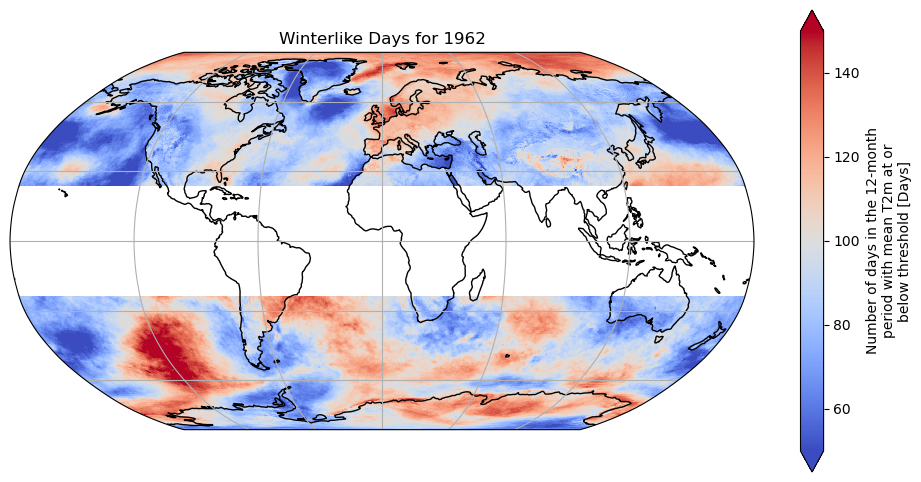

CPU times: user 7.26 s, sys: 144 ms, total: 7.4 s
Wall time: 7.42 s


In [7]:
%%time
input_year=1962

# Global summer length for the year
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

ds.WinterlikeDays.sel(time=str(input_year)).where((ds.lat <= -23.5) | (ds.lat >= 23.5)).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=50,
    vmax=150, # define range to include an entire year
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Winterlike Days for "+str(input_year))#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Pull in the coastal margins for use in data processing and write out full 1961-2025 Winter Stats for Fourier fit data

In [96]:
# write those results out for later use
input_path = '../../../../Data/ERA5-global/ERA5-2023-09-01-CoordFixed-CoastalMargins.nc'
results_ds = xr.open_dataset(input_path)



In [4]:
results_ds

<xarray.Dataset> Size: 1MB
Dimensions:  (lat: 721, lon: 1440)
Coordinates:
  * lat      (lat) float32 3kB 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * lon      (lon) float32 6kB -180.0 -179.8 -179.5 -179.2 ... 179.2 179.5 179.8
Data variables:
    Coastal  (lat, lon) bool 1MB ...

## * Build and write out the full data set from Fourier fits including the coastal margin boolean

In [97]:
%%time

# takes ~4 min to load

# start with one year and lsm then coastal and add a coordinate for the year
year = 1961
input_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/'+str(year)+'_winter_stats.nc'
ds_base = xr.open_dataset(input_path)
ds_base = ds_base.merge(ds_lsm) # add lsm
ds_base = ds_base.merge(results_ds) # add coastal flag
ds_base = ds_base.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))

# loop thru remaining years and also add time coord
input_years = np.arange(1962,2026,1)

for year in input_years:
    input_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/'+str(year)+'_winter_stats.nc'
    ds_i = xr.open_dataset(input_path)
    ds_i = ds_i.merge(ds_lsm)
    ds_i = ds_i.merge(results_ds)
    ds_i = ds_i.expand_dims("time").assign_coords(time=("time", [dt(year,1,1)]))
    ds_base = ds_base.merge(ds_i)

ds_base

CPU times: user 1min 34s, sys: 3min 11s, total: 4min 46s
Wall time: 5min 36s


<xarray.Dataset> Size: 5GB
Dimensions:         (lat: 721, lon: 1440, time: 65)
Coordinates:
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time            (time) datetime64[us] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterStart     (time, lat, lon) float64 540MB 88.0 88.0 ... 219.0 219.0
    WinterEnd       (time, lat, lon) float64 540MB 125.0 125.0 ... 219.0 219.0
    WinterTmax      (time, lat, lon) float64 540MB 94.0 94.0 94.0 ... 4.0 4.0
    WinterCold      (time, lat, lon) float64 540MB 70.38 70.38 70.38 ... 0.0 0.0
    WinterLength    (time, lat, lon) float64 540MB 38.0 38.0 38.0 ... 0.0 0.0
    WinterlikeDays  (time, lat, lon) float64 540MB 96.0 96.0 96.0 ... 9.0 9.0
    WinterRMSE      (time, lat, lon) float64 540MB 3.98 3.98 ... 3.641 3.641
    WinterMeanT     (time, lat, lon) float64 540MB 218.1 218.1 218.1 ... 0.0 0.0
    lsm             (time, lat, lon) float64 540MB 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal         (time, lat, lon) float64 540MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [98]:
# re-add attributes which get lost on merge apparently
ds_base.WinterStart.attrs["long_name"] = "Start day of winter for the year (DOY in [1,365])"
ds_base.WinterStart.attrs["units"] = "Day of year"

ds_base.WinterEnd.attrs["long_name"] = "Last day of winter for the year (DOY in [1,365])"
ds_base.WinterEnd.attrs["units"] = "Day of year"

ds_base.WinterLength.attrs["long_name"] = "Duration of winter for the year"
ds_base.WinterLength.attrs["units"] = "Days"

ds_base.WinterlikeDays.attrs["long_name"] = "Number of days in the 12-month period with mean T2m at or below threshold"
ds_base.WinterlikeDays.attrs["long_name"] = "Days"

ds_base.WinterTmax.attrs["long_name"] = "Day of max mean temp during winter for the year"
ds_base.WinterTmax.attrs["units"] = "Day of year"

ds_base.WinterCold.attrs["long_name"] = "Accumulated cold during winter for the year"
ds_base.WinterCold.attrs["units"] = "Degree-Days"

ds_base.WinterRMSE.attrs["long_name"] = "Root mean squared error of Fourier fit"
ds_base.WinterRMSE.attrs["units"] = "Degrees [K]"

ds_base.WinterMeanT.attrs["long_name"] = "Mean temperature during the winter period"
ds_base.WinterMeanT.attrs["units"] = "Degrees [K]"

ds_base.lsm.attrs["long_name"] = "Land-sea mask - a measure of the amount of land in the cell"
ds_base.lsm.attrs["units"] = "(0 - 1)"

###
### also cast the Coastal as boolean?
###
ds_base.Coastal.values = ds_base.Coastal.values.astype(bool)
ds_base.Coastal.attrs["long_name"] = "Boolean value for whether a >30% land cell has at least one >80% water neighbor"
ds_base.Coastal.attrs["units"] = "true/false"

ds_base

<xarray.Dataset> Size: 5GB
Dimensions:         (lat: 721, lon: 1440, time: 65)
Coordinates:
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * time            (time) datetime64[us] 520B 1961-01-01 ... 2025-01-01
Data variables:
    WinterStart     (time, lat, lon) float64 540MB 88.0 88.0 ... 219.0 219.0
    WinterEnd       (time, lat, lon) float64 540MB 125.0 125.0 ... 219.0 219.0
    WinterTmax      (time, lat, lon) float64 540MB 94.0 94.0 94.0 ... 4.0 4.0
    WinterCold      (time, lat, lon) float64 540MB 70.38 70.38 70.38 ... 0.0 0.0
    WinterLength    (time, lat, lon) float64 540MB 38.0 38.0 38.0 ... 0.0 0.0
    WinterlikeDays  (time, lat, lon) float64 540MB 96.0 96.0 96.0 ... 9.0 9.0
    WinterRMSE      (time, lat, lon) float64 540MB 3.98 3.98 ... 3.641 3.641
    WinterMeanT     (time, lat, lon) float64 540MB 218.1 218.1 218.1 ... 0.0 0.0
    lsm             (time, lat, lon) float64 540MB 1.0 1.0 1.0 ... 0.0 0.0 0.0
    Coastal         (time, lat, lon) bool 67MB False False False ... False False

In [99]:
# write out complete dataset with LSM and Coastal flags
output_path = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/1961-2025_ALL_winter_stats.nc'
ds_base.to_netcdf(output_path)



In [100]:
! ls -al "../../../../Data/ERA5-global/Analysis/New-Fourier/Winter"

total 18062184
drwxr-xr-x@ 70 tedscott  staff        2240 Sep 24 07:32 .
drwx------@ 93 tedscott  staff        2976 Sep 23 15:07 ..
-rw-r--r--@  1 tedscott  staff        6148 Jun 15 12:00 .DS_Store
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 14:26 1961_winter_stats.nc
-rw-------   1 tedscott  staff  4926484300 Sep 24 07:50 1961-2025_ALL_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 14:59 1962_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 15:32 1963_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 16:05 1964_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 16:39 1965_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 17:12 1966_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 17:44 1967_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 18:17 1968_winter_stats.nc
-rw-r--r--@  1 tedscott  staff    66478723 Sep 22 18:49 1969_winter_stats.nc
-rw-r--r--@  1 tedscott

# **********

# *** JUMP here after first running

In [2]:
ds = xr.open_dataset('../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/1961-2025_ALL_winter_stats.nc')
ds

<xarray.Dataset> Size: 5GB
Dimensions:         (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    WinterStart     (time, lat, lon) float64 540MB ...
    WinterEnd       (time, lat, lon) float64 540MB ...
    WinterTmax      (time, lat, lon) float64 540MB ...
    WinterCold      (time, lat, lon) float64 540MB ...
    WinterLength    (time, lat, lon) float64 540MB ...
    WinterlikeDays  (time, lat, lon) float64 540MB ...
    WinterRMSE      (time, lat, lon) float64 540MB ...
    WinterMeanT     (time, lat, lon) float64 540MB ...
    lsm             (time, lat, lon) float64 540MB ...
    Coastal         (time, lat, lon) bool 67MB ...

# **********

# Plots

In [3]:


# find weights (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights"


### Global Land vs Ocean Summer Length

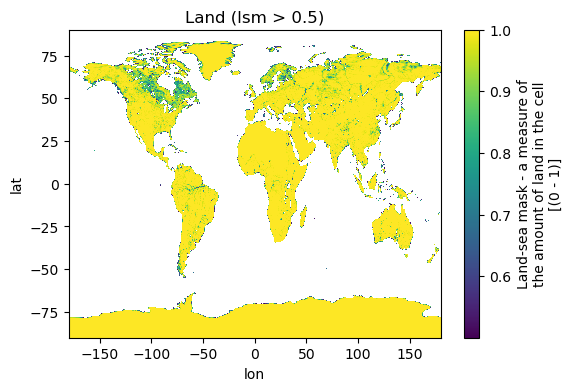

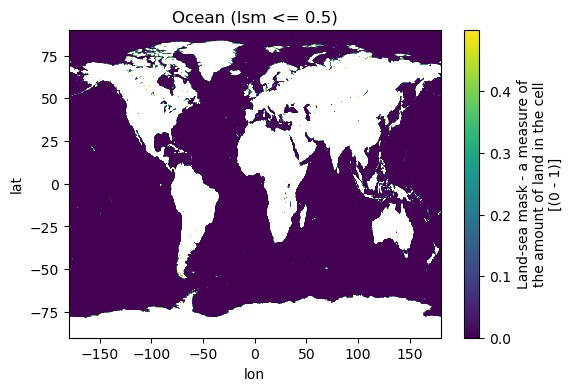

In [4]:
# can be land and Land small water
ds_land = ds.where(ds.lsm > 0.5)
ds_ocean = ds.where(ds.lsm <= 0.5)

plt.figure(figsize=(6,4))
#plt.subplot(111)
ds_land.lsm.sel(time='2020').plot()
plt.title("Land (lsm > 0.5)")
#plt.subplot(122)
plt.figure(figsize=(6,4))
ds_ocean.lsm.sel(time='2020').plot()
plt.title("Ocean (lsm <= 0.5)")
#plt.tight_layout()
plt.show()

In [5]:
ds_land

<xarray.Dataset> Size: 5GB
Dimensions:         (time: 65, lat: 721, lon: 1440)
Coordinates:
  * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
  * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    WinterStart     (time, lat, lon) float64 540MB 88.0 88.0 88.0 ... nan nan
    WinterEnd       (time, lat, lon) float64 540MB 125.0 125.0 125.0 ... nan nan
    WinterTmax      (time, lat, lon) float64 540MB 94.0 94.0 94.0 ... nan nan
    WinterCold      (time, lat, lon) float64 540MB 70.38 70.38 70.38 ... nan nan
    WinterLength    (time, lat, lon) float64 540MB 38.0 38.0 38.0 ... nan nan
    WinterlikeDays  (time, lat, lon) float64 540MB 96.0 96.0 96.0 ... nan nan
    WinterRMSE      (time, lat, lon) float64 540MB 3.98 3.98 3.98 ... nan nan
    WinterMeanT     (time, lat, lon) float64 540MB 218.1 218.1 218.1 ... nan nan
    lsm             (time, lat, lon) float64 540MB 1.0 1.0 1.0 ... nan nan nan
    Coastal         (time, lat, lon) float64 540MB 0.0 0.0 0.0 ... nan nan nan

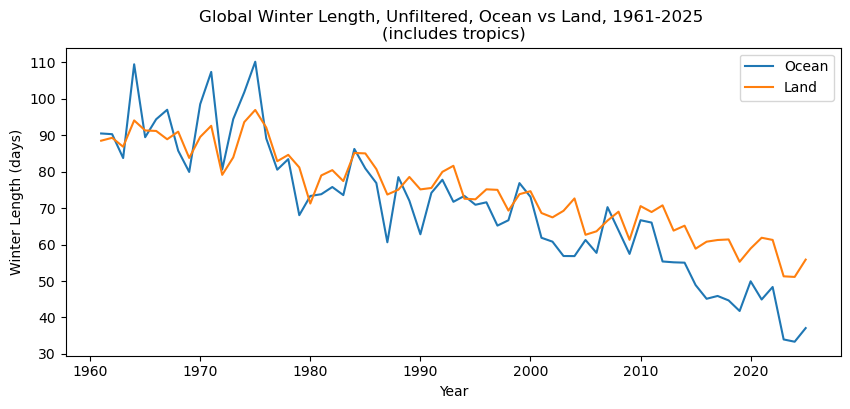

In [6]:


# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_land_sl = ds_land.WinterLength.weighted(weights).mean(dim=['lat','lon'])
wavg_ocean_sl = ds_ocean.WinterLength.weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_ocean_sl.time.dt.year, wavg_ocean_sl, label="Ocean")
plt.plot(wavg_land_sl.time.dt.year, wavg_land_sl, label="Land")

plt.xlabel("Year")
plt.ylabel("Winter Length (days)")
plt.title("Global Winter Length, Unfiltered, Ocean vs Land, 1961-2025 \n(includes tropics)")
plt.legend()
plt.show()

## Global Mid-latitude Land vs Ocean

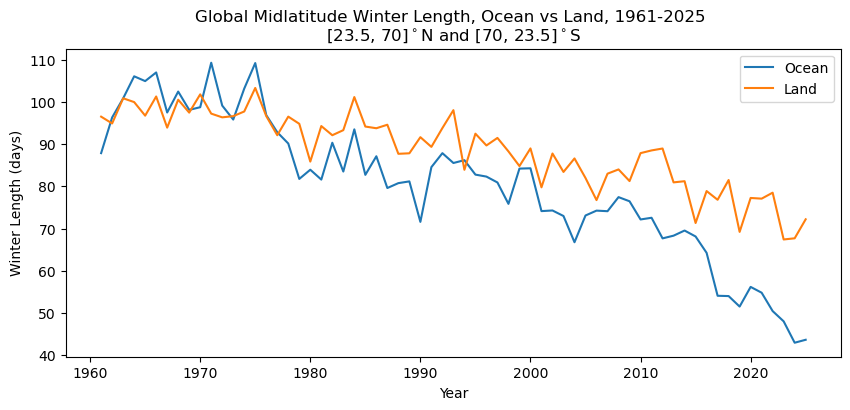

In [7]:
# take the weighted spatial mean since the latitude range of the region of interest is large
wavg_midlat_land_sl = ds_land.WinterLength.where(((ds_land.lat >= 23.5) & (ds_land.lat <= 70)) | 
                                         ((ds_land.lat <= -23.5) & (ds_land.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])
wavg_midlat_ocean_sl = ds_ocean.WinterLength.where(((ds_ocean.lat >= 23.5) & (ds_ocean.lat <= 70)) |
                                           ((ds_ocean.lat <= -23.5) & (ds_ocean.lat >= -70))).weighted(weights).mean(dim=['lat','lon'])

plt.figure(figsize=(10,4))
plt.plot(wavg_midlat_ocean_sl.time.dt.year, wavg_midlat_ocean_sl, label="Ocean")
plt.plot(wavg_midlat_land_sl.time.dt.year, wavg_midlat_land_sl, label="Land")
plt.xlabel("Year")
plt.ylabel("Winter Length (days)")
plt.title("Global Midlatitude Winter Length, Ocean vs Land, 1961-2025 \n[23.5, 70]$^\circ$N and [70, 23.5]$^\circ$S")
plt.legend()
plt.show()

In [8]:
plot_vars = list(ds.data_vars)
plot_vars

['WinterStart',
 'WinterEnd',
 'WinterTmax',
 'WinterCold',
 'WinterLength',
 'WinterlikeDays',
 'WinterRMSE',
 'WinterMeanT',
 'lsm',
 'Coastal']

## Scatter plots of Ocean (<= 50% land) vs Land (> 50% land) for NH and SH, Start/End/Length

In [9]:
plot_vars = list(ds.data_vars)
remove_me = {'WinterRMSE','lsm','Coastal'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['WinterStart',
 'WinterEnd',
 'WinterTmax',
 'WinterCold',
 'WinterLength',
 'WinterlikeDays',
 'WinterMeanT']

In [10]:
%%time

# takes 36 sec

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

# datasets of weighted averages for the midlatitudes
nh_land_full = ds.where((ds.lsm > 0.5) & 
                             ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_full = ds.where((ds.lsm <= 0.5) & 
                              ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_full = ds.where((ds.lsm > 0.5) &  
                             ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_full = ds.where((ds.lsm <= 0.5) &  
                              ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_land_an = ds.sel(time=slice('1990','2025')).where((ds.lsm > 0.5) & 
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_an = ds.sel(time=slice('1990','2025')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an = ds.sel(time=slice('1990','2025')).where((ds.lsm > 0.5) & 
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_an = ds.sel(time=slice('1990','2025')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

# adding in baseline period for trends to put in paper
nh_land_base = ds.sel(time=slice('1961','1990')).where((ds.lsm > 0.5) & 
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_base = ds.sel(time=slice('1961','1990')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_base = ds.sel(time=slice('1961','1990')).where((ds.lsm > 0.5) & 
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_base = ds.sel(time=slice('1961','1990')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 17.2 s, sys: 16.3 s, total: 33.5 s
Wall time: 35.9 s


In [11]:
# plot properties so I can more easily tweak them
s = 18
lw = 4
alpha = 0.6
fs = 20

sns.set_theme(style="darkgrid")

### First with no trends

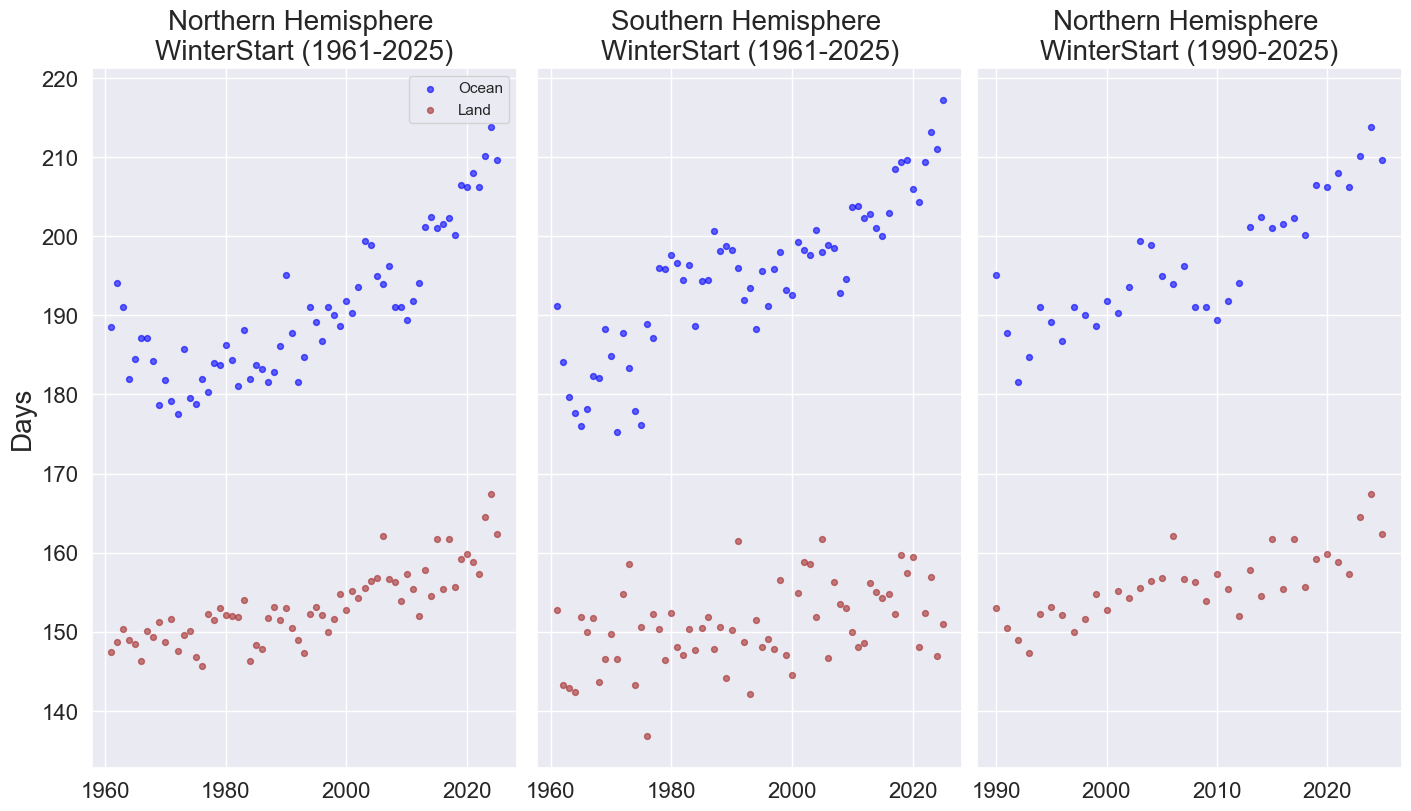

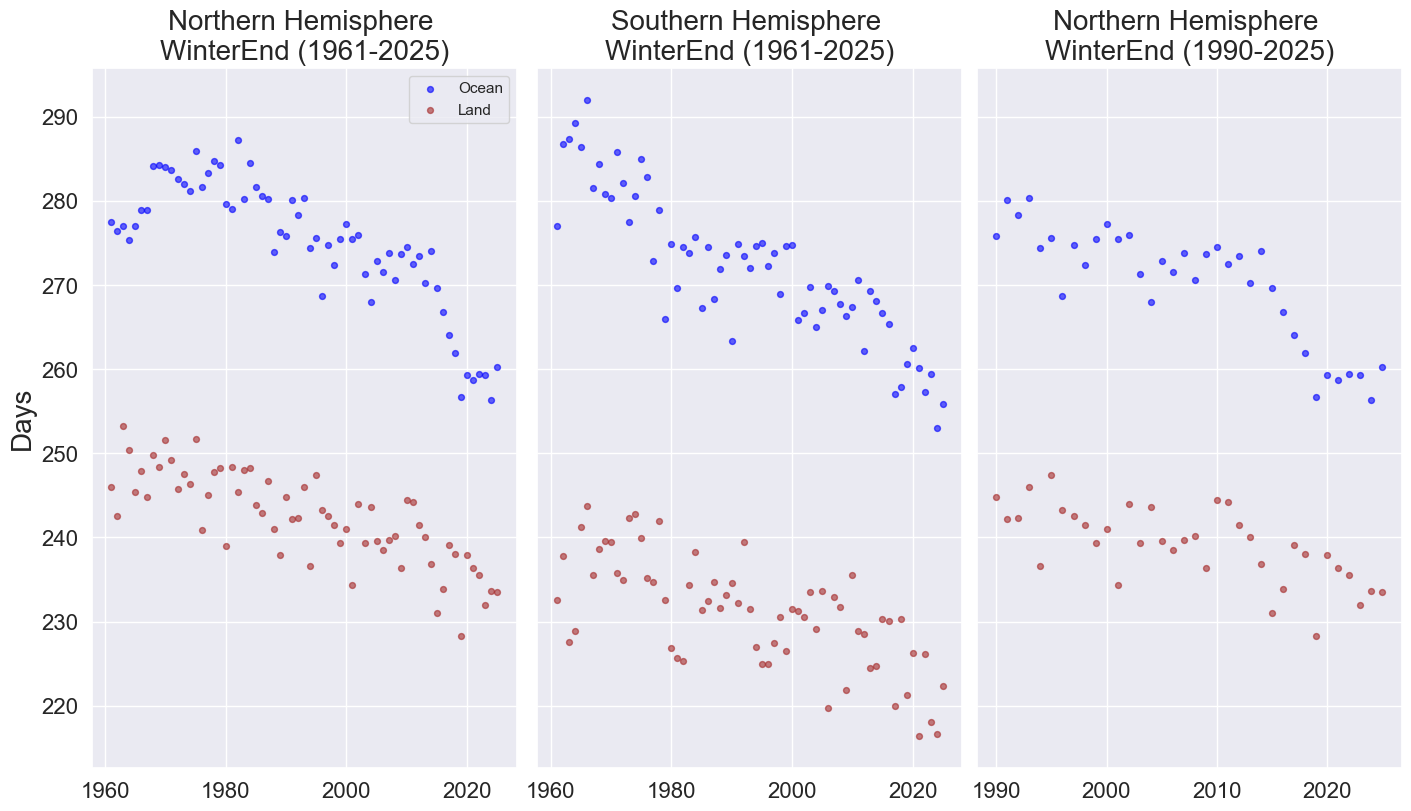

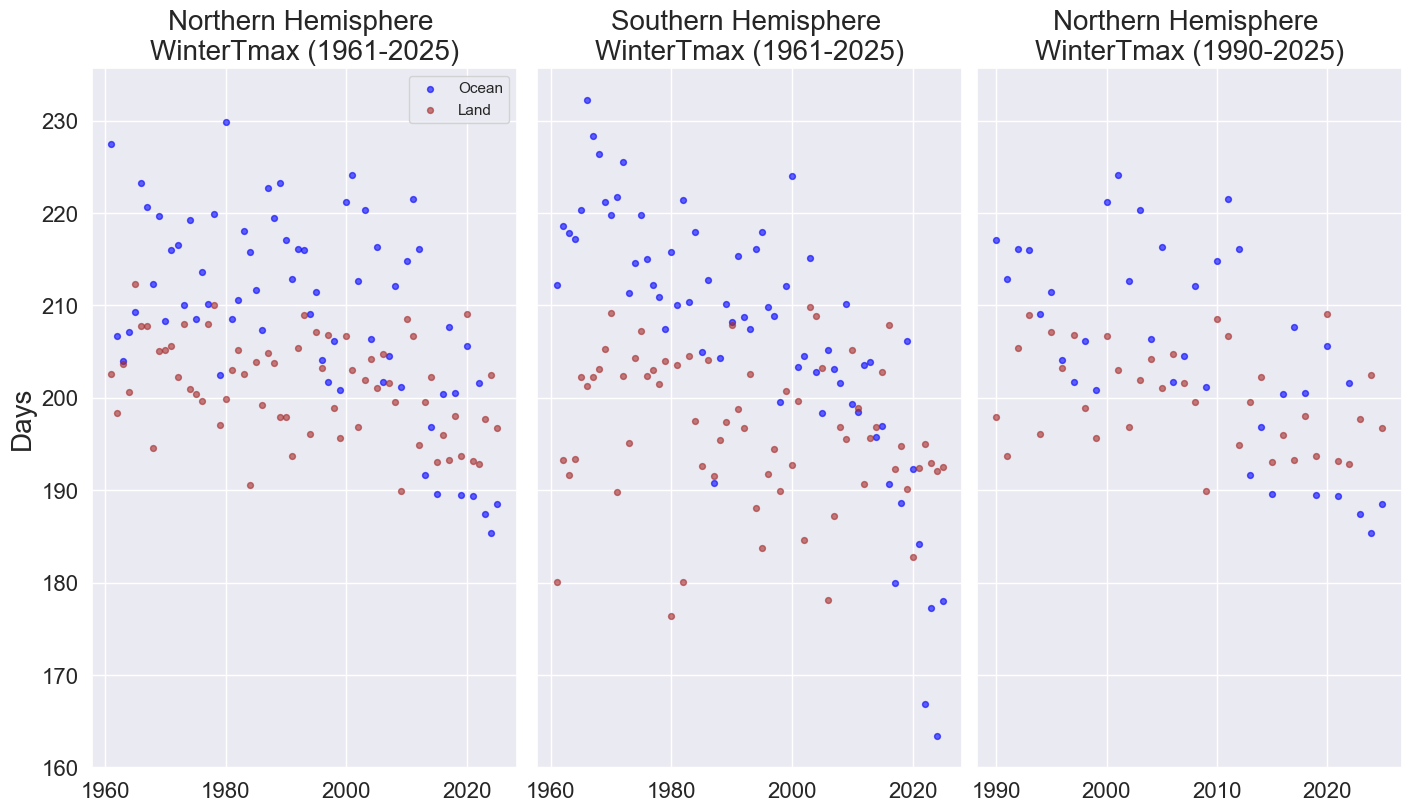

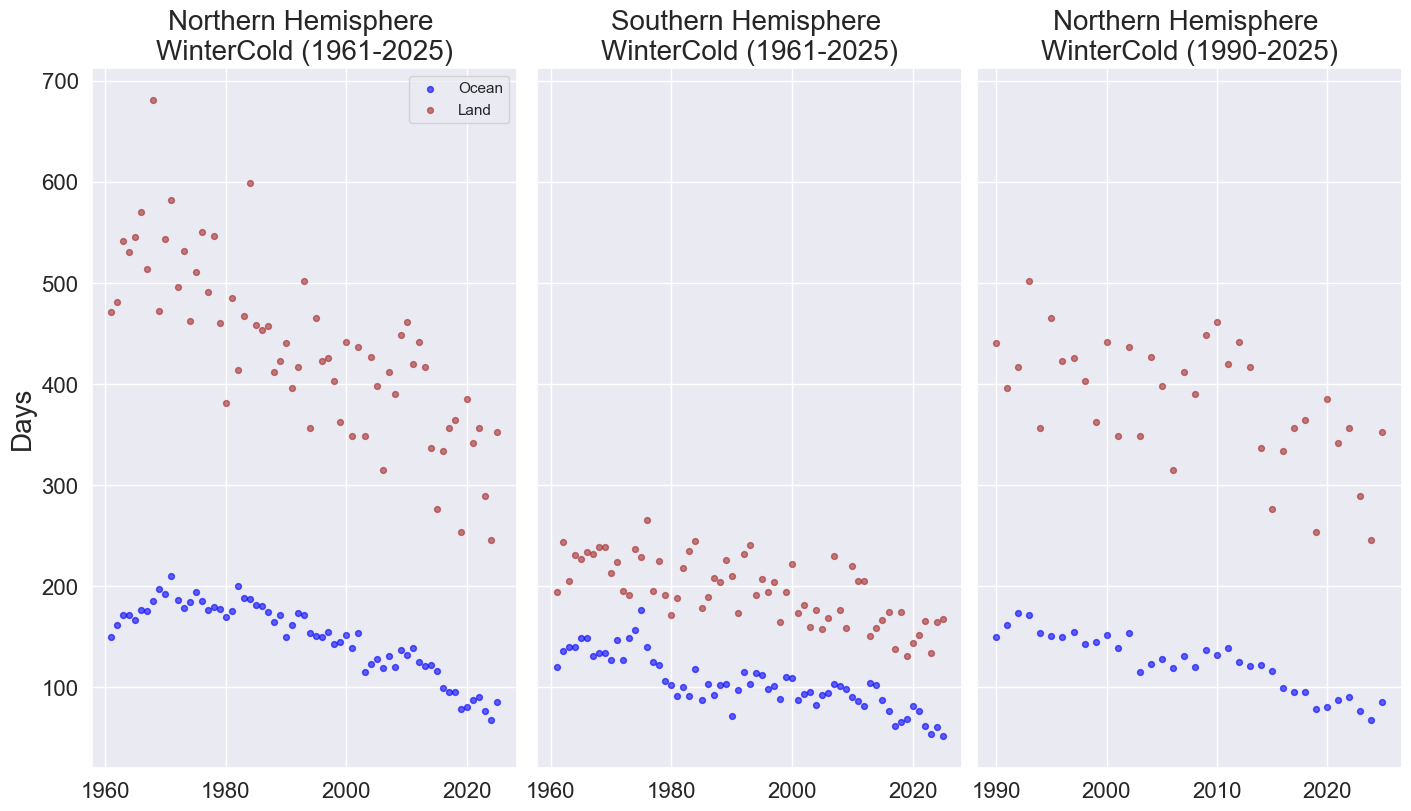

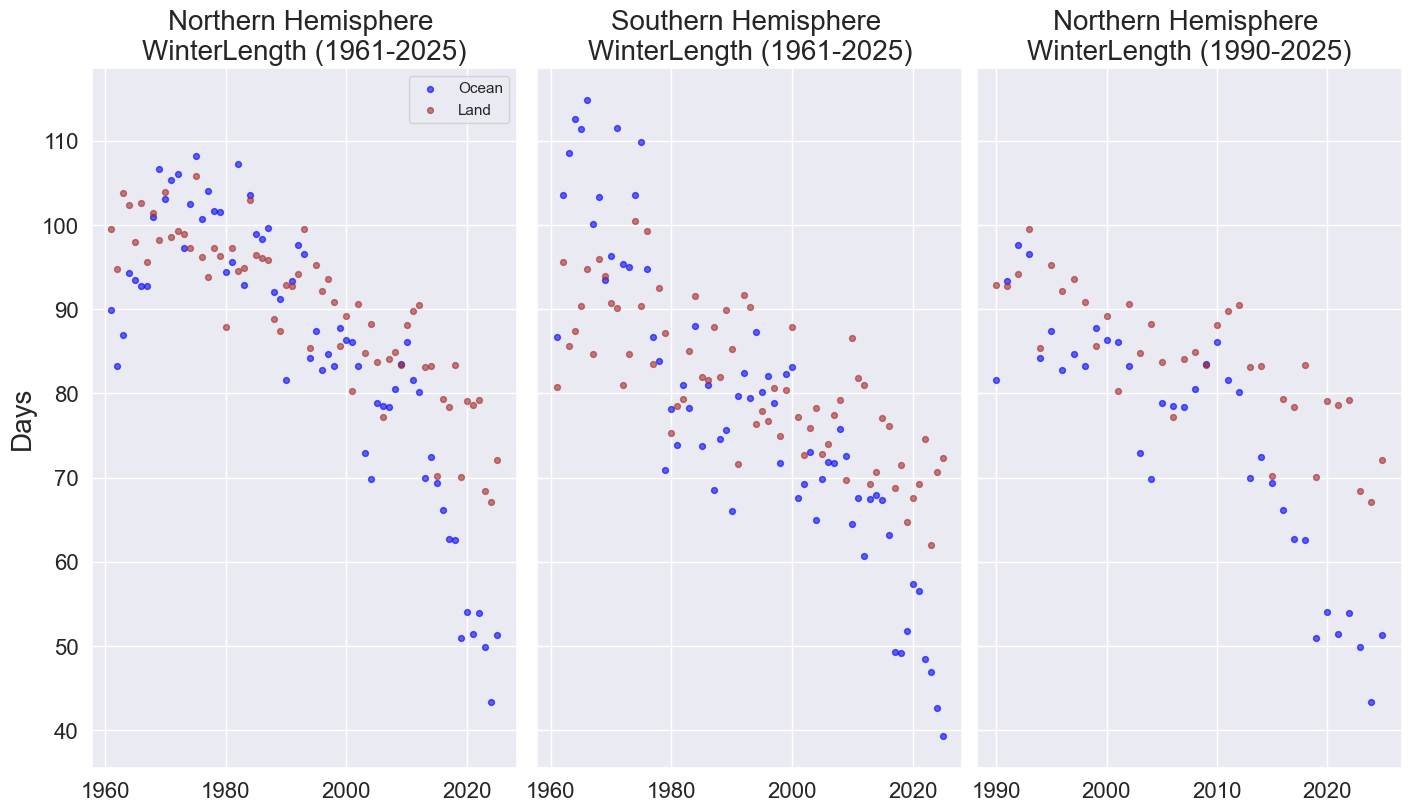

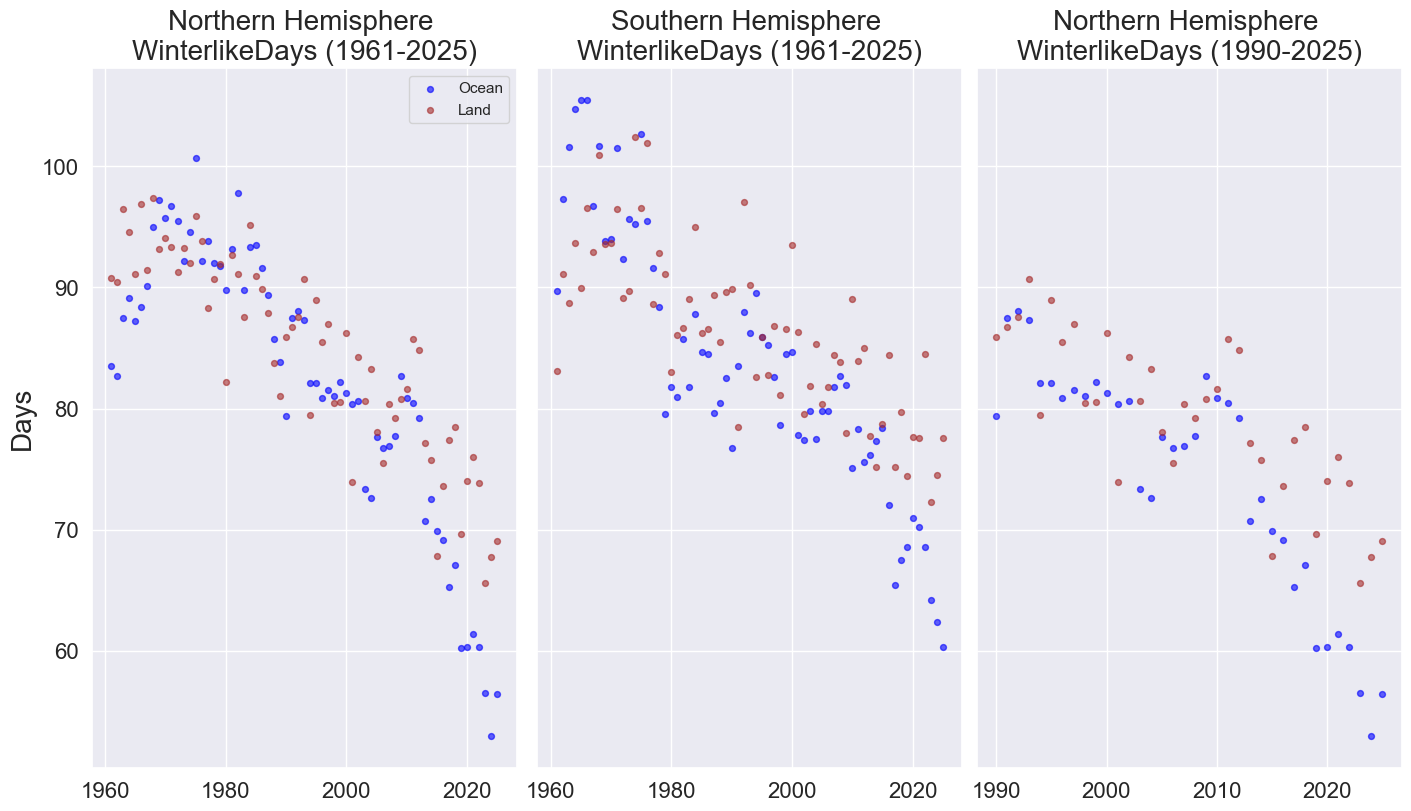

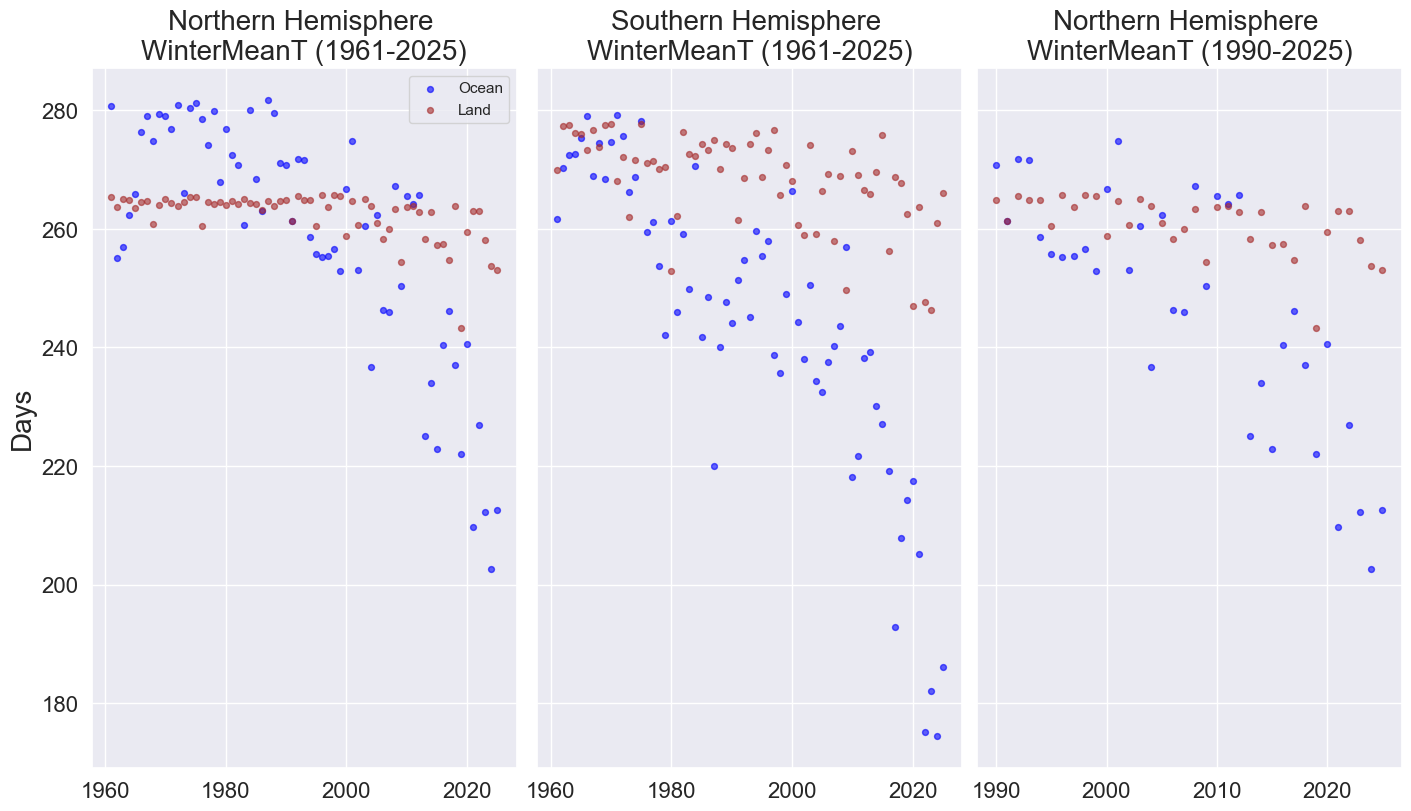

CPU times: user 1.02 s, sys: 83.7 ms, total: 1.1 s
Wall time: 1.23 s


In [12]:
%%time


# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (14,8), layout='constrained')
    
    # Full Time Period NH
    ax1 = fig.add_subplot(1,3,1)

    # linear fits for slope from 1960-1976
    x_land = nh_land_full.time.dt.year.values[0:17]
    y_land = nh_land_full[v].values[0:17]
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values[0:17]
    y_ocean = nh_ocean_full[v].values[0:17]
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax1.scatter(nh_ocean_full.time.dt.year.values, nh_ocean_full[v], label="Ocean", c="blue", s=s, alpha=alpha)
    # ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
    #      label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax1.scatter(nh_land_full.time.dt.year.values, nh_land_full[v], label="Land", c="brown", s=s, alpha=alpha)
    # ax1.plot(x_land, poly_land(x_land), linewidth=lw, linestyle="dotted", color='brown',
    #      label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax1.set_title("Northern Hemisphere \n" + v + " (1961-2025)", fontsize = fs)

    # Annotation
    ann_y = (ax1.get_yticks())[-3]+8
    ann_x = np.mean(ax1.get_xticks())-5
    # ax1.text(ann_x, ann_y, 
    #          ''+str(np.round((slope_ocean+slope_land)*5,1))+r' $\frac{days}{decade}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    ax1.set_ylabel('Days', fontsize=fs)
    ax1.legend(loc='best')

    # Full time period SH
    ax2 = fig.add_subplot(1,3,2, sharey=ax1)

    # linear fits for slope
    x_land = sh_land_full.time.dt.year.values
    y_land = sh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_full.time.dt.year.values
    y_ocean = sh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax2.scatter(sh_ocean_full.time.dt.year.values, sh_ocean_full[v], label="SH Ocean", c="blue", s=s, alpha=alpha)
    # ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
    #      label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax2.scatter(sh_land_full.time.dt.year.values, sh_land_full[v], label="SH Land", c="brown", s=s, alpha=alpha)
    # ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         # label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax2.set_title("Southern Hemisphere \n" + v + " (1961-2025)", fontsize = fs)
    # Annotation
    # ann_y = (ax2.get_yticks())[-3]+8
    # ann_x = np.mean(ax2.get_xticks())-5
    # ax2.text(ann_x, ann_y, 
    #          ''+str(np.round((slope_ocean+slope_land)*5,1))+r' $\frac{days}{decade}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax2.legend(loc='best')
    

    # Analysis time period NH
    ax3 = fig.add_subplot(1,3,3, sharey=ax1)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(nh_ocean_an.time.dt.year.values, nh_ocean_an[v], label="NH Ocean", c="blue", s=s, alpha=alpha)
    #ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         #label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax3.scatter(nh_land_an.time.dt.year.values, nh_land_an[v], label="NH Land", c="brown", s=s, alpha=alpha)
    #ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         #label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax3.set_title("Northern Hemisphere \n" + v + " (1990-2025)", fontsize = fs)
    # Annotation - units in per decade
    ann_y = (ax3.get_yticks())[-3]+8
    ann_x = np.mean(ax3.get_xticks())-5
    # ax3.text(ann_x, ann_y, 
    #          ''+str(np.round((slope_ocean+slope_land)*5,1))+r' $\frac{days}{decade}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax3.legend(loc='best')


#plt.tight_layout()
plt.show()

## Now with trends


#### Note, slopes are the average slope across both surfaces by adding in quadrature and dividing by 2, then taking SQRT

In [13]:

# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70
sh_min = -23.5
sh_max = -70

#### Note: no filtering on winter length or temperature

In [14]:
plot_vars = list(ds.data_vars)
remove_me = {'WinterTmax','WinterMeanT','WinterRMSE','lsm','Coastal'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['WinterStart', 'WinterEnd', 'WinterCold', 'WinterLength', 'WinterlikeDays']

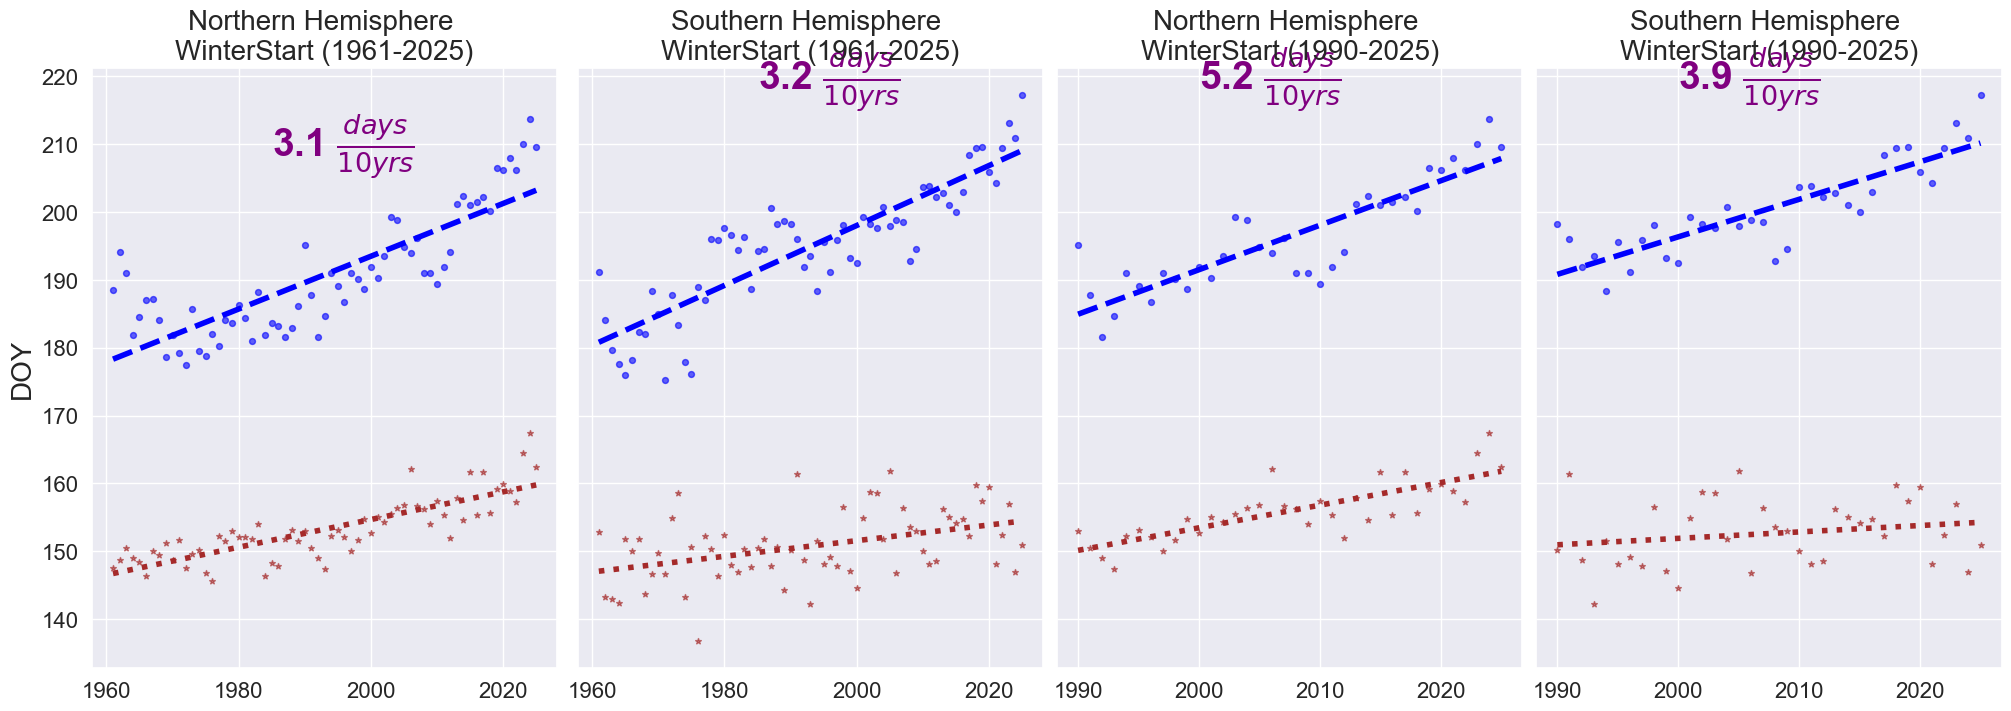

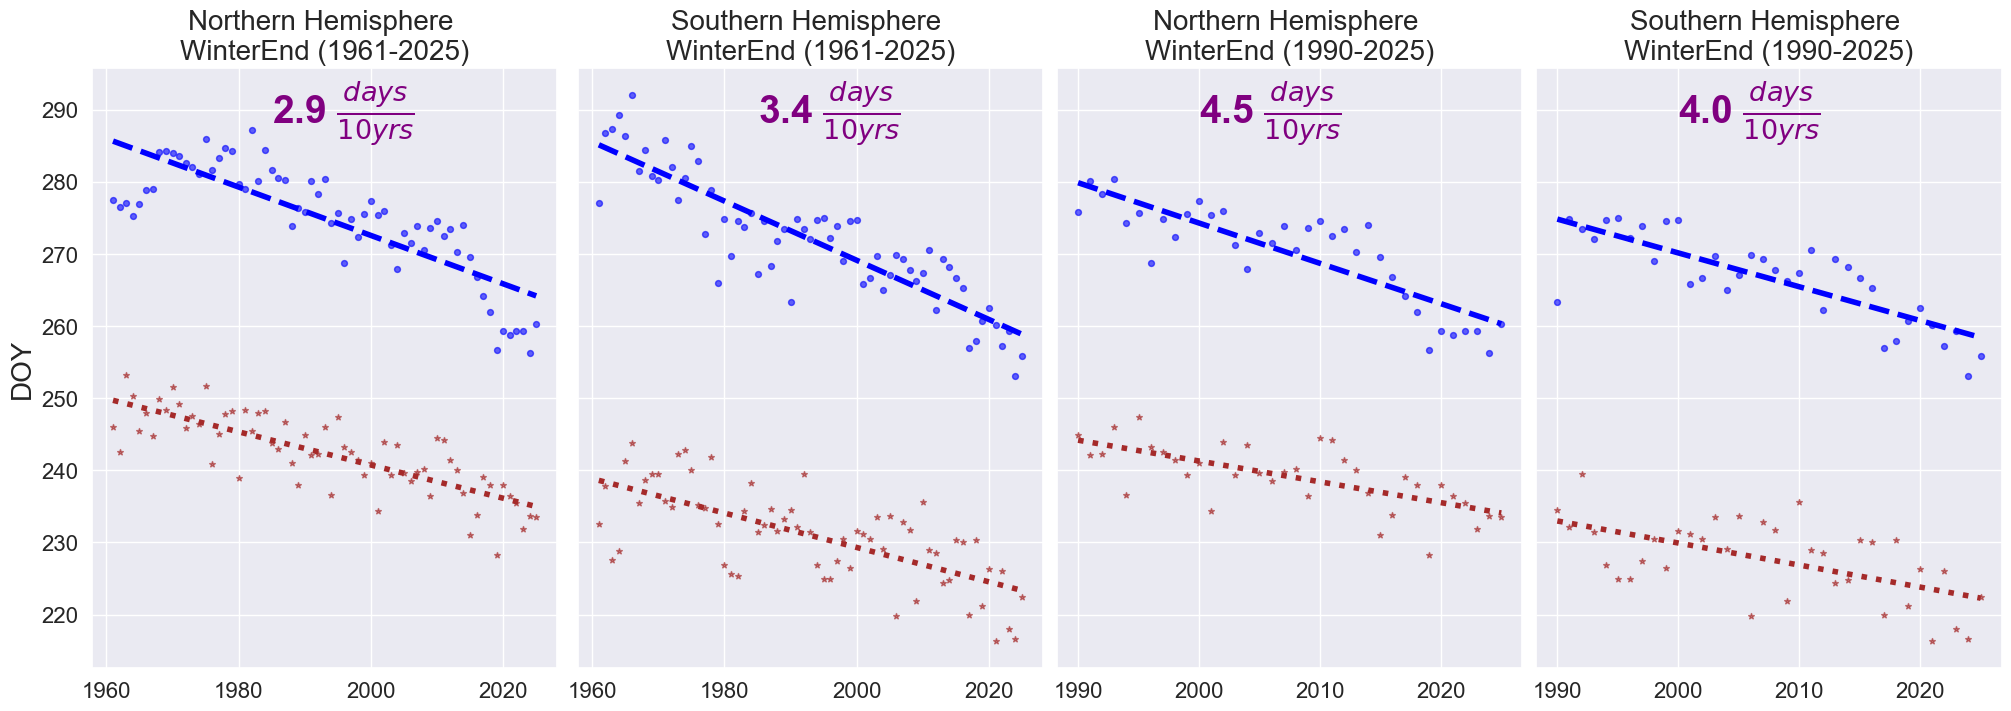

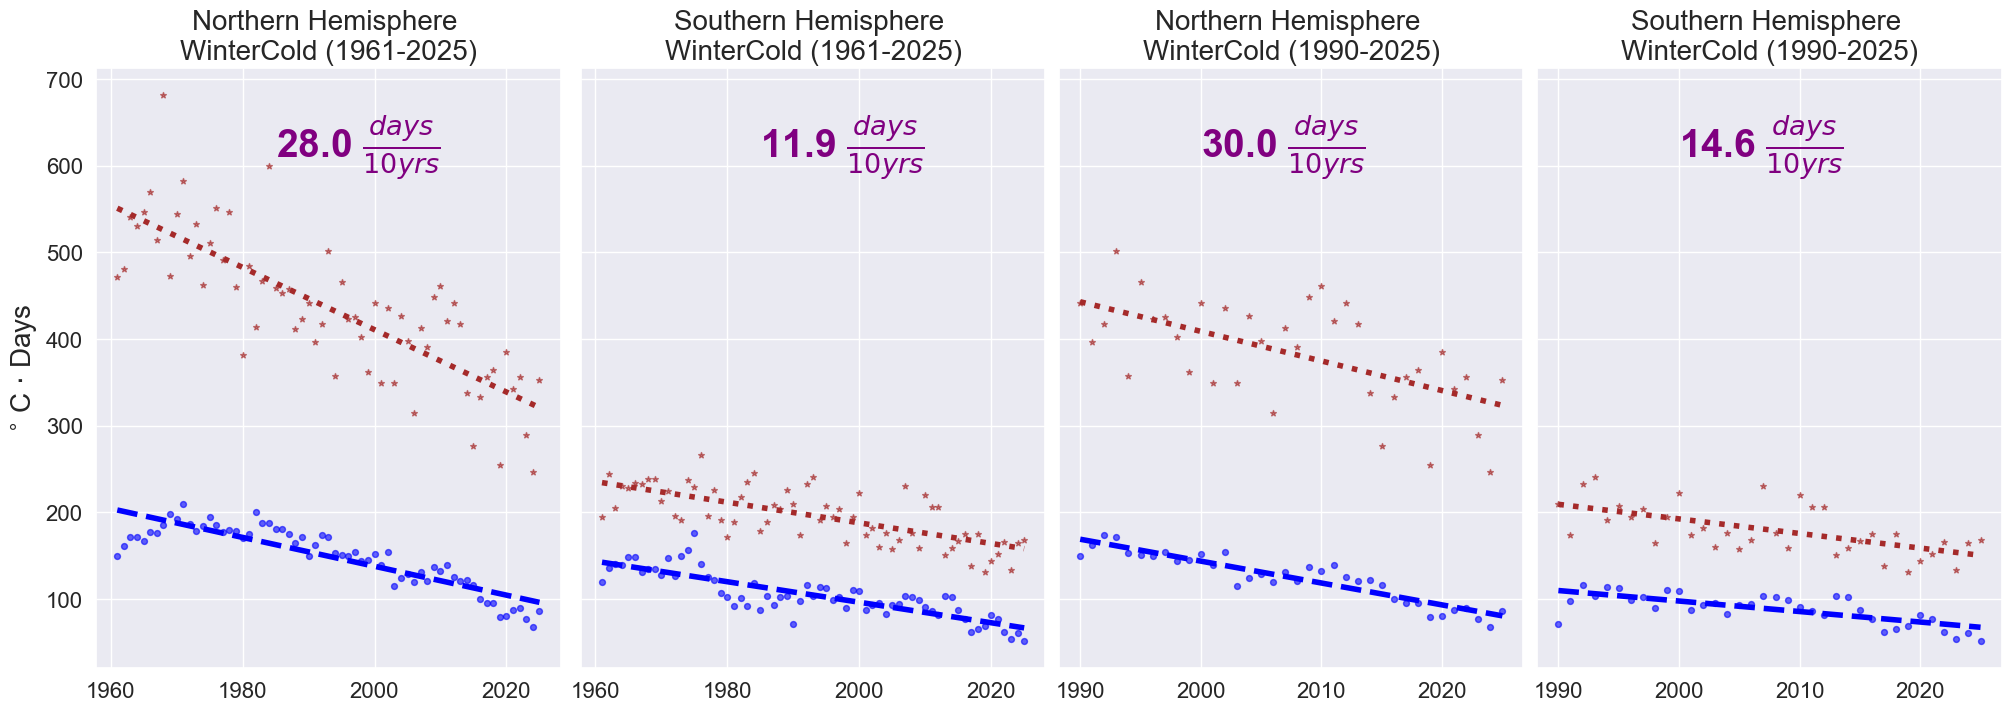

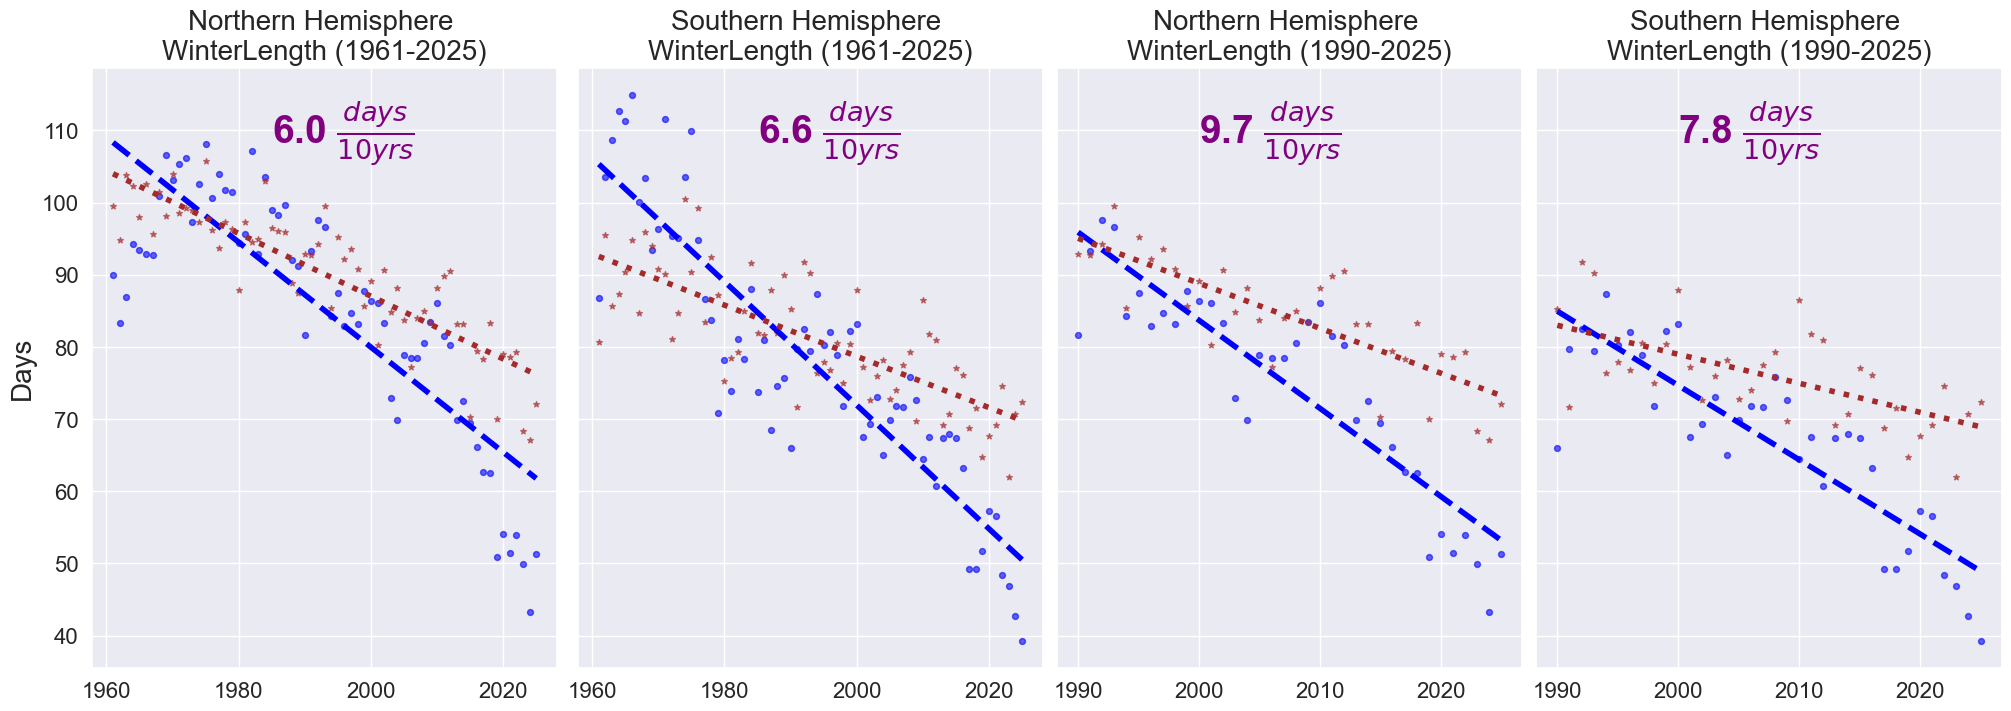

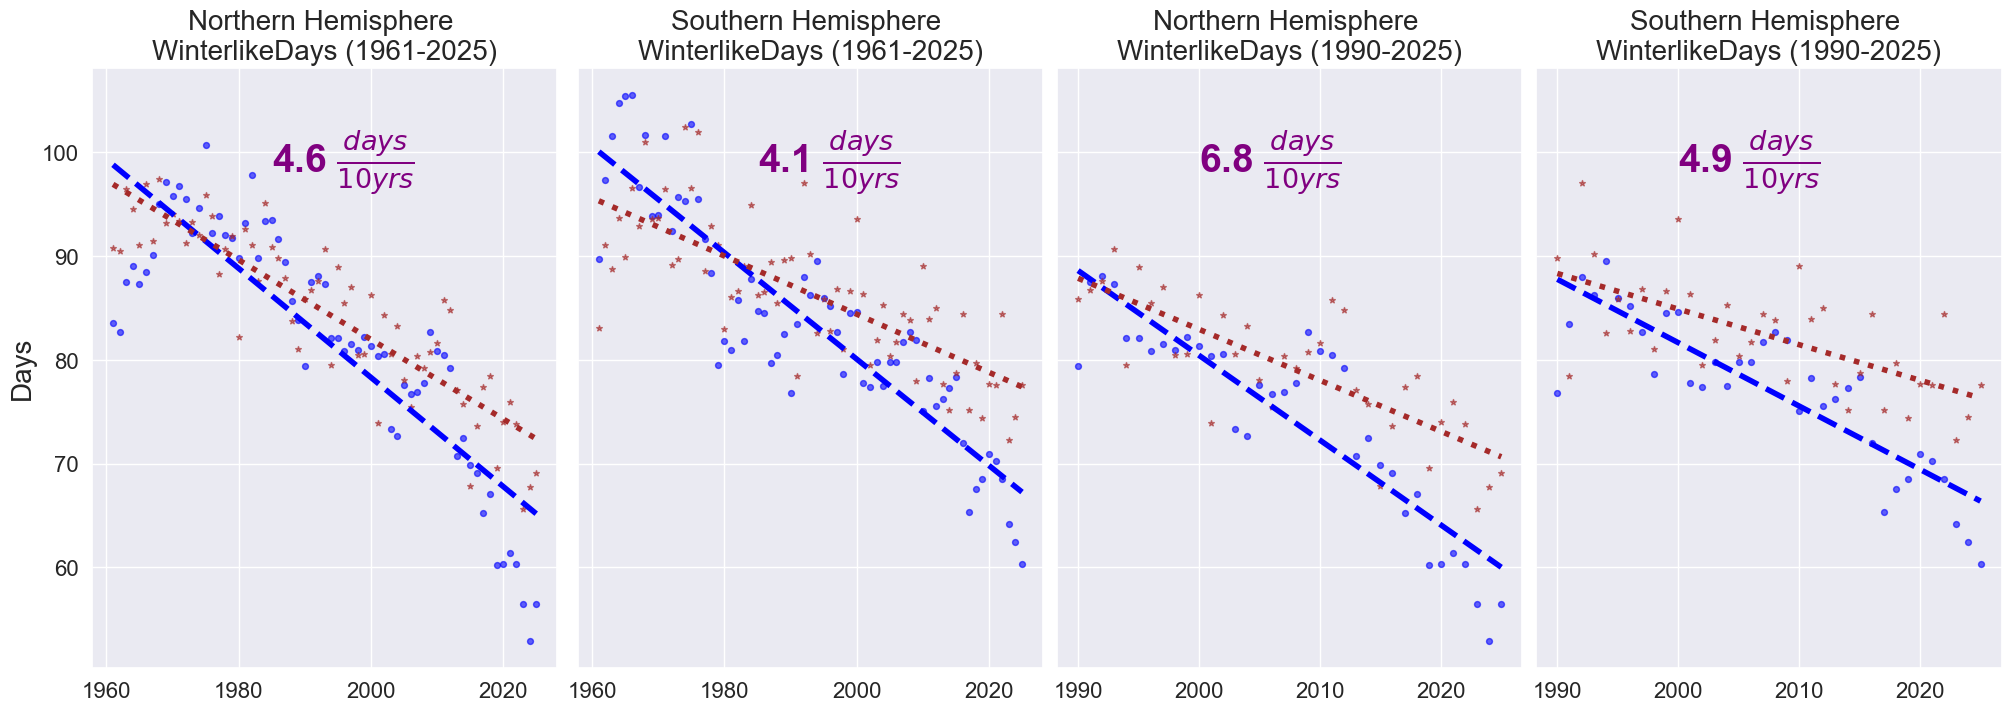

CPU times: user 1.04 s, sys: 176 ms, total: 1.22 s
Wall time: 1.31 s


In [16]:
%%time

# takes 30 sec



# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (20,7), layout='constrained')
    
    # Full Time Period NH
    ax1 = fig.add_subplot(1,4,1)

    # linear fits for slope
    x_land = nh_land_full.time.dt.year.values
    y_land = nh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values
    y_ocean = nh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
    ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax1.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax1.set_title("Northern Hemisphere \n" + v + " (1961-2025)", fontsize = fs)
    # Annotation
    ann_y = (ax1.get_yticks())[-3]+8
    ann_x = np.mean(ax1.get_xticks())-5
    # plot shows mean slope across all surface types for clarity
    mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    ax1.text(ann_x, ann_y, 
             ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    if i < 2:
        ylabel = 'DOY'
    elif i == 2:
        ylabel = '$^{\circ}$ C $\cdot$ Days'
    else:
        ylabel = 'Days'
    ax1.set_ylabel(ylabel, fontsize=fs)
    #ax1.legend(loc='best')

    # Full time period SH
    ax2 = fig.add_subplot(1,4,2, sharey=ax1)

    # linear fits for slope
    x_land = sh_land_full.time.dt.year.values
    y_land = sh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_full.time.dt.year.values
    y_ocean = sh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
    ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax2.scatter(x_land, y_land, label="SH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax2.set_title("Southern Hemisphere \n" + v + " (1961-2025)", fontsize = fs)
    # Annotation
    ann_y = (ax2.get_yticks())[-3]+8
    ann_x = np.mean(ax2.get_xticks())-5
    # plot shows mean slope across all surface types for clarity
    mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    ax2.text(ann_x, ann_y, 
             ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')

    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax2.legend(loc='best')
    

    # Analysis time period NH
    ax3 = fig.add_subplot(1,4,3, sharey=ax1)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
    ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax3.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax3.set_title("Northern Hemisphere \n" + v + " (1990-2025)", fontsize = fs)
    # Annotation - units in per decade
    ann_y = (ax3.get_yticks())[-3]+8
    ann_x = np.mean(ax3.get_xticks())-5
    # plot shows mean slope across all surface types for clarity
    mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    ax3.text(ann_x, ann_y, 
             ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax3.legend(loc='best')

    
    # Analysis time period SH
    ax4 = fig.add_subplot(1,4,4, sharey=ax1)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
    ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax4.scatter(x_land, y_land, label="SH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
    ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax4.set_title("Southern Hemisphere \n" + v + " (1990-2025)", fontsize = fs)
    # Annotation - units in per decade
    ann_y = (ax4.get_yticks())[-3]+8
    ann_x = np.mean(ax4.get_xticks())-5
        # plot shows mean slope across all surface types for clarity
    mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    ax4.text(ann_x, ann_y, 
             ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax3.legend(loc='best')


#plt.tight_layout()
plt.show()

#### Reformatted length only

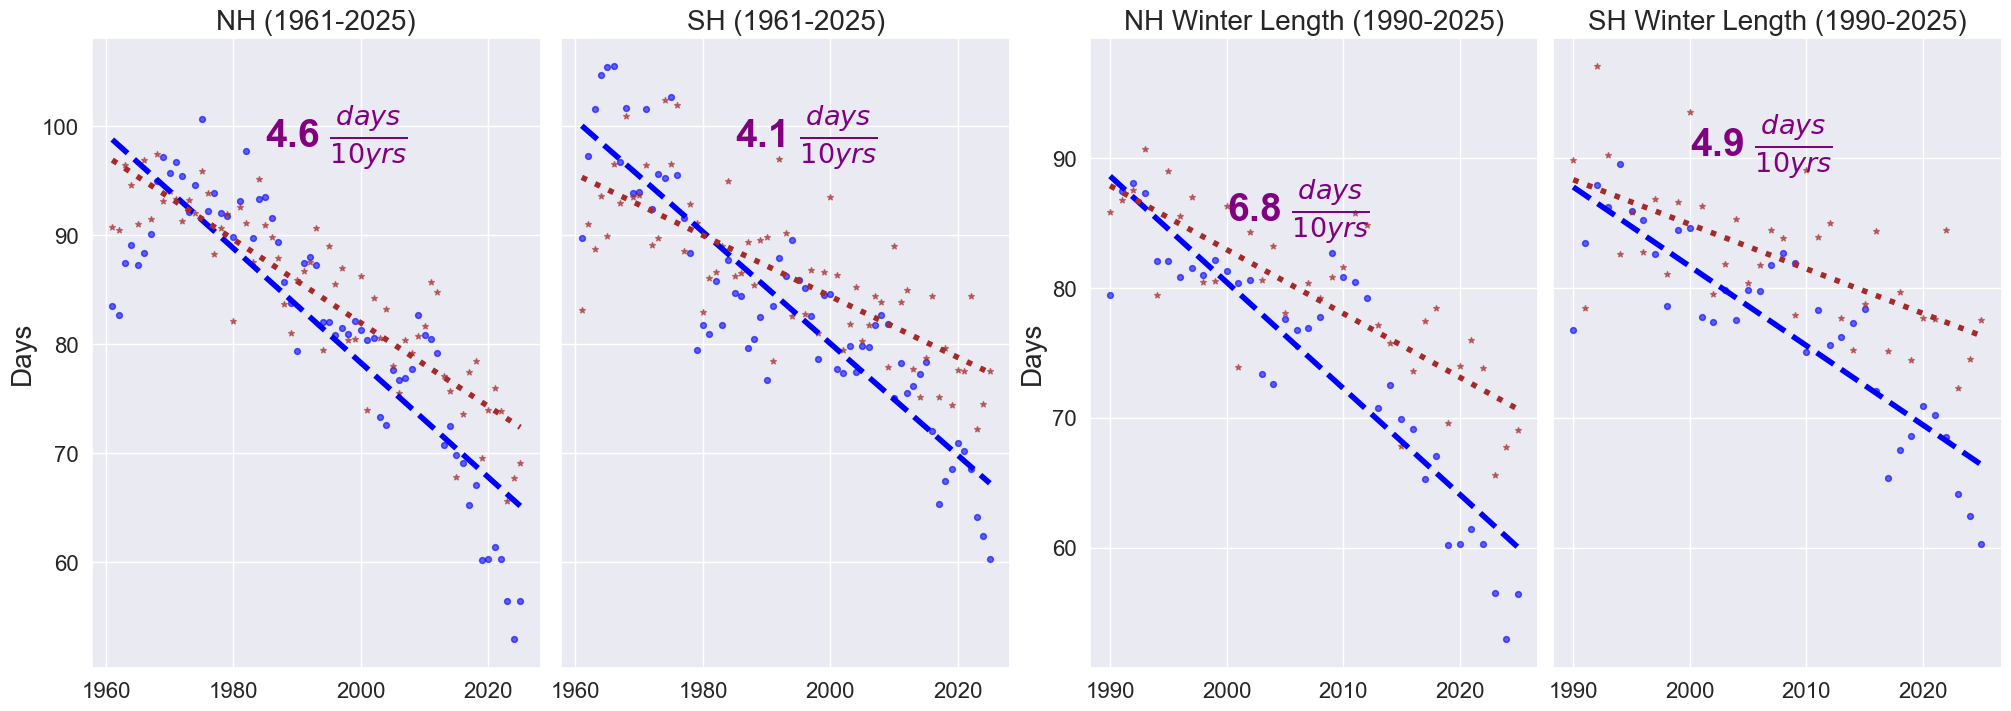

CPU times: user 210 ms, sys: 60.6 ms, total: 271 ms
Wall time: 348 ms


In [18]:
%%time

# takes 30 sec


# create blank fig
fig = plt.figure(figsize = (20,7), layout='constrained')

# Full Time Period NH
ax1 = fig.add_subplot(1,4,1)

# linear fits for slope
x_land = nh_land_full.time.dt.year.values
y_land = nh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


# linear fits for slope
x_ocean = nh_ocean_full.time.dt.year.values
y_ocean = nh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax1.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax1.set_title("NH (1961-2025)", fontsize = fs)
# Annotation
ann_y = (ax1.get_yticks())[-3]+8
ann_x = np.mean(ax1.get_xticks())-5
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax1.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
         #''+str(np.round((slope_ocean+slope_land)*5,1))+r' $\frac{days}{decade}$', fontsize=28, color='purple', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)
if i < 2:
    ylabel = 'DOY'
elif i == 2:
    ylabel = '$^{\circ}$ C $\cdot$ Days'
else:
    ylabel = 'Days'
ax1.set_ylabel(ylabel, fontsize=fs)
#ax1.legend(loc='best')

# Full time period SH
ax2 = fig.add_subplot(1,4,2, sharey=ax1)

# linear fits for slope
x_land = sh_land_full.time.dt.year.values
y_land = sh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


# linear fits for slope
x_ocean = sh_ocean_full.time.dt.year.values
y_ocean = sh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax2.scatter(x_land, y_land, label="SH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax2.set_title("SH (1961-2025)", fontsize = fs)
# Annotation
ann_y = (ax2.get_yticks())[-3]+8
ann_x = np.mean(ax2.get_xticks())-5
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax2.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax2.legend(loc='best')


# Analysis time period NH
ax3 = fig.add_subplot(1,4,3)#, sharey=ax1)

# linear fits for slope
x_land = nh_land_an.time.dt.year.values
y_land = nh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_an.time.dt.year.values
y_ocean = nh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax3.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax3.set_title("NH Winter Length (1990-2025)", fontsize = fs)
# Annotation - units in per decade
ann_y = (ax3.get_yticks())[-3]
ann_x = np.mean(ax3.get_xticks())-5
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax3.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
ax3.set_ylabel('Days', fontsize=fs)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=True)
#ax3.legend(loc='best')


# Analysis time period SH
ax4 = fig.add_subplot(1,4,4, sharey=ax3)

# linear fits for slope
x_land = sh_land_an.time.dt.year.values
y_land = sh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


# linear fits for slope
x_ocean = sh_ocean_an.time.dt.year.values
y_ocean = sh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax4.scatter(x_land, y_land, label="SH Land", marker='*', facecolors='brown', edgecolors='brown', s=s, alpha=alpha)
ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax4.set_title("SH Winter Length (1990-2025)", fontsize = fs)
# Annotation - units in per decade
ann_y = (ax4.get_yticks())[-3]+10
ann_x = np.mean(ax4.get_xticks())-5
    # plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax4.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax3.legend(loc='best')


#plt.tight_layout()
plt.show()

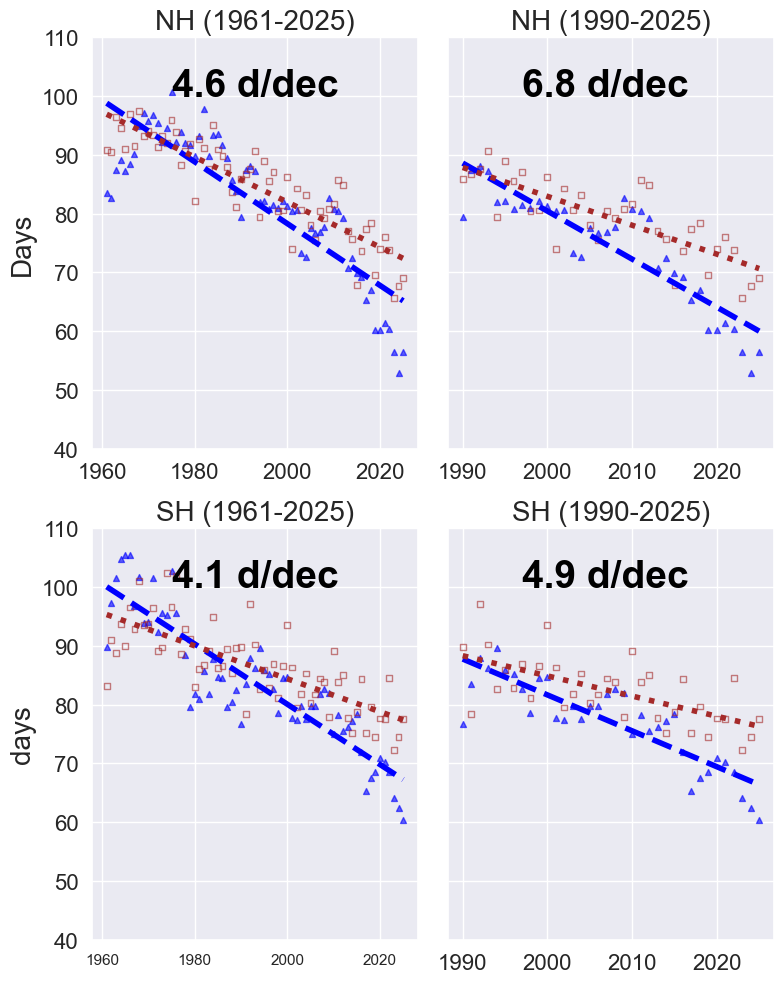

CPU times: user 176 ms, sys: 58.5 ms, total: 234 ms
Wall time: 325 ms


In [19]:
%%time

# takes 30 sec
#markers
l_m = 's'
o_m = '^'
c_m = 'o'


# create blank fig
fig = plt.figure(figsize = (8,10), layout='constrained')

# Full Time Period NH
ax1 = fig.add_subplot(2,2,1)

# linear fits for slope
x_land = nh_land_full.time.dt.year.values
y_land = nh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


# linear fits for slope
x_ocean = nh_ocean_full.time.dt.year.values
y_ocean = nh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax1.scatter(x_land, y_land, label="NH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax1.set_title("NH (1961-2025)", fontsize = fs)
# Annotation
ann_y = (ax1.get_yticks())[-3]+10
ann_x = np.mean(ax1.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax1.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)
if i < 2:
    ylabel = 'DOY'
elif i == 2:
    ylabel = '$^{\circ}$ C $\cdot$ Days'
else:
    ylabel = 'Days'
ax1.set_ylabel(ylabel, fontsize=fs)
ax1.set_ylim(40,110)
#ax1.legend(loc='best')

# Full time period SH
ax2 = fig.add_subplot(2,2,3)#, sharey=ax1)

# linear fits for slope
x_land = sh_land_full.time.dt.year.values
y_land = sh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_full.time.dt.year.values
y_ocean = sh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax2.scatter(x_land, y_land, label="SH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax2.set_title("SH (1961-2025)", fontsize = fs)
ax2.set_ylabel('days', fontsize=fs)
# Annotation
ann_y = (ax2.get_yticks())[-3]+10
ann_x = np.mean(ax2.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax2.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')

plt.tick_params('y', labelsize=16, labelleft=True)
ax2.set_ylim(40,110)
#ax2.legend(loc='best')


# Analysis time period NH
ax3 = fig.add_subplot(2,2,2, sharey=ax1)

# linear fits for slope
x_land = nh_land_an.time.dt.year.values
y_land = nh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_an.time.dt.year.values
y_ocean = nh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax3.scatter(x_land, y_land, label="NH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax3.set_title("NH (1990-2025)", fontsize = fs)
# Annotation - units in per decade
ann_y = (ax3.get_yticks())[-3]+10
ann_x = np.mean(ax3.get_xticks())-8
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax3.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)
#ax3.legend(loc='best')


# Analysis time period SH
ax4 = fig.add_subplot(2,2,4, sharey=ax2)

# linear fits for slope
x_land = sh_land_an.time.dt.year.values
y_land = sh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


# linear fits for slope
x_ocean = sh_ocean_an.time.dt.year.values
y_ocean = sh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax4.scatter(x_land, y_land, label="SH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax4.set_title("SH (1990-2025)", fontsize = fs)
# Annotation - units in per decade
ann_y = (ax4.get_yticks())[-3]+10
ann_x = np.mean(ax4.get_xticks())-8
    # plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1
ax4.text(ann_x, ann_y, 
         ''+str(np.round(mean_slope,1))+r' d/dec', fontsize=28, color='black', fontweight='bold')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax3.legend(loc='best')


plt.tight_layout()
#plt.savefig("./Plots/summer_length_2x2_plot.png",bbox_inches='tight')
#plt.savefig("./Plots/summer_length_2x2_plot.pdf",bbox_inches='tight')
plt.show()


## ** NOTE the slopes on Winter Length in the above plots are averaged (in quadrature?) and not the same as when fitting all the data points as a group, which is what is done below in the categorical scatter plots, so in the paper, I am using the slopes from the categorical scatter plots. **

#### Reformatted Accumulated Cold Only

In [24]:
v = 'WinterCold'

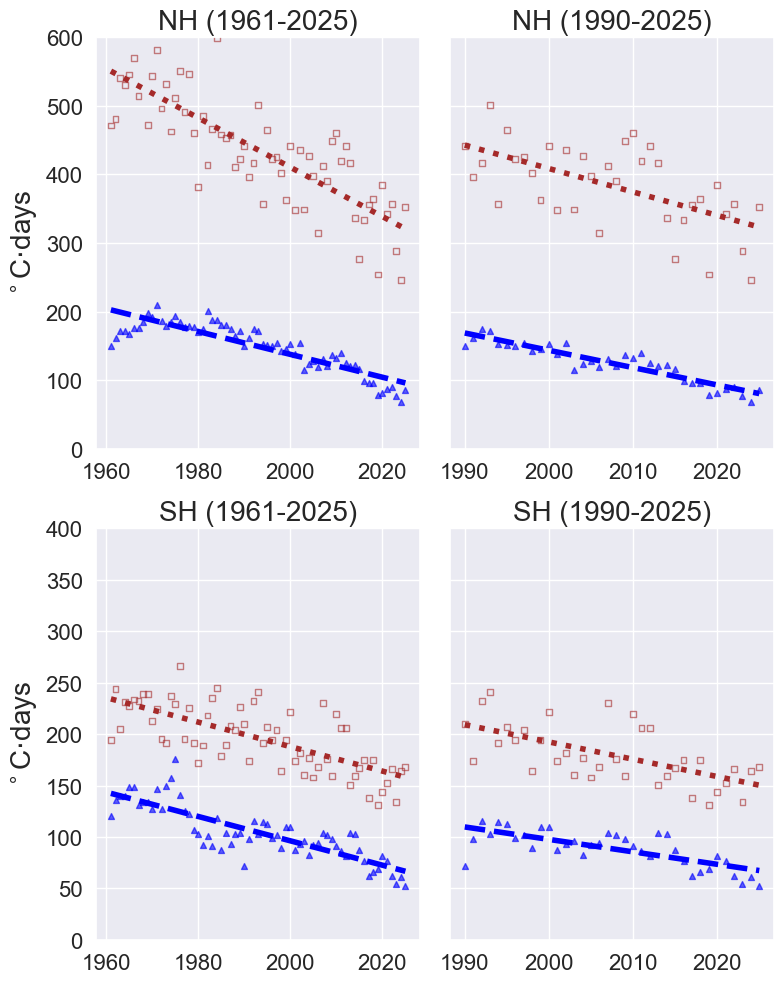

CPU times: user 156 ms, sys: 39.9 ms, total: 196 ms
Wall time: 212 ms


In [27]:
%%time

# takes 30 sec


# create blank fig
fig = plt.figure(figsize = (8,10), layout='constrained')

# Full Time Period NH
ax1 = fig.add_subplot(2,2,1)

# linear fits for slope
x_land = nh_land_full.time.dt.year.values
y_land = nh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_full.time.dt.year.values
y_ocean = nh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax1.scatter(x_land, y_land, label="NH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax1.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax1.set_title("NH (1961-2025)", fontsize = fs)
# Annotation
ann_y = 500#(ax1.get_yticks())[-3]+10
ann_x = 1965#np.mean(ax1.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade
# if (slope_ocean < 0):
#     mean_slope = mean_slope * -1

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)
ax1.set_ylabel(r'$^\circ$C$\cdot$days', fontsize=fs)
ax1.set_ylim(0,600)
#ax1.legend(loc='best')

# Full time period SH
ax2 = fig.add_subplot(2,2,3)#, sharey=ax1)

# linear fits for slope
x_land = sh_land_full.time.dt.year.values
y_land = sh_land_full[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = sh_ocean_full.time.dt.year.values
y_ocean = sh_ocean_full[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax2.scatter(x_land, y_land, label="SH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax2.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax2.set_title("SH (1961-2025)", fontsize = fs)
ax2.set_ylabel(r'$^\circ$C$\cdot$days', fontsize=fs)
# Annotation
#ann_y = (ax2.get_yticks())[-3]+10
#ann_x = np.mean(ax2.get_xticks())-15
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=True)
ax2.set_ylim(0,400)
#ax2.legend(loc='best')


# Analysis time period NH
ax3 = fig.add_subplot(2,2,2, sharey=ax1)

# linear fits for slope
x_land = nh_land_an.time.dt.year.values
y_land = nh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)

# linear fits for slope
x_ocean = nh_ocean_an.time.dt.year.values
y_ocean = nh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
ax3.scatter(x_land, y_land, label="NH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax3.set_title("NH (1990-2025)", fontsize = fs)
# Annotation - units in per decade
#ann_y = (ax3.get_yticks())[-3]+10
ann_x = 1993#np.mean(ax3.get_xticks())-8
# plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)
#ax3.legend(loc='best')


# Analysis time period SH
ax4 = fig.add_subplot(2,2,4, sharey=ax2)

# linear fits for slope
x_land = sh_land_an.time.dt.year.values
y_land = sh_land_an[v].values
coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
poly_land = np.poly1d(coefs_land)
slope_land = np.round(coefs_land[0],2)
slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_land)
ss_total = np.sum((y_land - ymean)**2)
ss_res = np.sum((y_land - poly_land(x_land))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_land = np.round(1 - (ss_res / ss_total),2)


# linear fits for slope
x_ocean = sh_ocean_an.time.dt.year.values
y_ocean = sh_ocean_an[v].values
coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
poly_ocean = np.poly1d(coefs_ocean)
slope_ocean = np.round(coefs_ocean[0],2)
slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
# add in R^2 and RMSE
ymean = np.mean(y_ocean)
ss_total = np.sum((y_ocean - ymean)**2)
ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
#rmse = np.sqrt(ss_res/365.0)
r_squared_ocean = np.round(1 - (ss_res / ss_total),2)

# plot data
ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, marker=o_m, alpha=alpha)
ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
     label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

ax4.scatter(x_land, y_land, label="SH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
     label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
ax4.set_title("SH (1990-2025)", fontsize = fs)
# Annotation - units in per decade
#ann_y = (ax4.get_yticks())[-3]+10
ann_x = 1993#np.mean(ax4.get_xticks())-8
    # plot shows mean slope across all surface types for clarity
mean_slope = np.sqrt(slope_ocean**2 + slope_land**2)/np.sqrt(2) * 10 # to get days per decade

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
#ax3.legend(loc='best')


plt.tight_layout()
# plt.savefig("./Plots/summer_heat_2x2_plot.png",bbox_inches='tight')
# plt.savefig("./Plots/summer_heat_2x2_plot.pdf",bbox_inches='tight')
plt.show()


#### reset plot vars

In [36]:
plot_vars = list(ds.data_vars)
remove_me = {'WinterTmax','WinterMeanT','WinterRMSE','lsm','Coastal'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['WinterStart', 'WinterEnd', 'WinterCold', 'WinterLength', 'WinterlikeDays']

### Reformatted without slopes for paper and only 1990-2025

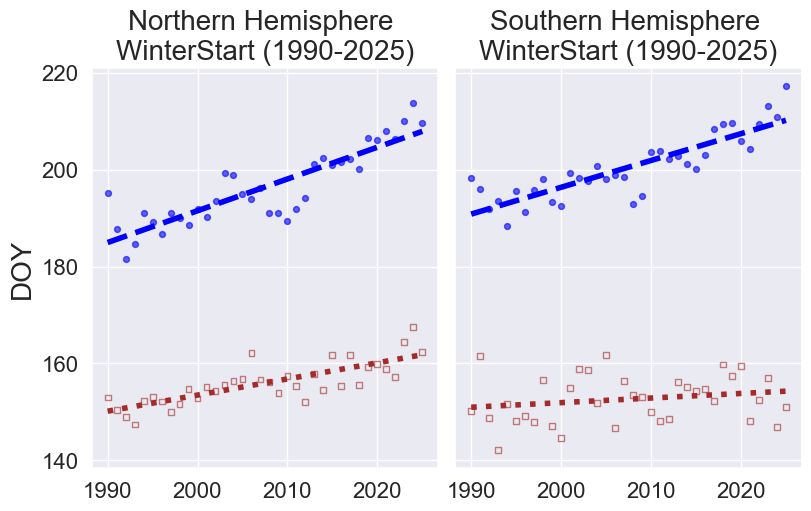

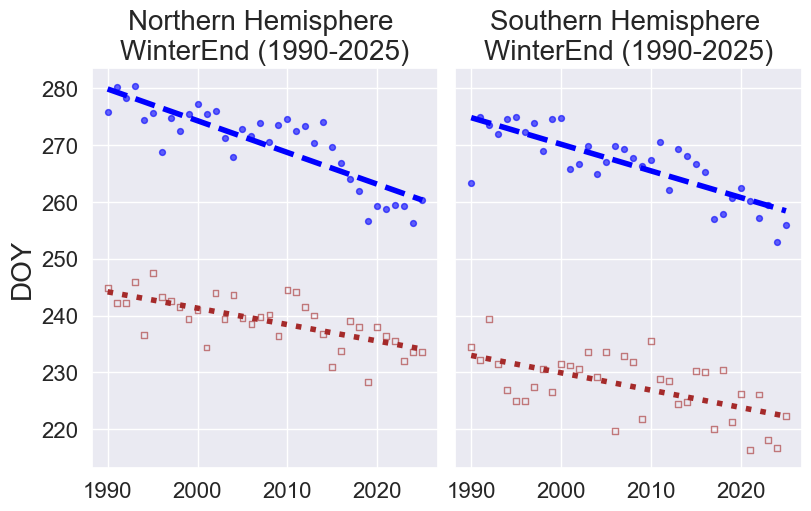

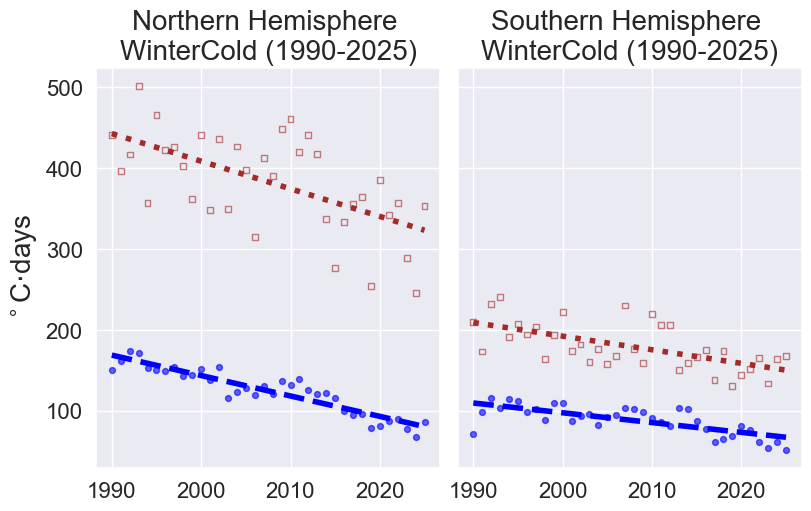

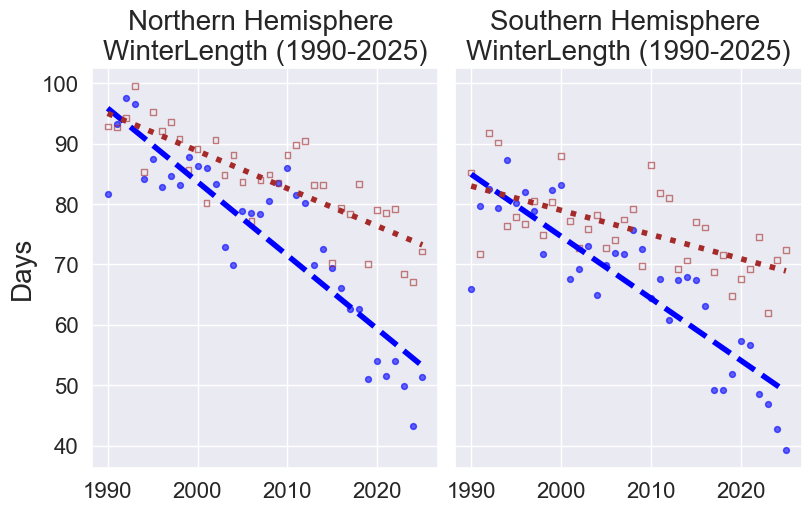

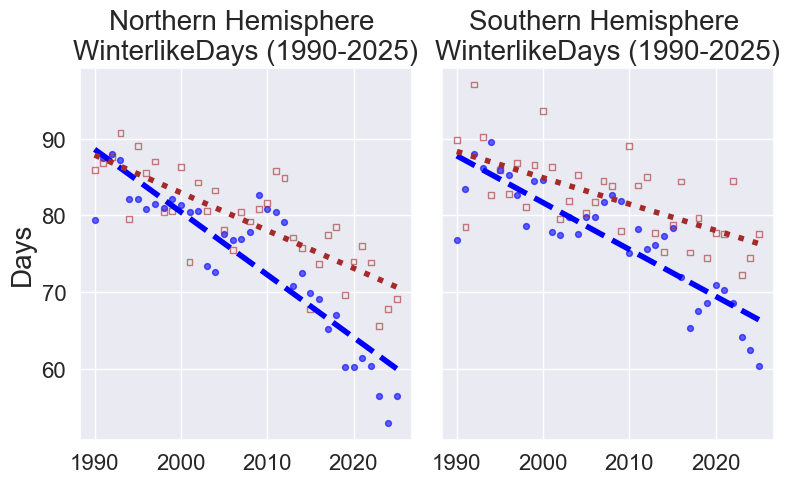

CPU times: user 414 ms, sys: 32.1 ms, total: 446 ms
Wall time: 446 ms


In [29]:
%%time

# takes 30 sec



# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (8,5), layout='constrained')   

    # Analysis time period NH
    ax3 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", s=s, alpha=alpha)
    ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax3.scatter(x_land, y_land, label="NH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
    ax3.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax3.set_title("Northern Hemisphere \n" + v + " (1990-2025)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax3.get_yticks())[-3]+8
    # ann_x = np.mean(ax3.get_xticks())-5
    # # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax3.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=16)
    if i < 2:
        ylabel = 'DOY'
    elif i == 2:
        ylabel = '$^\circ$C$\cdot$days'
    else:
        ylabel = 'Days'
    ax3.set_ylabel(ylabel, fontsize=fs)
    #ax3.legend(loc='best')

    
    # Analysis time period SH
    ax4 = fig.add_subplot(1,2,2, sharey=ax3)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", s=s, alpha=alpha)
    ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", linewidth=lw, color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax4.scatter(x_land, y_land, label="SH Land", marker=l_m, facecolors='none', edgecolors='brown', s=s, alpha=alpha)
    ax4.plot(x_land, poly_land(x_land), linestyle="dotted", linewidth=lw, color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax4.set_title("Southern Hemisphere \n" + v + " (1990-2025)", fontsize = fs)
    # Annotation - units in per decade
    # ann_y = (ax4.get_yticks())[-3]+8
    # ann_x = np.mean(ax4.get_xticks())-5
    #     # plot shows mean slope across all surface types for clarity
    # mean_slope = np.sqrt(slope_ocean**2 + slope_coast**2 + slope_land**2)/np.sqrt(3) * 10 # to get days per decade
    # if (slope_ocean < 0):
    #     mean_slope = mean_slope * -1
    # ax4.text(ann_x, ann_y, 
    #          ''+str(np.round(mean_slope,1))+r' $\frac{days}{10 yrs}$', fontsize=28, color='purple', fontweight='bold')
    
    plt.tick_params('x', labelsize=16)
    plt.tick_params('y', labelsize=6, labelleft=False)
    #ax3.legend(loc='best')


plt.tight_layout()
plt.show()

### CATEGORICAL Scatterplots for paper

#### build data frame

In [30]:
plot_vars = list(ds.data_vars)
remove_me = {'WinterTmax','WinterMeanT','WinterRMSE','lsm','Coastal'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['WinterStart', 'WinterEnd', 'WinterCold', 'WinterLength', 'WinterlikeDays']

In [31]:
%%time

# takes 20 sec

nh_full = ds.where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_full = ds.where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])
nh_an = ds.sel(time=slice('1990','2025')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_an = ds.sel(time=slice('1990','2025')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

# adding in baseline period for paper
nh_base = ds.sel(time=slice('1961','1990')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_base = ds.sel(time=slice('1961','1990')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 8.29 s, sys: 8.3 s, total: 16.6 s
Wall time: 18 s


In [32]:

# Initialize data 
plot_data = []
p_thresh = 0.05 # significance level for conf int


# loop through all plot variables
for i,v in enumerate(plot_vars):

    # full time period NH
    
    # ALL linear fits for slope
    x = nh_full.time.dt.year.values
    y = nh_full[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2) # mult by 10 to get days/decade
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  # mult by 10 to get days/decade

    # get R^2, RMSE, SE, and 95% conf int on slope value
    # help from https://mountain-hydrology-research-group.github.io/data-analysis/modules/module4/lab4-3.html
    # and https://kls2177.github.io/Climate-and-Geophysical-Data-Analysis/chapters/Week3/confidence_intervals.html

    ### *** Confirmed that the last value above is the standard error of the slope and the t-value is 2 so the 95% conf intervals are 2x the slope_all_* value
    # ymean = np.mean(y)
    # sst = np.sum((y - ymean)**2)
    # sst_x = np.sum((x - np.mean(x))**2)
    # sse = np.sum((y - poly_all(x))**2)
    # rmse = np.sqrt(sse/365.0)
    # r_squared = np.round(1 - (sse / sst),2)
    # n = len(x)
    # dof = n - 2
    # s = np.sqrt(sse/dof)
    # # std err of gradient
    # sB1 = s/np.sqrt(sst_x) *10 # mult by 10 to get days/decade
    # # t-value
    # t = stats.t.ppf(1 - p_thresh/2, dof)
    # # upper/lower ci on slope
    # slope_upper = slope_all + t*sB1
    # slope_lower = slope_all - t*sB1
    # ci = (slope_upper - slope_lower)/2

    # # quick comparison to what scipy stats linregress gives us
    # B1,B0,RR,P,SB1 = stats.linregress(x,y)
    # t_crit = stats.t.ppf(0.975,dof)
    # # calculate the 95% confidence interval on the slope
    # confidence_interval_slope = t_crit*SB1
    # print("The true value of the slope from linregress is then", np.round(B1*10,2), "+/-", np.round(confidence_interval_slope*10,2))

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'NH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-2025'}
    plot_data.append(temp_data)

    
    
    # LAND linear fits for slope
    x_land = nh_land_full.time.dt.year.values
    y_land = nh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'NH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-2025'}
    plot_data.append(temp_data)
    

    # OCEAN linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values
    y_ocean = nh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'NH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-2025'}
    plot_data.append(temp_data)

    
    # full time period SH

    # ALL linear fits for slope
    x = sh_full.time.dt.year.values
    y = sh_full[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'SH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-2025'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_land = sh_land_full.time.dt.year.values
    y_land = sh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'SH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-2025'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_ocean = sh_ocean_full.time.dt.year.values
    y_ocean = sh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'SH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-2025'}
    plot_data.append(temp_data)

    # Analysis time period NH

    # ALL linear fits for slope
    x = nh_an.time.dt.year.values
    y = nh_an[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'NH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1990-2025'}
    plot_data.append(temp_data)
    
    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'NH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1990-2025'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'NH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1990-2025'}
    plot_data.append(temp_data)

    # Analysis time period SH

    # ALL linear fits for slope
    x = sh_an.time.dt.year.values
    y = sh_an[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'SH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1990-2025'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'SH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1990-2025'}
    plot_data.append(temp_data)
    
    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'SH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1990-2025'}
    plot_data.append(temp_data)


    # Baseline time period NH

    # ALL linear fits for slope
    x = nh_base.time.dt.year.values
    y = nh_base[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'NH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)
    
    # linear fits for slope
    x_land = nh_land_base.time.dt.year.values
    y_land = nh_land_base[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'NH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)


    # linear fits for slope
    x_ocean = nh_ocean_base.time.dt.year.values
    y_ocean = nh_ocean_base[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'NH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # Baseline time period SH

    # ALL linear fits for slope
    x = sh_base.time.dt.year.values
    y = sh_base[v].values
    coefs_all, V = np.polyfit(x, y, 1, cov=True)
    poly_all = np.poly1d(coefs_all)
    slope_all = np.round(coefs_all[0]*10,2)
    slope_all_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'All', 'Hemisphere':'SH', 'Slope':slope_all, 'SE':slope_all_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    # linear fits for slope
    x_land = sh_land_base.time.dt.year.values
    y_land = sh_land_base[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Land', 'Hemisphere':'SH', 'Slope':slope_land, 'SE':slope_land_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)

    
    # linear fits for slope
    x_ocean = sh_ocean_base.time.dt.year.values
    y_ocean = sh_ocean_base[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  

    # build row of data
    temp_data = {'Metric': v, 'Surface':'Ocean', 'Hemisphere':'SH', 'Slope':slope_ocean, 'SE':slope_ocean_sd, 'Period':'1961-1990'}
    plot_data.append(temp_data)





# Creates DataFrame.
df_plot = pd.DataFrame(plot_data)
df_plot

,Metric,Surface,Hemisphere,Slope,SE,Period
0,WinterStart,All,NH,2.97,0.23,1961-2025
1,WinterStart,Land,NH,2.04,0.18,1961-2025
2,WinterStart,Ocean,NH,3.89,0.35,1961-2025
3,WinterStart,All,SH,4.11,0.29,1961-2025
4,WinterStart,Land,SH,1.16,0.31,1961-2025
...,...,...,...,...,...,...
85,WinterlikeDays,Land,NH,-2.80,0.70,1961-1990
86,WinterlikeDays,Ocean,NH,-0.18,1.05,1961-1990
87,WinterlikeDays,All,SH,-7.69,1.03,1961-1990
88,WinterlikeDays,Land,SH,-1.64,1.05,1961-1990


In [33]:
df_plot.tail(50)

,Metric,Surface,Hemisphere,Slope,SE,Period
40,WinterCold,Land,SH,-11.90,1.51,1961-2025
41,WinterCold,Ocean,SH,-11.84,0.98,1961-2025
42,WinterCold,All,NH,-29.69,4.48,1990-2025
43,WinterCold,Land,NH,-34.14,7.90,1990-2025
44,WinterCold,Ocean,NH,-25.25,1.76,1990-2025
45,WinterCold,All,SH,-12.55,1.86,1990-2025
46,WinterCold,Land,SH,-16.82,3.66,1990-2025
47,WinterCold,Ocean,SH,-12.11,1.96,1990-2025
48,WinterCold,All,NH,-18.04,6.55,1961-1990
49,WinterCold,Land,NH,-36.60,11.80,1961-1990


In [34]:
df_plot.head(50)

,Metric,Surface,Hemisphere,Slope,SE,Period
0,WinterStart,All,NH,2.97,0.23,1961-2025
1,WinterStart,Land,NH,2.04,0.18,1961-2025
2,WinterStart,Ocean,NH,3.89,0.35,1961-2025
3,WinterStart,All,SH,4.11,0.29,1961-2025
4,WinterStart,Land,SH,1.16,0.31,1961-2025
5,WinterStart,Ocean,SH,4.42,0.32,1961-2025
6,WinterStart,All,NH,4.95,0.45,1990-2025
7,WinterStart,Land,NH,3.33,0.44,1990-2025
8,WinterStart,Ocean,NH,6.56,0.63,1990-2025
9,WinterStart,All,SH,5.10,0.52,1990-2025


#### Save out the table of trends in the metrics by surface and period

In [35]:
output_file = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/ALL_winter_length_start_end_cold_trends.csv'
df_plot.to_csv(output_file, index=False)

In [36]:
# read it back in
input_file = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/ALL_winter_length_start_end_cold_trends.csv'
df_plot = pd.read_csv(input_file)
df_plot.tail(100)

,Metric,Surface,Hemisphere,Slope,SE,Period
0,WinterStart,All,NH,2.97,0.23,1961-2025
1,WinterStart,Land,NH,2.04,0.18,1961-2025
2,WinterStart,Ocean,NH,3.89,0.35,1961-2025
3,WinterStart,All,SH,4.11,0.29,1961-2025
4,WinterStart,Land,SH,1.16,0.31,1961-2025
...,...,...,...,...,...,...
85,WinterlikeDays,Land,NH,-2.80,0.70,1961-1990
86,WinterlikeDays,Ocean,NH,-0.18,1.05,1961-1990
87,WinterlikeDays,All,SH,-7.69,1.03,1961-1990
88,WinterlikeDays,Land,SH,-1.64,1.05,1961-1990


#### Make the plots as is

In [37]:


# data slices
start_full = df_plot.query('Metric == "WinterStart" & Surface == "All" & Period == "1961-2025" ')
start_an = df_plot.query('Metric == "WinterStart" & Surface == "All" & Period == "1990-2025" ')
end_full = df_plot.query('Metric == "WinterEnd" & Surface == "All" & Period == "1961-2025" ')
end_an = df_plot.query('Metric == "WinterEnd" & Surface == "All" & Period == "1990-2025" ')

start_full_land = df_plot.query('Metric == "WinterStart" & Surface == "Land" & Period == "1961-2025" ')
start_an_land = df_plot.query('Metric == "WinterStart" & Surface == "Land" & Period == "1990-2025" ')
end_full_land = df_plot.query('Metric == "WinterEnd" & Surface == "Land" & Period == "1961-2025" ')
end_an_land = df_plot.query('Metric == "WinterEnd" & Surface == "Land" & Period == "1990-2025" ')

start_full_ocean = df_plot.query('Metric == "WinterStart" & Surface == "Ocean" & Period == "1961-2025" ')
start_an_ocean = df_plot.query('Metric == "WinterStart" & Surface == "Ocean" & Period == "1990-2025" ')
end_full_ocean = df_plot.query('Metric == "WinterEnd" & Surface == "Ocean" & Period == "1961-2025" ')
end_an_ocean = df_plot.query('Metric == "WinterEnd" & Surface == "Ocean" & Period == "1990-2025" ')

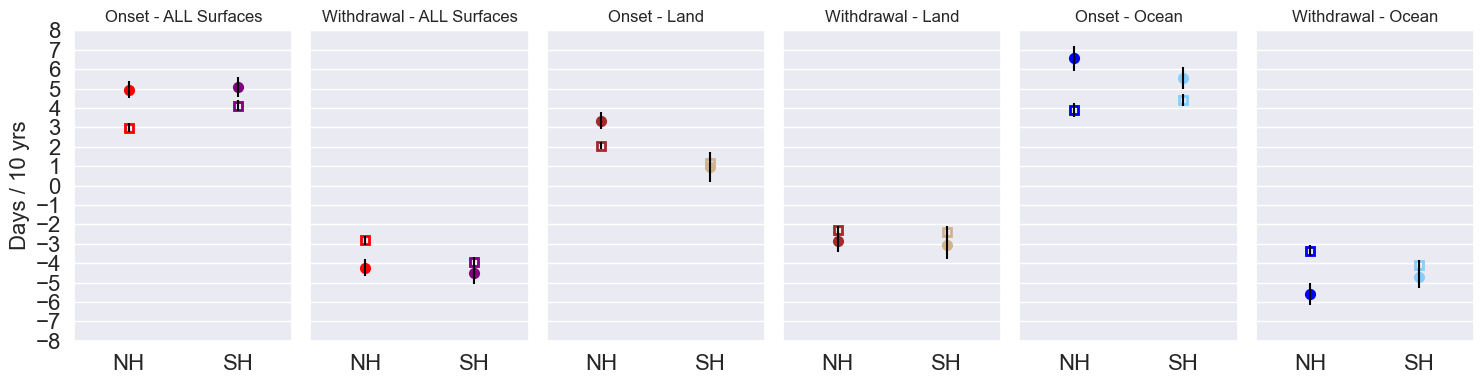

In [44]:
# plot params
ms = 6
palette_all={"NH": "red", "SH": "purple"}
palette_land={"NH": "brown", "SH": "tan"}
palette_ocean={"NH": "blue", "SH": "lightskyblue"}
xlabels = ['NH','SH']
#print(start_full, start_an)
#print(start_full, start_an)

fig=plt.figure(figsize=(15,4))#, layout='constrained')
#sns.set_context("paper")

### ALL surface average
ax1 = fig.add_subplot(1,6,1)
ax1=sns.pointplot(data=start_full, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax1.errorbar(start_full['Hemisphere'], start_full['Slope'], yerr=start_full['SE'], fmt="none", color="black")
ax1=sns.pointplot(data=start_an, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax1.errorbar(start_an['Hemisphere'], start_an['Slope'], yerr=start_an['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax1.legend(loc='upper left')
ax1.set_xlabel("")
ax1.set_ylabel("Days / 10 yrs", fontsize=16)
ax1.set_title('Onset - ALL Surfaces')
ax1.set_yticks(np.arange(-8,9,1))
ax1.set_ylim(-8,8)

ax1.set_xlim(-0.5, len(xlabels)-0.5)
#ax1.xaxis.set_major_locator(ticker.FixedLocator([0, 1, 2]))
plt.tick_params('x', labelsize=16)

plt.tick_params('y', labelsize=16)

#plt.title('Summer Onset Trends')

ax2 = fig.add_subplot(1,6,2, sharey=ax1)
ax2 = sns.pointplot(data=end_full, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax2.errorbar(end_full['Hemisphere'], end_full['Slope'], yerr=end_full['SE'], fmt="none", color="black")
ax2 = sns.pointplot(data=end_an, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax2.errorbar(end_an['Hemisphere'], end_an['Slope'], yerr=end_an['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('Withdrawal - ALL Surfaces')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax2.set_xlim(-0.5, len(xlabels)-0.5)


### Land

ax3 = fig.add_subplot(1,6,3, sharey=ax1)
ax3=sns.pointplot(data=start_full_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax3.errorbar(start_full_land['Hemisphere'], start_full_land['Slope'], yerr=start_full_land['SE'], fmt="none", color="black")
ax3=sns.pointplot(data=start_an_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax3.errorbar(start_an_land['Hemisphere'], start_an_land['Slope'], yerr=start_an_land['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('Onset - Land')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax3.set_xlim(-0.5, len(xlabels)-0.5)


ax4 = fig.add_subplot(1,6,4, sharey=ax1)
ax4 = sns.pointplot(data=end_full_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax4.errorbar(end_full_land['Hemisphere'], end_full_land['Slope'], yerr=end_full_land['SE'], fmt="none", color="black",)
ax4 = sns.pointplot(data=end_an_land, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax4.errorbar(end_an_land['Hemisphere'], end_an_land['Slope'], yerr=end_an_land['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('Withdrawal - Land')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax4.set_xlim(-0.5, len(xlabels)-0.5)


### Ocean

ax7 = fig.add_subplot(1,6,5, sharey=ax1)
ax7=sns.pointplot(data=start_full_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax7.errorbar(start_full_ocean['Hemisphere'], start_full_ocean['Slope'], yerr=start_full_ocean['SE'], fmt="none", color="black")
ax7=sns.pointplot(data=start_an_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax7.errorbar(start_an_ocean['Hemisphere'], start_an_ocean['Slope'], yerr=start_an_ocean['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax3.legend(loc='upper left')
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('Onset - Ocean')

plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax7.set_xlim(-0.5, len(xlabels)-0.5)

ax8 = fig.add_subplot(1,6,6, sharey=ax1)
ax8 = sns.pointplot(data=end_full_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax8.errorbar(end_full_ocean['Hemisphere'], end_full_ocean['Slope'], yerr=end_full_ocean['SE'], fmt="none", color="black",)
ax8 = sns.pointplot(data=end_an_ocean, x="Hemisphere", y="Slope", hue="Hemisphere", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax8.errorbar(end_an_ocean['Hemisphere'], end_an_ocean['Slope'], yerr=end_an_ocean['SE'], fmt="none", color="black")
#plt.scatter(x='Hemisphere', y='Slope', data=temp)
#ax2.legend(loc='best')
ax8.set_xlabel("")
ax8.set_ylabel("")
ax8.set_title('Withdrawal - Ocean')
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=6, labelleft=False)
ax8.set_xlim(-0.5, len(xlabels)-0.5)





plt.tight_layout()
plt.show()

## onset positive and withdrawal negative

#### Make withdrawal positive for easier comparison with onset slope value

In [51]:
# take absolute value of all slopes to switch onsets to positive numbers
df_plot['Slope'] = np.abs(df_plot['Slope'])
df_plot

,Metric,Surface,Hemisphere,Slope,SE,Period
0,WinterStart,All,NH,2.97,0.23,1961-2025
1,WinterStart,Land,NH,2.04,0.18,1961-2025
2,WinterStart,Ocean,NH,3.89,0.35,1961-2025
3,WinterStart,All,SH,4.11,0.29,1961-2025
4,WinterStart,Land,SH,1.16,0.31,1961-2025
...,...,...,...,...,...,...
85,WinterlikeDays,Land,NH,2.80,0.70,1961-1990
86,WinterlikeDays,Ocean,NH,0.18,1.05,1961-1990
87,WinterlikeDays,All,SH,7.69,1.03,1961-1990
88,WinterlikeDays,Land,SH,1.64,1.05,1961-1990


In [52]:
df_plot.query('Hemisphere == "SH" & Metric == "WinterLength"')

,Metric,Surface,Hemisphere,Slope,SE,Period
57,WinterLength,All,SH,8.09,0.50,1961-2025
58,WinterLength,Land,SH,3.55,0.38,1961-2025
59,WinterLength,Ocean,SH,8.56,0.54,1961-2025
63,WinterLength,All,SH,9.70,0.93,1990-2025
64,WinterLength,Land,SH,4.02,0.87,1990-2025
65,WinterLength,Ocean,SH,10.29,1.01,1990-2025
69,WinterLength,All,SH,12.75,1.72,1961-1990
70,WinterLength,Land,SH,2.21,1.28,1961-1990
71,WinterLength,Ocean,SH,13.85,1.83,1961-1990


#### Onset vs Withdrawal instead of by Hemisphere

In [53]:
# data slices
nh_full = df_plot.query('Hemisphere == "NH" & Metric in ["WinterStart","WinterEnd"] & Surface == "All" & Period == "1961-2025" ')
nh_an = df_plot.query('Hemisphere == "NH" & Metric in ["WinterStart","WinterEnd"] & Surface == "All" & Period == "1990-2025" ')
sh_full = df_plot.query('Hemisphere == "SH" & Metric in ["WinterStart","WinterEnd"] & Surface == "All" & Period == "1961-2025" ')
sh_an = df_plot.query('Hemisphere == "SH" & Metric in ["WinterStart","WinterEnd"] & Surface == "All" & Period == "1990-2025" ')

nh_full_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Land" & Period == "1961-2025" ')
nh_an_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Land" & Period == "1990-2025" ')
sh_full_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Land" & Period == "1961-2025" ')
sh_an_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Land" & Period == "1990-2025" ')

nh_full_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Ocean" & Period == "1961-2025" ')
nh_an_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Ocean" & Period == "1990-2025" ')
sh_full_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Ocean" & Period == "1961-2025" ')
sh_an_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterStart","WinterEnd"] & Surface == "Ocean" & Period == "1990-2025" ')


nh_full

,Metric,Surface,Hemisphere,Slope,SE,Period
0,WinterStart,All,NH,2.97,0.23,1961-2025
18,WinterEnd,All,NH,2.83,0.22,1961-2025


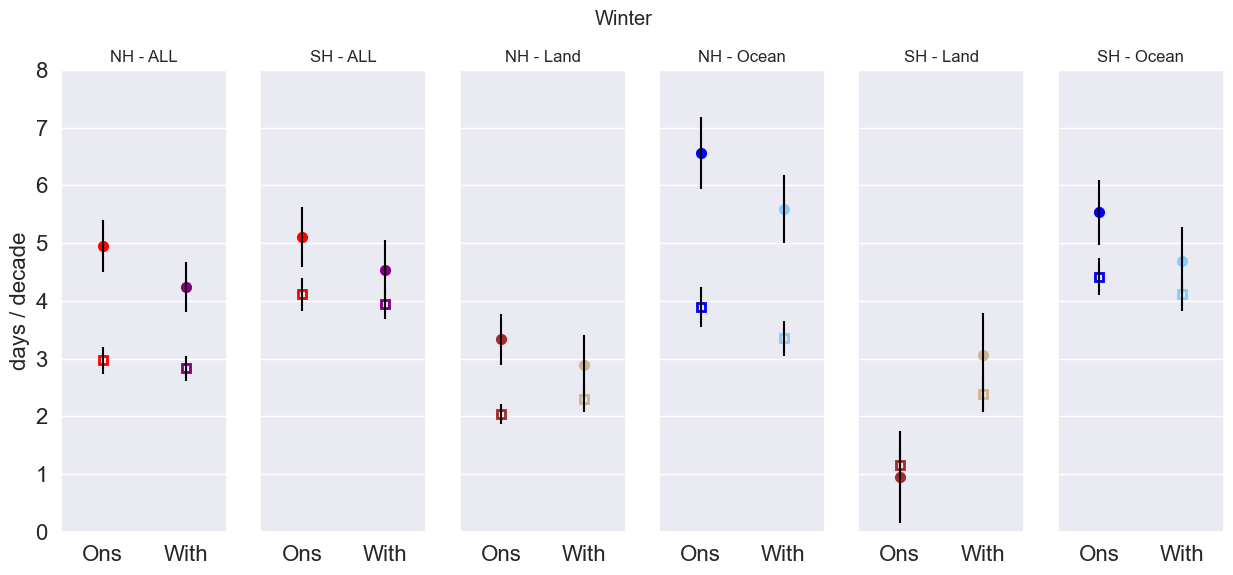

In [54]:
# plot params
ms = 6
palette_all={"WinterStart": "red", "WinterEnd": "purple"}
palette_land={"WinterStart": "brown", "WinterEnd": "tan"}
palette_ocean={"WinterStart": "blue", "WinterEnd": "lightskyblue"}
xlabels = ['Ons','With']


fig=plt.figure(figsize=(15,6))#, layout='constrained')
#sns.set_context("paper")
plt.suptitle("Winter")

### NH ALL surface average
ax1 = fig.add_subplot(1,6,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=nh_full['SE'], fmt="none", color="black")
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=nh_an['SE'], fmt="none", color="black")
ax1.set_xticks(ticks=[0,1], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("days / decade", fontsize=16)
ax1.set_title('NH - ALL', fontsize=12)
ax1.set_yticks(np.arange(-0,9,1))
ax1.set_ylim(-0,8)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)

### SH ALL surface average
ax2 = fig.add_subplot(1,6,2, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=sh_full['SE'], fmt="none", color="black")
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=sh_an['SE'], fmt="none", color="black")
ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH - ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Land surface average
ax3 = fig.add_subplot(1,6,3, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=nh_full_land['SE'], fmt="none", color="black")
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=nh_an_land['SE'], fmt="none", color="black")
ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH - Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,6,4, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=nh_full_ocean['SE'], fmt="none", color="black")
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=nh_an_ocean['SE'], fmt="none", color="black")
ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH - Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH Land surface average
ax6 = fig.add_subplot(1,6,5, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=sh_full_land['SE'], fmt="none", color="black")
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=sh_an_land['SE'], fmt="none", color="black")
ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH - Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,6,6, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=sh_full_ocean['SE'], fmt="none", color="black")
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=sh_an_ocean['SE'], fmt="none", color="black")
ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH - Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)




plt.show()


#### Grouped by Hemisphere and error as 95% conf intervals

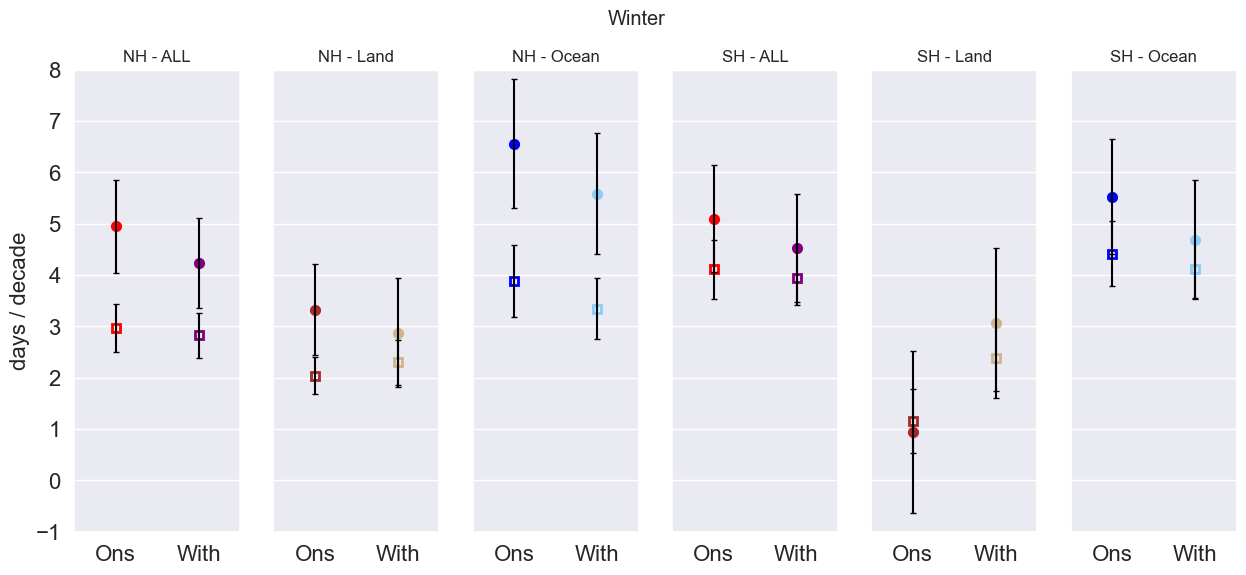

In [57]:
# plot params
ms = 6
caps = 2
palette_all={"WinterStart": "red", "WinterEnd": "purple"}
palette_land={"WinterStart": "brown", "WinterEnd": "tan"}

palette_ocean={"WinterStart": "blue", "WinterEnd": "lightskyblue"}
xlabels = ['Ons','With']


fig=plt.figure(figsize=(15,6))#, layout='constrained')
#sns.set_context("paper")
plt.suptitle("Winter")
#### Errors are multiplied by 2 to show 95% confidence values instead of 1 SE)


### NH ALL surface average
ax1 = fig.add_subplot(1,6,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=2*nh_full['SE'], fmt="none", color="black", capsize=caps)
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=2*nh_an['SE'], fmt="none", color="black", capsize=caps)
ax1.set_xticks(ticks=[0,1], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("days / decade", fontsize=16)
ax1.set_title('NH - ALL', fontsize=12)
ax1.set_yticks(np.arange(-1,9,1))
ax1.set_ylim(-1,8)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16)


### NH Land surface average
ax3 = fig.add_subplot(1,6,2, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=2*nh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=2*nh_an_land['SE'], fmt="none", color="black", capsize=caps)
ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH - Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,6,3, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=2*nh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=2*nh_an_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH - Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH ALL surface average
ax2 = fig.add_subplot(1,6,4, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=2*sh_full['SE'], fmt="none", color="black", capsize=caps)
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=2*sh_an['SE'], fmt="none", color="black", capsize=caps)
ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH - ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,6,5, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=2*sh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=2*sh_an_land['SE'], fmt="none", capsize=caps, color="black")
ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH - Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,6,6, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=2*sh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=2*sh_an_ocean['SE'], fmt="none", capsize=caps, color="black")
ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH - Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16)
plt.tick_params('y', labelsize=16, labelleft=False)


# plt.savefig("./Plots/All_Hemispheric_Onset_Withdrawal_Trends_with_error.png",bbox_inches='tight')
# plt.savefig("./Plots/All_Hemispheric_Onset_Withdrawal_Trends_with_error.pdf",bbox_inches='tight')

plt.show()


### Test for Stat Sig slope differences between onset and withdrawal 1990-2025

In [68]:
# help from https://stackoverflow.com/questions/66110650/how-to-compare-the-slopes-of-two-regression-lines
# and https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html
# x=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
# blue_y = np.array([0.94732871, 0.85729212, 0.86039587, 0.89169027, 0.90817473, 0.93606619, 0.93890423, 1., 0.97783521, 0.93035495])
# light_blue_y = np.array([0.81346023, 0.72248919, 0.72406021, 0.74823437, 0.77759055, 0.81167983,  0.84050726, 0.90357904, 0.97354455, 1. ])

# y = blue_y-light_blue_y
# # Let create a linear regression
# mod = sm.OLS(y, sm.add_constant(x))
# res = mod.fit()
# print(res.summary())
# #dir(res)
# # conf int on slope - if it contains zero then the diff is not significant
# print(res.conf_int()[1])
# if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
#     print("contains zero") 
# else: 
#     print("sig")

In [58]:
%%time
# build datasets again because I rewrote their names above :(

nh_an_dat = ds.sel(time=slice('1990','2025')).where(((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])
sh_an_dat = ds.sel(time=slice('1990','2025')).where(((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


nh_land_an_dat = ds.sel(time=slice('1990','2025')).where((ds.lsm > 0.5)  & 
                                                          ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_land_an_dat = ds.sel(time=slice('1990','2025')).where((ds.lsm > 0.5)  & 
                                                          ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])

nh_ocean_an_dat = ds.sel(time=slice('1990','2025')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= nh_min) & (ds.lat <= nh_max))).weighted(weights).mean(dim=['lat','lon'])

sh_ocean_an_dat = ds.sel(time=slice('1990','2025')).where((ds.lsm <= 0.5) & 
                                                           ((ds.lat >= sh_max) & (ds.lat <= sh_min))).weighted(weights).mean(dim=['lat','lon'])


CPU times: user 7.2 s, sys: 7.74 s, total: 14.9 s
Wall time: 16 s


In [59]:
x = nh_an_dat.time.dt.year.values
y1 = nh_an_dat.WinterStart.values
y2 = nh_an_dat.WinterEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
# plt.plot(x,y2, c='blue')
# plt.plot(x,y1, c='red')
# plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.01878508  0.16067383]
not sig contains zero


In [60]:
x = nh_land_an_dat.time.dt.year.values
y1 = nh_land_an_dat.WinterStart.values
y2 = nh_land_an_dat.WinterEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)
y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.08048383  0.17011498]
not sig contains zero


In [61]:
x = nh_ocean_an_dat.time.dt.year.values
y1 = nh_ocean_an_dat.WinterStart.values
y2 = nh_ocean_an_dat.WinterEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)
y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.02484162  0.21889788]
not sig contains zero


[-0.04561578  0.15914006]
not sig contains zero


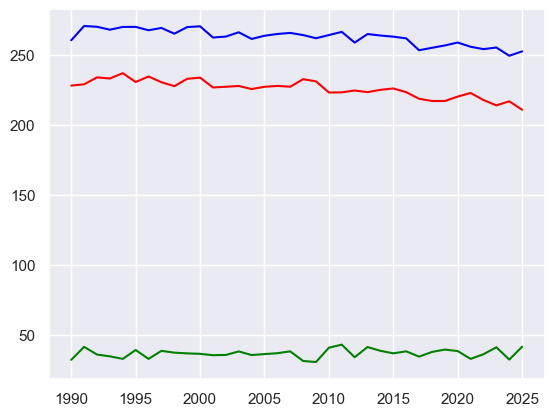

In [62]:
x = sh_an_dat.time.dt.year.values
y1 = sh_an_dat.WinterStart.values
y2 = sh_an_dat.WinterEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

[-0.46451347  0.04287229]
not sig contains zero


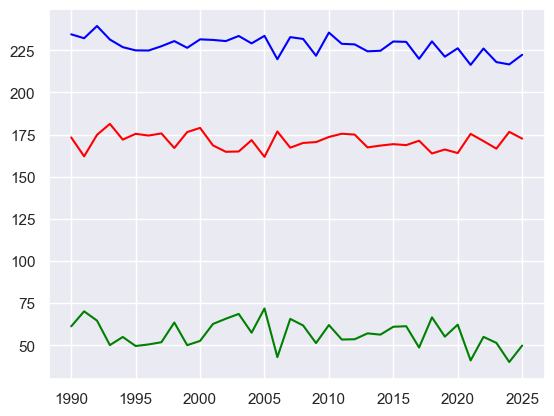

In [63]:
x = sh_land_an_dat.time.dt.year.values
y1 = sh_land_an_dat.WinterStart.values
y2 = sh_land_an_dat.WinterEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
#print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     2.523
Date:                Wed, 23 Sep 2026   Prob (F-statistic):              0.121
Time:                        11:05:49   Log-Likelihood:                -93.243
No. Observations:                  36   AIC:                             190.5
Df Residuals:                      34   BIC:                             193.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -137.1359    106.906     -1.283      0.2

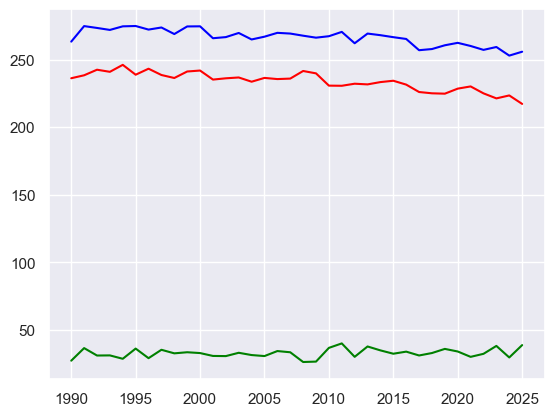

In [64]:
x = sh_ocean_an_dat.time.dt.year.values
y1 = sh_ocean_an_dat.WinterStart.values
y2 = sh_ocean_an_dat.WinterEnd.values

# have to reflect y1 so that both onset and with are increasing over time
y1 = np.max(y1) - y1 + np.max(y1)

# check with plot
plt.plot(x,y2, c='blue')
plt.plot(x,y1, c='red')
plt.plot(x, y2-y1, c='green')

y = y2-y1
# Let create a linear regression
mod = sm.OLS(y, sm.add_constant(x))
res = mod.fit()
print(res.summary())
# conf int on slope - if it contains zero then the diff is not significant
print(res.conf_int()[1])
if res.conf_int()[1][0] < 0.0 < res.conf_int()[1][1]: 
    print("not sig contains zero") 
else: 
    print("sig")

## Reload data for Accumulated Cold to get original slopes

In [66]:
# read it back in
input_file = '../../../../Data/ERA5-global/Analysis/New-Fourier/Winter/ALL_winter_length_start_end_cold_trends.csv'
df_plot = pd.read_csv(input_file)
df_plot.tail(100)

,Metric,Surface,Hemisphere,Slope,SE,Period
0,WinterStart,All,NH,2.97,0.23,1961-2025
1,WinterStart,Land,NH,2.04,0.18,1961-2025
2,WinterStart,Ocean,NH,3.89,0.35,1961-2025
3,WinterStart,All,SH,4.11,0.29,1961-2025
4,WinterStart,Land,SH,1.16,0.31,1961-2025
...,...,...,...,...,...,...
85,WinterlikeDays,Land,NH,-2.80,0.70,1961-1990
86,WinterlikeDays,Ocean,NH,-0.18,1.05,1961-1990
87,WinterlikeDays,All,SH,-7.69,1.03,1961-1990
88,WinterlikeDays,Land,SH,-1.64,1.05,1961-1990


In [67]:
df_plot.query('Metric in ["WinterCold"] & Surface == "All" ')

,Metric,Surface,Hemisphere,Slope,SE,Period
36,WinterCold,All,NH,-26.29,1.96,1961-2025
39,WinterCold,All,SH,-11.84,0.93,1961-2025
42,WinterCold,All,NH,-29.69,4.48,1990-2025
45,WinterCold,All,SH,-12.55,1.86,1990-2025
48,WinterCold,All,NH,-18.04,6.55,1961-1990
51,WinterCold,All,SH,-18.63,3.48,1961-1990


#### Accumulated Cold Plots

In [68]:
# data slices
nh_full = df_plot.query('Hemisphere == "NH" & Metric in ["WinterCold"] & Surface == "All" & Period == "1961-2025" ')
nh_an = df_plot.query('Hemisphere == "NH" & Metric in ["WinterCold"] & Surface == "All" & Period == "1990-2025" ')
sh_full = df_plot.query('Hemisphere == "SH" & Metric in ["WinterCold"] & Surface == "All" & Period == "1961-2025" ')
sh_an = df_plot.query('Hemisphere == "SH" & Metric in ["WinterCold"] & Surface == "All" & Period == "1990-2025" ')

nh_full_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterCold"] & Surface == "Land" & Period == "1961-2025" ')
nh_an_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterCold"] & Surface == "Land" & Period == "1990-2025" ')
sh_full_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterCold"] & Surface == "Land" & Period == "1961-2025" ')
sh_an_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterCold"] & Surface == "Land" & Period == "1990-2025" ')

nh_full_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterCold"] & Surface == "Ocean" & Period == "1961-2025" ')
nh_an_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterCold"] & Surface == "Ocean" & Period == "1990-2025" ')
sh_full_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterCold"] & Surface == "Ocean" & Period == "1961-2025" ')
sh_an_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterCold"] & Surface == "Ocean" & Period == "1990-2025" ')

nh_full

,Metric,Surface,Hemisphere,Slope,SE,Period
36,WinterCold,All,NH,-26.29,1.96,1961-2025


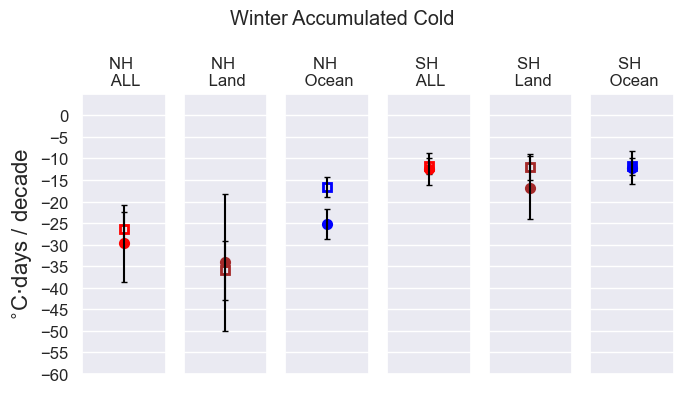

In [69]:
# plot params
ms = 6
caps = 2
palette_all={"WinterCold": "red"}
palette_land={"WinterCold": "brown"}
palette_ocean={"WinterCold": "blue"}
xlabels = ['Heat']


fig=plt.figure(figsize=(7,4))#, layout='constrained')
#sns.set_context("paper")

plt.suptitle("Winter Accumulated Cold")
#### Errors are multiplied by 2 to show 95% confidence values instead of 1 SE)


### NH ALL surface average
ax1 = fig.add_subplot(1,6,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=2*nh_full['SE'], fmt="none", color="black", capsize=caps)
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=2*nh_an['SE'], fmt="none", color="black", capsize=caps)
#ax1.set_xticks(ticks=[0.5], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("$^{\circ}$C$\cdot$days / decade", fontsize=16)
ax1.set_title('NH \n ALL', fontsize=12)
ax1.set_yticks(np.arange(-60,5,5), minor=False)
ax1.set_ylim(-60,5)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=12)


### NH Land surface average
ax3 = fig.add_subplot(1,6,2, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=2*nh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=2*nh_an_land['SE'], fmt="none", color="black", capsize=caps)
#ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH \n Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,6,3, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=2*nh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=2*nh_an_ocean['SE'], fmt="none", color="black", capsize=caps)
#ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH \n Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH ALL surface average
ax2 = fig.add_subplot(1,6,4, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=2*sh_full['SE'], fmt="none", color="black", capsize=caps)
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=2*sh_an['SE'], fmt="none", color="black", capsize=caps)
#ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH \n ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,6,5, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=2*sh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=2*sh_an_land['SE'], fmt="none", capsize=caps, color="black")
#ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH \n Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,6,6, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=2*sh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=2*sh_an_ocean['SE'], fmt="none", capsize=caps, color="black")
#ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH \n Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)


# plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.png",bbox_inches='tight')
# plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.pdf",bbox_inches='tight')
plt.tight_layout()
plt.show()


In [63]:
from matplotlib import markers
print(markers.MarkerStyle.markers.keys())

dict_keys(['.', ',', 'o', 'v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p', '*', 'h', 'H', '+', 'x', 'D', 'd', '|', '_', 'P', 'X', 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 'None', 'none', ' ', ''])


### Winterlike Days Plots

In [70]:
df_plot.query('Metric in ["WinterlikeDays"] & Surface == "All" ')

,Metric,Surface,Hemisphere,Slope,SE,Period
72,WinterlikeDays,All,NH,-4.54,0.29,1961-2025
75,WinterlikeDays,All,SH,-4.91,0.30,1961-2025
78,WinterlikeDays,All,NH,-6.54,0.58,1990-2025
81,WinterlikeDays,All,SH,-5.86,0.57,1990-2025
84,WinterlikeDays,All,NH,-1.49,0.78,1961-1990
87,WinterlikeDays,All,SH,-7.69,1.03,1961-1990


In [91]:
# data slices
nh_full = df_plot.query('Hemisphere == "NH" & Metric in ["WinterlikeDays"] & Surface == "All" & Period == "1961-2025" ')
nh_an = df_plot.query('Hemisphere == "NH" & Metric in ["WinterlikeDays"] & Surface == "All" & Period == "1990-2025" ')
sh_full = df_plot.query('Hemisphere == "SH" & Metric in ["WinterlikeDays"] & Surface == "All" & Period == "1961-2025" ')
sh_an = df_plot.query('Hemisphere == "SH" & Metric in ["WinterlikeDays"] & Surface == "All" & Period == "1990-2025" ')

nh_full_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterlikeDays"] & Surface == "Land" & Period == "1961-2025" ')
nh_an_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterlikeDays"] & Surface == "Land" & Period == "1990-2025" ')
sh_full_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterlikeDays"] & Surface == "Land" & Period == "1961-2025" ')
sh_an_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterlikeDays"] & Surface == "Land" & Period == "1990-2025" ')

nh_full_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterlikeDays"] & Surface == "Ocean" & Period == "1961-2025" ')
nh_an_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterlikeDays"] & Surface == "Ocean" & Period == "1990-2025" ')
sh_full_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterlikeDays"] & Surface == "Ocean" & Period == "1961-2025" ')
sh_an_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterlikeDays"] & Surface == "Ocean" & Period == "1990-2025" ')

nh_full

,Metric,Surface,Hemisphere,Slope,SE,Period
72,WinterlikeDays,All,NH,-4.54,0.29,1961-2025


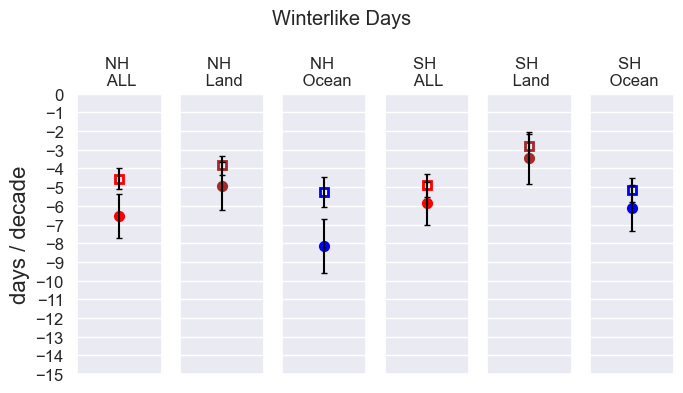

In [93]:
# plot params
ms = 6
caps = 2
palette_all={"WinterlikeDays": "red"}
palette_land={"WinterlikeDays": "brown"}
palette_ocean={"WinterlikeDays": "blue"}
xlabels = ['Heat']


fig=plt.figure(figsize=(7,4))#, layout='constrained')
#sns.set_context("paper")

plt.suptitle("Winterlike Days")
#### Errors are multiplied by 2 to show 95% confidence values instead of 1 SE)


### NH ALL surface average
ax1 = fig.add_subplot(1,6,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=2*nh_full['SE'], fmt="none", color="black", capsize=caps)
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=2*nh_an['SE'], fmt="none", color="black", capsize=caps)
#ax1.set_xticks(ticks=[0.5], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("days / decade", fontsize=16)
ax1.set_title('NH \n ALL', fontsize=12)
ax1.set_yticks(np.arange(-15,1,1), minor=False)
ax1.set_ylim(-15,0)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=12)


### NH Land surface average
ax3 = fig.add_subplot(1,6,2, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=2*nh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=2*nh_an_land['SE'], fmt="none", color="black", capsize=caps)
#ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH \n Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,6,3, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=2*nh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=2*nh_an_ocean['SE'], fmt="none", color="black", capsize=caps)
#ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH \n Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH ALL surface average
ax2 = fig.add_subplot(1,6,4, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=2*sh_full['SE'], fmt="none", color="black", capsize=caps)
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=2*sh_an['SE'], fmt="none", color="black", capsize=caps)
#ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH \n ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,6,5, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=2*sh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=2*sh_an_land['SE'], fmt="none", capsize=caps, color="black")
#ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH \n Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,6,6, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=2*sh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=2*sh_an_ocean['SE'], fmt="none", capsize=caps, color="black")
#ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH \n Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)



# plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.png",bbox_inches='tight')
# plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.pdf",bbox_inches='tight')
plt.tight_layout()
plt.show()


### Compare with Winterlength

In [73]:
df_plot.query('Metric in ["WinterLength"] & Surface == "All" ')

,Metric,Surface,Hemisphere,Slope,SE,Period
54,WinterLength,All,NH,-5.81,0.40,1961-2025
57,WinterLength,All,SH,-8.09,0.50,1961-2025
60,WinterLength,All,NH,-9.22,0.78,1990-2025
63,WinterLength,All,SH,-9.70,0.93,1990-2025
66,WinterLength,All,NH,-1.10,0.99,1961-1990
69,WinterLength,All,SH,-12.75,1.72,1961-1990


In [74]:
# data slices
nh_full = df_plot.query('Hemisphere == "NH" & Metric in ["WinterLength"] & Surface == "All" & Period == "1961-2025" ')
nh_an = df_plot.query('Hemisphere == "NH" & Metric in ["WinterLength"] & Surface == "All" & Period == "1990-2025" ')
sh_full = df_plot.query('Hemisphere == "SH" & Metric in ["WinterLength"] & Surface == "All" & Period == "1961-2025" ')
sh_an = df_plot.query('Hemisphere == "SH" & Metric in ["WinterLength"] & Surface == "All" & Period == "1990-2025" ')

nh_full_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterLength"] & Surface == "Land" & Period == "1961-2025" ')
nh_an_land = df_plot.query('Hemisphere == "NH" & Metric in ["WinterLength"] & Surface == "Land" & Period == "1990-2025" ')
sh_full_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterLength"] & Surface == "Land" & Period == "1961-2025" ')
sh_an_land = df_plot.query('Hemisphere == "SH" & Metric in ["WinterLength"] & Surface == "Land" & Period == "1990-2025" ')

nh_full_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterLength"] & Surface == "Ocean" & Period == "1961-2025" ')
nh_an_ocean = df_plot.query('Hemisphere == "NH" & Metric in ["WinterLength"] & Surface == "Ocean" & Period == "1990-2025" ')
sh_full_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterLength"] & Surface == "Ocean" & Period == "1961-2025" ')
sh_an_ocean = df_plot.query('Hemisphere == "SH" & Metric in ["WinterLength"] & Surface == "Ocean" & Period == "1990-2025" ')

nh_full

,Metric,Surface,Hemisphere,Slope,SE,Period
54,WinterLength,All,NH,-5.81,0.4,1961-2025


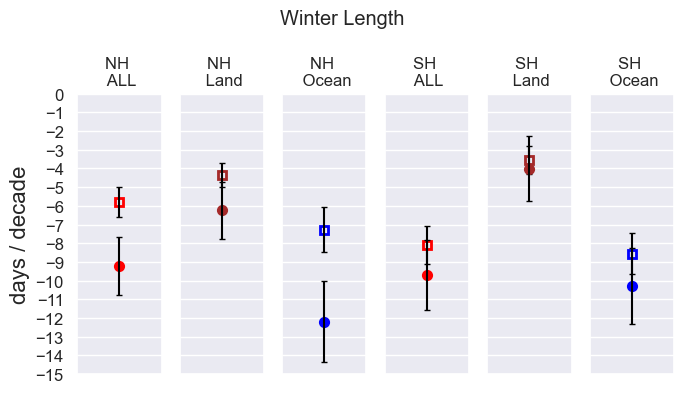

In [77]:
# plot params
ms = 6
caps = 2
palette_all={"WinterLength": "red"}
palette_land={"WinterLength": "brown"}
palette_ocean={"WinterLength": "blue"}
# xlabels = ['Heat']


fig=plt.figure(figsize=(7,4))#, layout='constrained')
#sns.set_context("paper")

plt.suptitle("Winter Length")
#### Errors are multiplied by 2 to show 95% confidence values instead of 1 SE)


### NH ALL surface average
ax1 = fig.add_subplot(1,6,1)
ax1 = sns.pointplot(data=nh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax1.errorbar(nh_full['Metric'], nh_full['Slope'], yerr=2*nh_full['SE'], fmt="none", color="black", capsize=caps)
ax1 = sns.pointplot(data=nh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax1.errorbar(nh_an['Metric'], nh_an['Slope'], yerr=2*nh_an['SE'], fmt="none", color="black", capsize=caps)
#ax1.set_xticks(ticks=[0.5], labels=xlabels)
ax1.set_xlabel("")
ax1.set_ylabel("days / decade", fontsize=16)
ax1.set_title('NH \n ALL', fontsize=12)
ax1.set_yticks(np.arange(-15,1,1), minor=False)
ax1.set_ylim(-15,0)
ax1.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=12)


### NH Land surface average
ax3 = fig.add_subplot(1,6,2, sharey=ax1)
ax3 = sns.pointplot(data=nh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax3.errorbar(nh_full_land['Metric'], nh_full_land['Slope'], yerr=2*nh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax3 = sns.pointplot(data=nh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax3.errorbar(nh_an_land['Metric'], nh_an_land['Slope'], yerr=2*nh_an_land['SE'], fmt="none", color="black", capsize=caps)
#ax3.set_xticks(ticks=[0,1], labels=xlabels)
ax3.set_xlabel("")
ax3.set_ylabel("")
ax3.set_title('NH \n Land', fontsize=12)
ax3.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### NH Ocean surface average
ax4 = fig.add_subplot(1,6,3, sharey=ax1)
ax4 = sns.pointplot(data=nh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax4.errorbar(nh_full_ocean['Metric'], nh_full_ocean['Slope'], yerr=2*nh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax4 = sns.pointplot(data=nh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax4.errorbar(nh_an_ocean['Metric'], nh_an_ocean['Slope'], yerr=2*nh_an_ocean['SE'], fmt="none", color="black", capsize=caps)
#ax4.set_xticks(ticks=[0,1], labels=xlabels)
ax4.set_xlabel("")
ax4.set_ylabel("")
ax4.set_title('NH \n Ocean', fontsize=12)
ax4.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)


### SH ALL surface average
ax2 = fig.add_subplot(1,6,4, sharey=ax1)
ax2=sns.pointplot(data=sh_full, x='Metric', y="Slope", hue="Metric", palette=palette_all, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax2.errorbar(sh_full['Metric'], sh_full['Slope'], yerr=2*sh_full['SE'], fmt="none", color="black", capsize=caps)
ax2=sns.pointplot(data=sh_an, x="Metric", y="Slope", hue="Metric", palette=palette_all, markers=['o','o'], label="1990-2025", markersize=ms)
ax2.errorbar(sh_an['Metric'], sh_an['Slope'], yerr=2*sh_an['SE'], fmt="none", color="black", capsize=caps)
#ax2.set_xticks(ticks=[0,1], labels=xlabels)
ax2.set_xlabel("")
ax2.set_ylabel("")
ax2.set_title('SH \n ALL', fontsize=12)
ax2.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Land surface average
ax6 = fig.add_subplot(1,6,5, sharey=ax1)
ax6 = sns.pointplot(data=sh_full_land, x='Metric', y="Slope", hue="Metric", palette=palette_land, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax6.errorbar(sh_full_land['Metric'], sh_full_land['Slope'], yerr=2*sh_full_land['SE'], fmt="none", color="black", capsize=caps)
ax6 = sns.pointplot(data=sh_an_land, x="Metric", y="Slope", hue="Metric", palette=palette_land, markers=['o','o'], label="1990-2025", markersize=ms)
ax6.errorbar(sh_an_land['Metric'], sh_an_land['Slope'], yerr=2*sh_an_land['SE'], fmt="none", capsize=caps, color="black")
#ax6.set_xticks(ticks=[0,1], labels=xlabels)
ax6.set_xlabel("")
ax6.set_ylabel("")
ax6.set_title('SH \n Land', fontsize=12)
ax6.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)

### SH Ocean surface average
ax7 = fig.add_subplot(1,6,6, sharey=ax1)
ax7 = sns.pointplot(data=sh_full_ocean, x='Metric', y="Slope", hue="Metric", palette=palette_ocean, markers=['s','s'], label="1961-2025", markersize=ms, fillstyle='none')
ax7.errorbar(sh_full_ocean['Metric'], sh_full_ocean['Slope'], yerr=2*sh_full_ocean['SE'], fmt="none", color="black", capsize=caps)
ax7 = sns.pointplot(data=sh_an_ocean, x="Metric", y="Slope", hue="Metric", palette=palette_ocean, markers=['o','o'], label="1990-2025", markersize=ms)
ax7.errorbar(sh_an_ocean['Metric'], sh_an_ocean['Slope'], yerr=2*sh_an_ocean['SE'], fmt="none", capsize=caps, color="black")
#ax7.set_xticks(ticks=[0,1], labels=xlabels)
ax7.set_xlabel("")
ax7.set_ylabel("")
ax7.set_title('SH \n Ocean', fontsize=12)
ax7.set_xlim(-0.5, len(xlabels)-0.5)
plt.tick_params('x', labelsize=16, labelbottom=False)
plt.tick_params('y', labelsize=16, labelleft=False)



# plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.png",bbox_inches='tight')
# plt.savefig("./Plots/AccumulatedHeat_Trends_by_surface_with_errorbars.pdf",bbox_inches='tight')
plt.tight_layout()
plt.show()


## All three surface scatterplots, most vars: Land (that is not Coastal), Coastal, Ocean

In [78]:
plot_vars = list(ds.data_vars)
remove_me = {'WinterTmax','WinterMeanT','WinterRMSE','lsm','Coastal'}
plot_vars = [item for item in plot_vars if item not in remove_me]
plot_vars

['WinterStart', 'WinterEnd', 'WinterCold', 'WinterLength', 'WinterlikeDays']

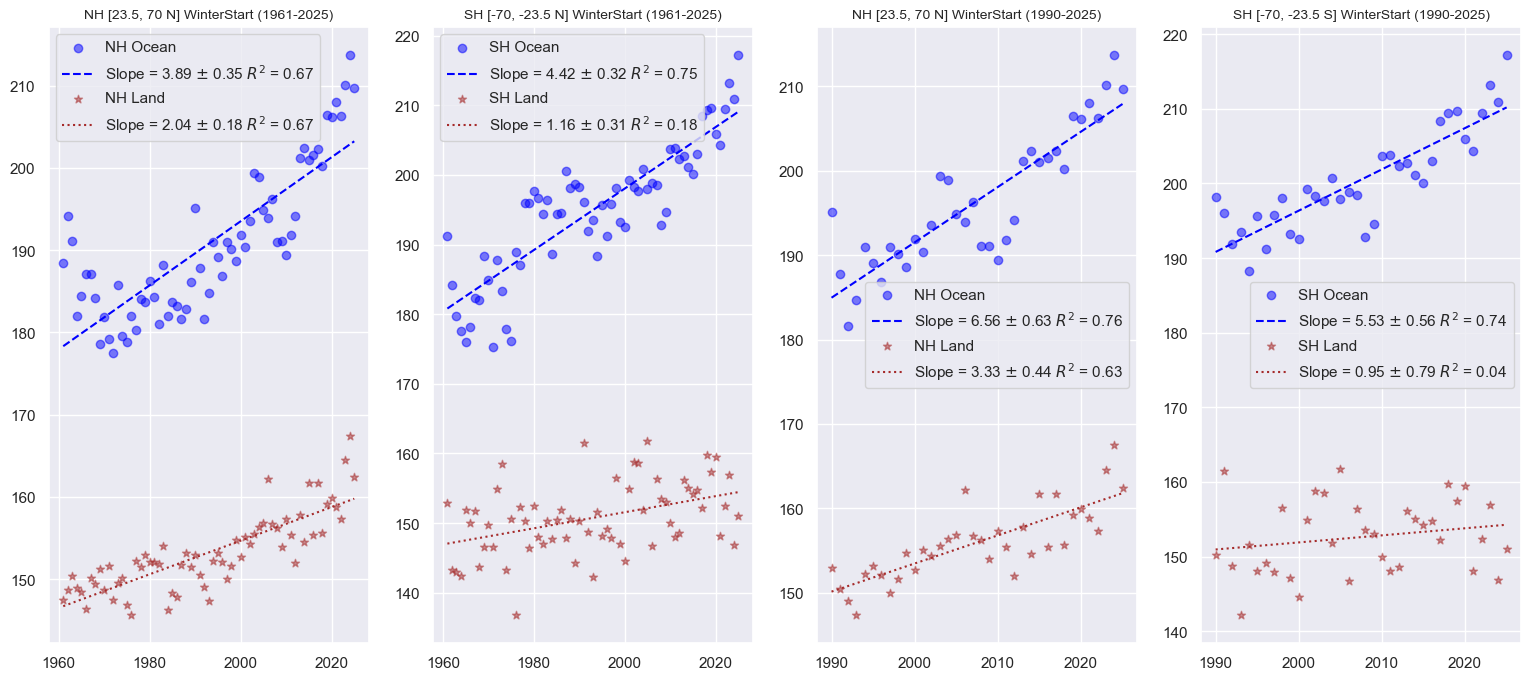

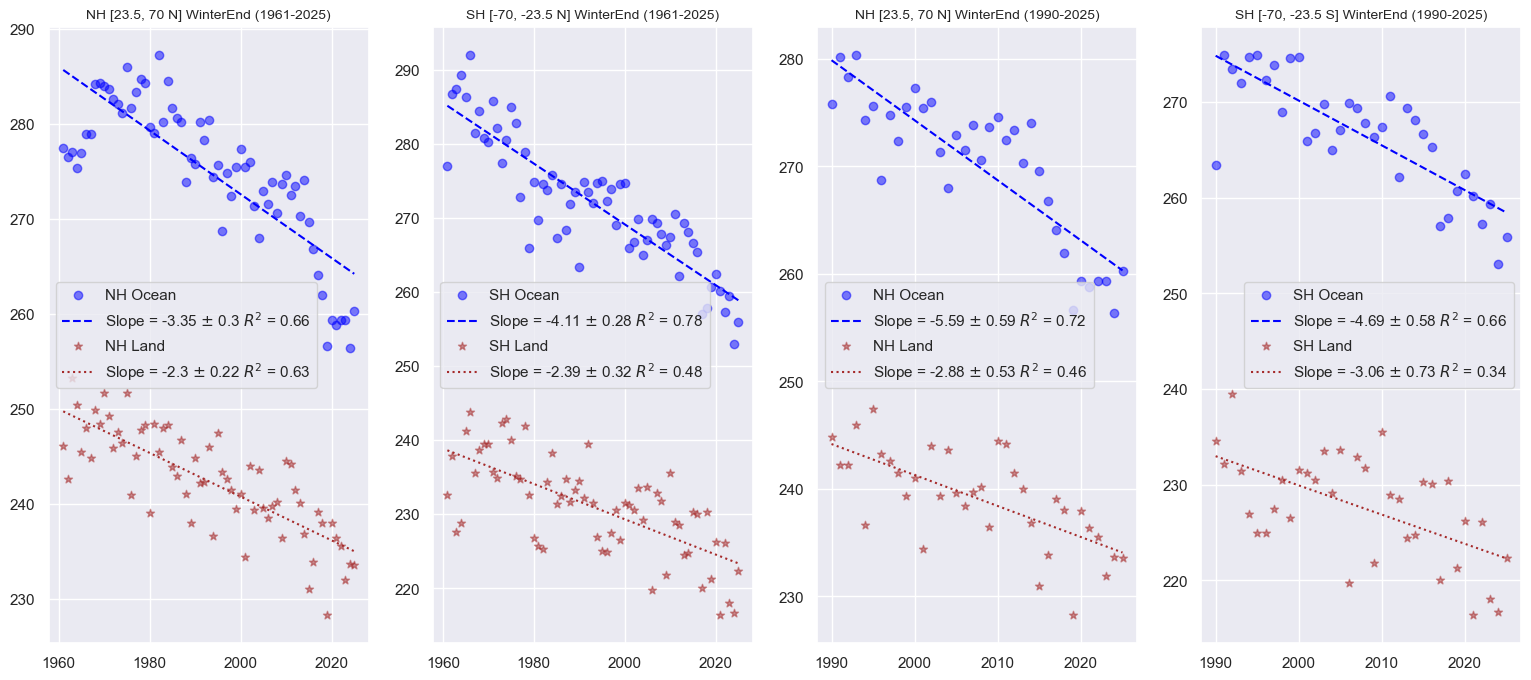

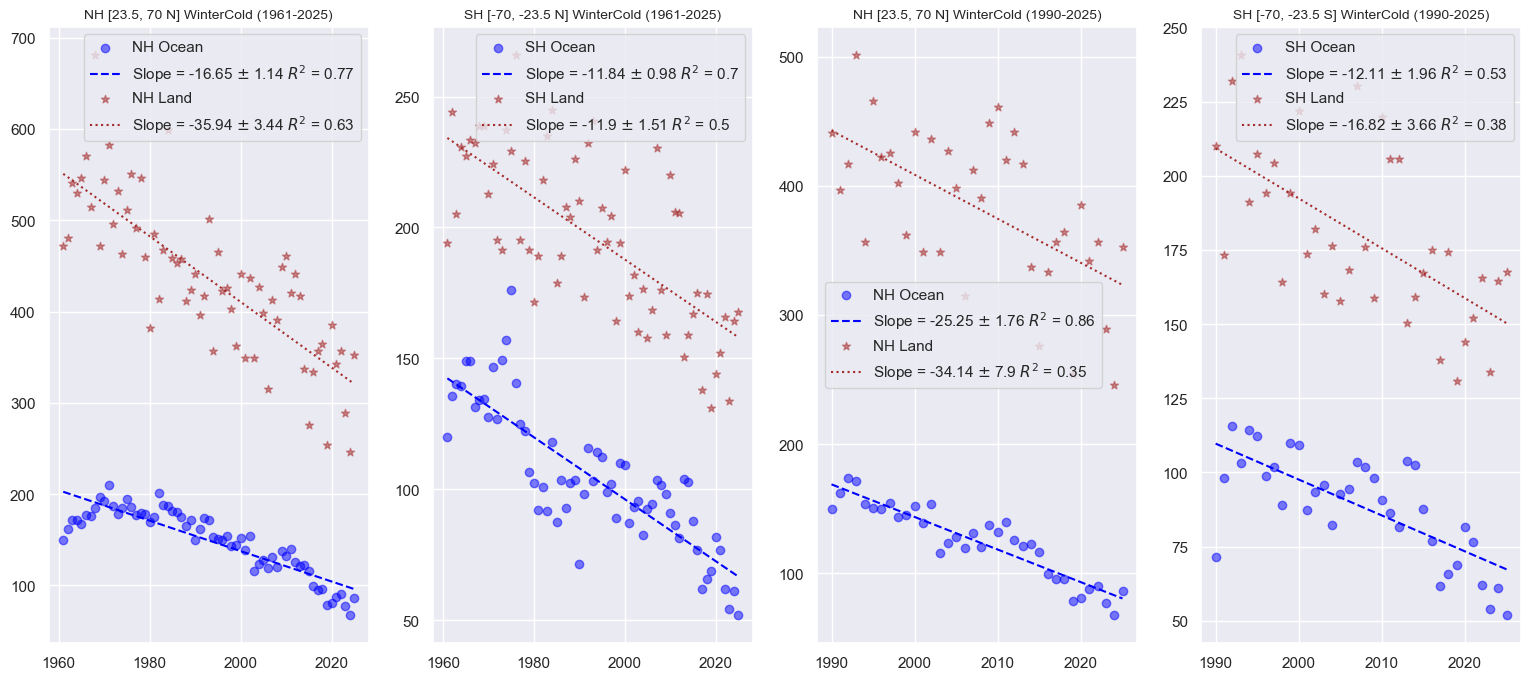

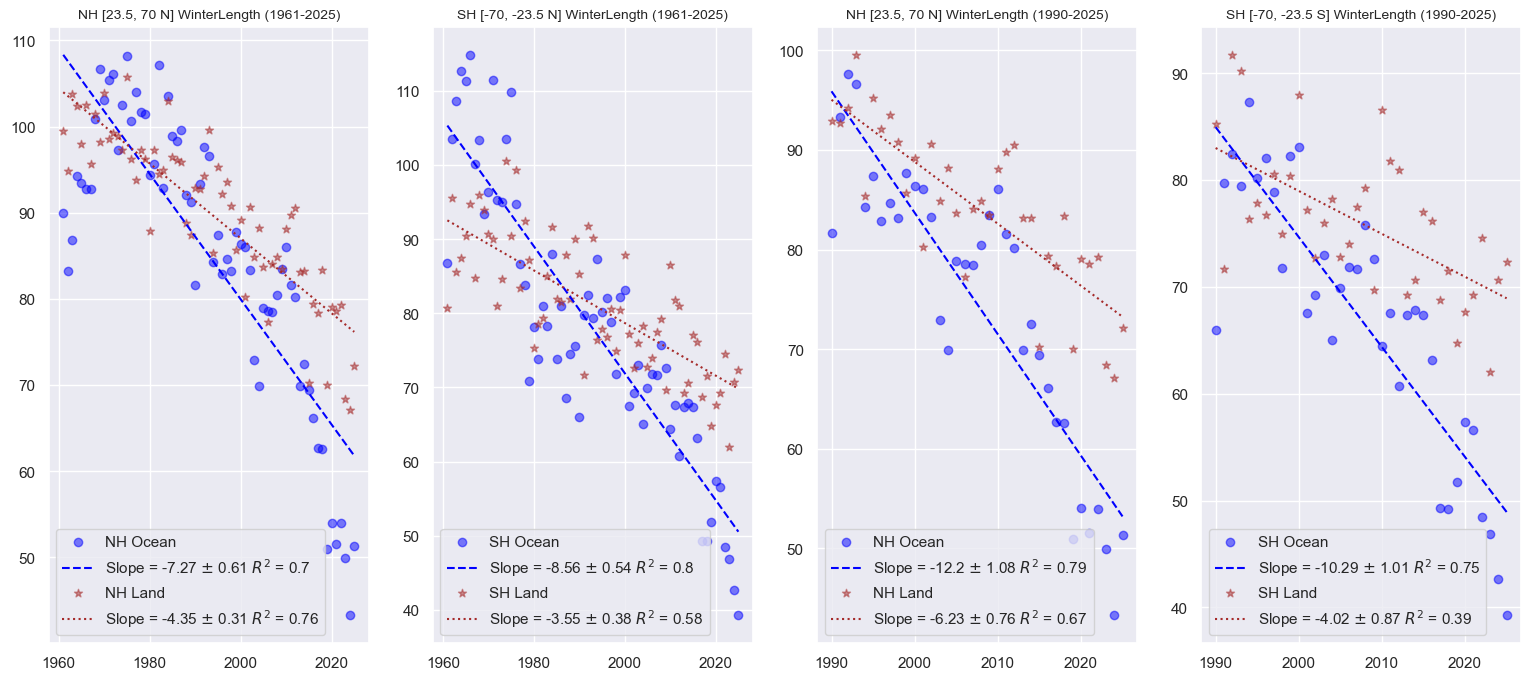

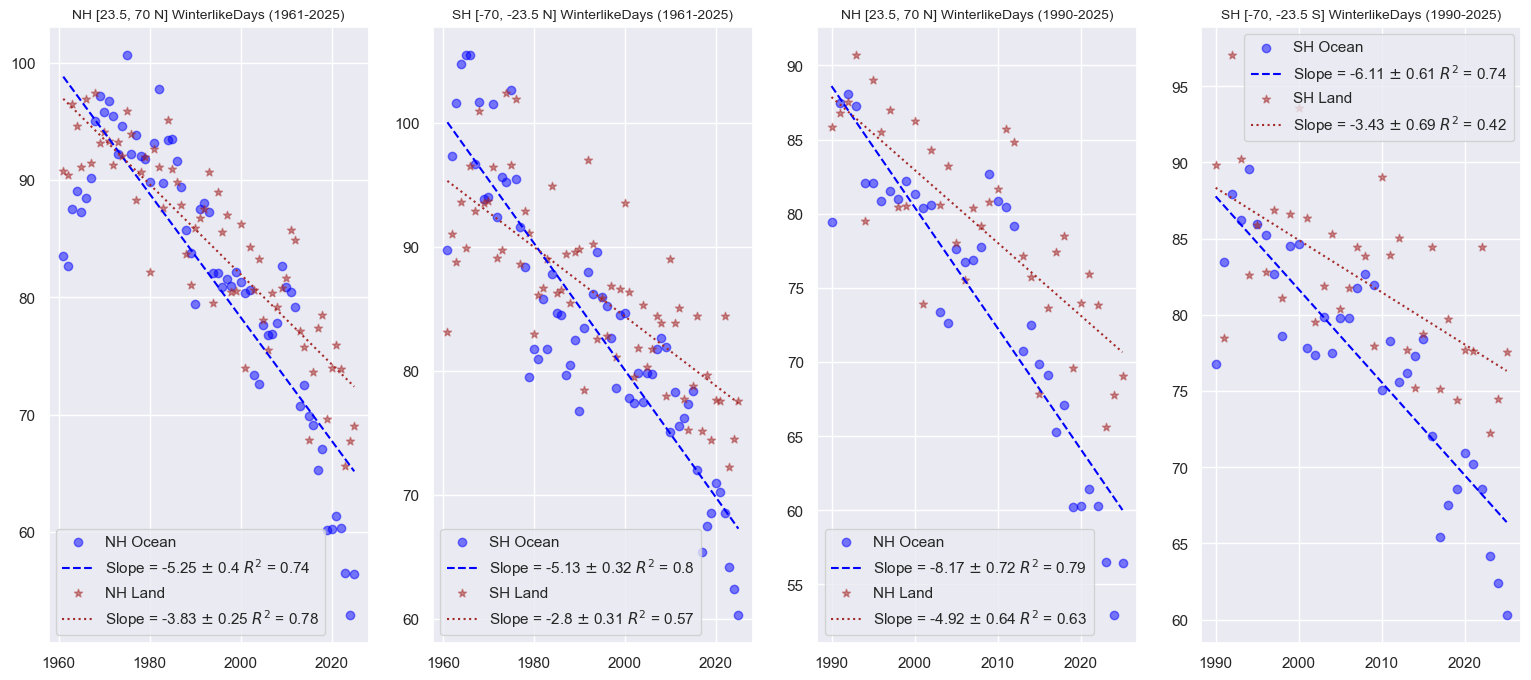

CPU times: user 898 ms, sys: 96.7 ms, total: 995 ms
Wall time: 999 ms


In [79]:
%%time

# takes 30 sec



# loop through all plot variables
for i,v in enumerate(plot_vars):

    # create blank fig
    fig = plt.figure(figsize = (19,8))
    
    # Full Time Period NH
    ax1 = fig.add_subplot(1,4,1)

    # linear fits for slope
    x_land = nh_land_full.time.dt.year.values
    y_land = nh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)


    # linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values
    y_ocean = nh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    # adjusted slopes to be per decade instead of per year
    ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", alpha=0.5)
    ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax1.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax1.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax1.set_title("NH [23.5, 70 N] " + v + " (1961-2025)", fontsize = 10)
    ax1.legend(loc='best')

    # Full time period SH
    ax2 = fig.add_subplot(1,4,2)

    # linear fits for slope
    x_land = sh_land_full.time.dt.year.values
    y_land = sh_land_full[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)


    # linear fits for slope
    x_ocean = sh_ocean_full.time.dt.year.values
    y_ocean = sh_ocean_full[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", alpha=0.5)
    ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax2.scatter(x_land, y_land, label="SH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax2.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax2.set_title("SH [-70, -23.5 N] " + v + " (1961-2025)", fontsize = 10)
    ax2.legend(loc='best')
    

    # Analysis time period NH
    ax3 = fig.add_subplot(1,4,3)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)


    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax3.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", alpha=0.5)
    ax3.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax3.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax3.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax3.set_title("NH [23.5, 70 N] " + v + " (1990-2025)", fontsize = 10)
    ax3.legend(loc='best')


    # Analysis time period SH
    ax4 = fig.add_subplot(1,4,4)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an[v].values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0]*10,2)
    slope_land_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)


    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an[v].values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0]*10,2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0])*10,2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax4.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", alpha=0.5)
    ax4.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))

    ax4.scatter(x_land, y_land, label="SH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax4.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax4.set_title("SH [-70, -23.5 S] " + v + " (1990-2025)", fontsize = 10)
    ax4.legend(loc='best')


#plt.tight_layout()
plt.show()


#plt.tight_layout()
plt.show()

# Plots of counts of cells with Winter Length ZERO over time

In [80]:
nh_no_winter = ds_land.where((ds_land.WinterLength == 0) & (ds.lat >= nh_min) & (ds.lat <= nh_max))
sh_no_winter = ds_land.where((ds_land.WinterLength == 0) & (ds.lat >= sh_max) & (ds.lat <= sh_min))
nh_no_winter, sh_no_winter

(<xarray.Dataset> Size: 5GB
 Dimensions:         (time: 65, lat: 721, lon: 1440)
 Coordinates:
   * time            (time) datetime64[ns] 520B 1961-01-01 ... 2025-01-01
   * lat             (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
   * lon             (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
 Data variables:
     WinterStart     (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterEnd       (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterTmax      (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterCold      (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterLength    (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterlikeDays  (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterRMSE      (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     WinterMeanT     (time, lat, lon) float64 540MB nan nan nan ... nan nan nan
     lsm           

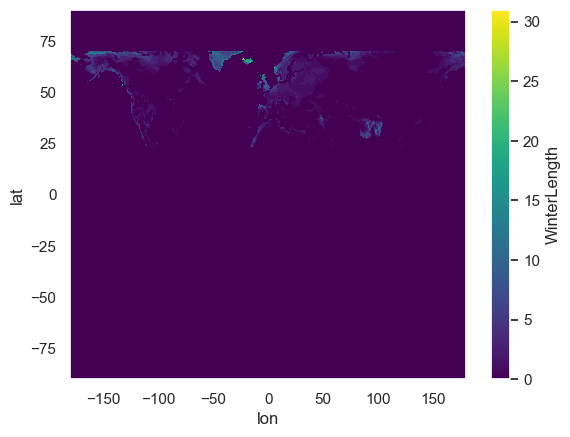

In [81]:
nh_no_winter.WinterLength.count(dim='time').plot()

In [82]:
nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values

array([  202,  1407,     5,   103,   672,   167,   153,  2195,  1282,
          23,    12,   983,   131,   102,    24,  3471,   256,   584,
         902,  1090,   327,  1444,   315,   169,  1148,  1749,   494,
        1197,   462,   687,  3279,   539,   183,  1072,  4406,    51,
        1134,   286,   449,  5180,   613,  3973,  1019,  1133,  3743,
        4334,  4117,  1205,  8206,  1331,  1728,  2342,  5639,  2508,
        6724,  6786,  7966,  1438, 15198,  4327,  1638,  1687,  4410,
        9802,  7019])

In [83]:
nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year

<xarray.DataArray 'year' (time: 65)> Size: 520B
array([1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
Coordinates:
  * time     (time) datetime64[ns] 520B 1961-01-01 1962-01-01 ... 2025-01-01

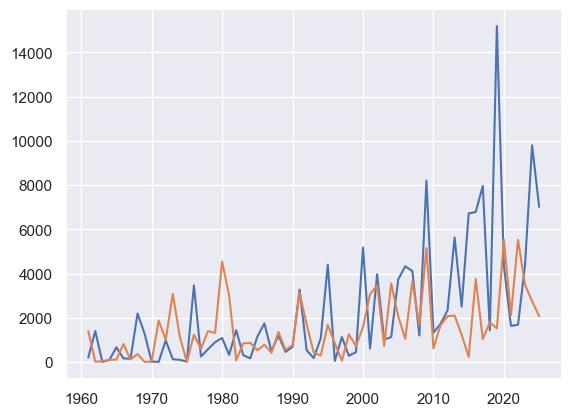

In [84]:
plt.figure()
plt.plot(nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year,
         nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values, label = "NH")
plt.plot(sh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year,
         sh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values, label = "SH")

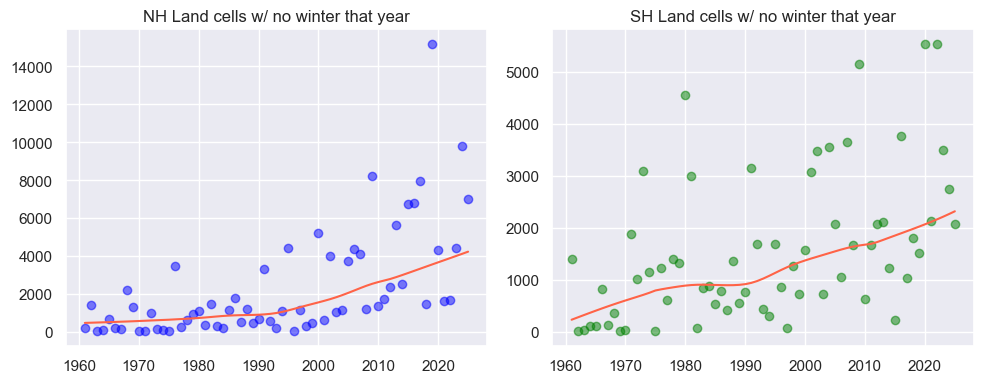

In [85]:
#nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).plot.scatter()

# define x & y for each hemisphere
x1 = nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year
y1 = nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values

x2 = sh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year
y2 = sh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values


# LOWESS SMOOTHING

# parameters
iterations = 10
fraction = 30. / len(x1)

sm_x1, sm_y1 = sm_lowess(y1, x1,  frac=fraction, 
                           it=iterations, return_sorted = True).T

sm_x2, sm_y2 = sm_lowess(y2, x2,  frac=fraction, 
                           it=iterations, return_sorted = True).T


# plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(sm_x1, sm_y1, color='tomato')
plt.scatter(x1, y1, c='blue', alpha=0.5)
plt.title("NH Land cells w/ no winter that year")

plt.subplot(1,2,2)
plt.plot(sm_x2, sm_y2, color='tomato')
plt.scatter(x2, y2, c='green', alpha=0.5)
plt.title("SH Land cells w/ no winter that year")

plt.tight_layout()
plt.show()



### also do % by dividing by ds_land count of cells

In [86]:
nh_land_cells_count = ds_land.WinterLength.where((ds.lat >= nh_min) & (ds.lat <= nh_max)).count(dim=['lat','lon'])
sh_land_cells_count = ds_land.WinterLength.where((ds.lat >= sh_max) & (ds.lat <= sh_min)).count(dim=['lat','lon'])

In [87]:
nh_land_cells_count

<xarray.DataArray 'WinterLength' (time: 65)> Size: 520B
array([141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827, 141827, 141827, 141827, 141827, 141827, 141827, 141827,
       141827])
Coordinates:
  * time     (time) datetime64[ns] 520B 1961-01-01 1962-01-01 ... 2025-01-01

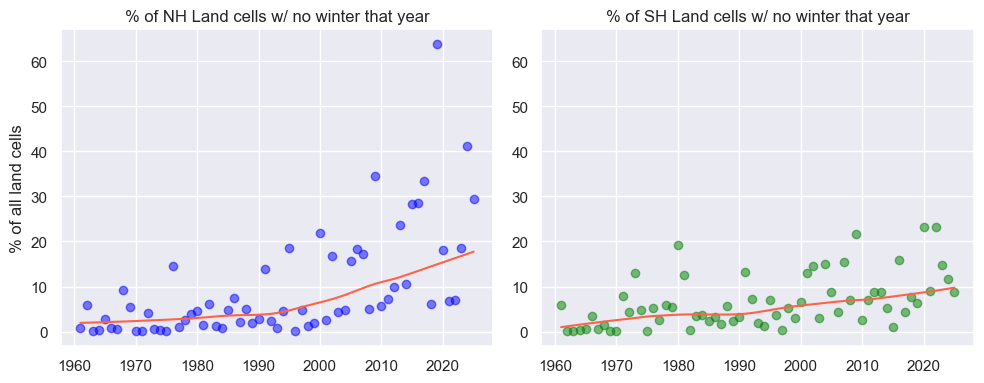

In [88]:
# define x & y for each hemisphere
x1 = nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year.values
y1 = nh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values / sh_land_cells_count * 100

x2 = sh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).time.dt.year.values
y2 = sh_no_winter.WinterLength.groupby('time').count(dim=['lat','lon']).values / sh_land_cells_count * 100


# LOWESS SMOOTHING

# parameters
iterations = 10
fraction = 30. / len(x1)

sm_x1, sm_y1 = sm_lowess(y1, x1,  frac=fraction, 
                           it=iterations, return_sorted = True).T

sm_x2, sm_y2 = sm_lowess(y2, x2,  frac=fraction, 
                           it=iterations, return_sorted = True).T


# plots
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(sm_x1, sm_y1, color='tomato')
ax1.scatter(x1, y1, c='blue', alpha=0.5)
ax1.set_ylabel("% of all land cells")
ax1.set_title("% of NH Land cells w/ no winter that year")

ax2 = fig.add_subplot(1,2,2, sharey=ax1)
ax2.plot(sm_x2, sm_y2, color='tomato')
ax2.scatter(x2, y2, c='green', alpha=0.5)
ax2.set_title("% of SH Land cells w/ no winter that year")

plt.tight_layout()
plt.show()

### with conf bands per https://james-brennan.github.io/posts/lowess_conf/

In [89]:
def smooth(x, y, xgrid, frac, it):
    samples = np.random.choice(len(x), 50, replace=True)
    y_s = y[samples]
    x_s = x[samples]
    y_sm = sm_lowess(y_s,x_s, frac=frac, it=it,
                     return_sorted = False)
    # regularly sample it onto the grid
    y_grid = scipy.interpolate.interp1d(x_s, y_sm, 
                                        fill_value='extrapolate')(xgrid)
    return y_grid

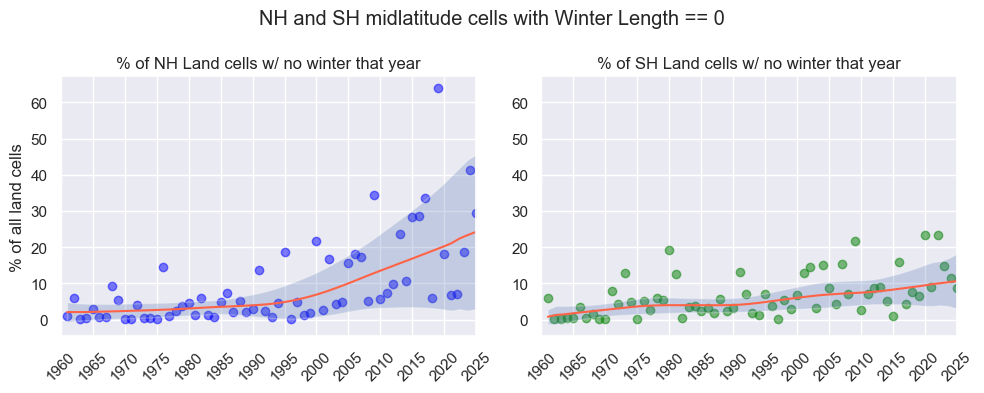

In [90]:
# sm_x1, sm_y1 = sm_lowess(y1, x1,  frac=fraction, 
#                            it=iterations, return_sorted = True).T

# sm_x2, sm_y2 = sm_lowess(y2, x2,  frac=fraction, 
#                            it=iterations, return_sorted = True).T


# plots
fig = plt.figure(figsize=(10,4))
ax1 = fig.add_subplot(1,2,1)
# ax1.plot(sm_x1, sm_y1, color='tomato')
ax1.scatter(x1, y1, c='blue', alpha=0.5)

# lowess and conf int
xgrid1 = np.linspace(x1.min(),x1.max())
K = 100
smooths1 = np.stack([smooth(x1, y1, xgrid1, fraction, iterations) for k in range(K)]).T
mean1 = np.nanmean(smooths1, axis=1)
stderr1 = scipy.stats.sem(smooths1, axis=1)
stderr1 = np.nanstd(smooths1, axis=1, ddof=0)
# plot it
ax1.fill_between(xgrid1, mean1-1.96*stderr1,
                     mean1+1.96*stderr1, alpha=0.25)
ax1.plot(xgrid1, mean1, color='tomato')
# ax1.plot(x1, y1, 'k.')


ax1.set_ylabel("% of all land cells")
ax1.set_xlim(1960,2025)
ax1.set_xticks(np.arange(1960,2030,5))
ax1.tick_params("x", rotation=45)
ax1.set_title("% of NH Land cells w/ no winter that year")

ax2 = fig.add_subplot(1,2,2, sharey=ax1)
#ax2.plot(sm_x2, sm_y2, color='tomato')
ax2.scatter(x2, y2, c='green', alpha=0.5)

# lowess and conf int
xgrid2 = np.linspace(x2.min(),x2.max())
smooths2 = np.stack([smooth(x2, y2, xgrid2, fraction, iterations) for k in range(K)]).T
mean2 = np.nanmean(smooths2, axis=1)
stderr2 = scipy.stats.sem(smooths2, axis=1)
stderr2 = np.nanstd(smooths2, axis=1, ddof=0)
# plot it
ax2.fill_between(xgrid2, mean2-1.96*stderr2,
                     mean2+1.96*stderr2, alpha=0.25)
ax2.plot(xgrid2, mean2, color='tomato')



ax2.set_title("% of SH Land cells w/ no winter that year")
ax2.set_xlim(1960,2025)
ax2.set_xticks(np.arange(1960,2030,5))
ax2.tick_params("x", rotation=45)

plt.suptitle("NH and SH midlatitude cells with Winter Length == 0")
plt.tight_layout()
plt.show()





### Do similar plots but by latitude chunk (zonally) in 10 deg increments?

# ***** HERE ******

In [101]:
nh_land_an

<xarray.Dataset> Size: 3kB
Dimensions:         (time: 36)
Coordinates:
  * time            (time) datetime64[ns] 288B 1990-01-01 ... 2025-01-01
Data variables:
    WinterStart     (time) float64 288B 153.0 150.5 149.0 ... 164.5 167.5 162.4
    WinterEnd       (time) float64 288B 244.8 242.2 242.3 ... 231.9 233.6 233.6
    WinterTmax      (time) float64 288B 197.9 193.7 205.3 ... 197.8 202.4 196.8
    WinterCold      (time) float64 288B 441.0 396.6 416.9 ... 288.9 246.0 352.8
    WinterLength    (time) float64 288B 92.87 92.7 94.23 ... 68.41 67.11 72.15
    WinterlikeDays  (time) float64 288B 85.88 86.77 87.55 ... 65.59 67.75 69.08
    WinterRMSE      (time) float64 288B 3.909 3.811 3.887 ... 3.912 3.718 3.835
    WinterMeanT     (time) float64 288B 264.9 261.4 265.5 ... 258.2 253.7 253.0
    lsm             (time) float64 288B 0.9671 0.9671 0.9671 ... 0.9671 0.9671
    Coastal         (time) float64 288B 0.02822 0.02822 ... 0.02822 0.02822

# Acceleration Checks

### LOWESS Smoothing of Length to check for acceleration following Rahmsdorf & Foster (2025) https://doi.org/10.21203/rs.3.rs-6079807/v1

#### Analysis Land

Text(0.5, 1.0, 'Residual between data and LOWESS')

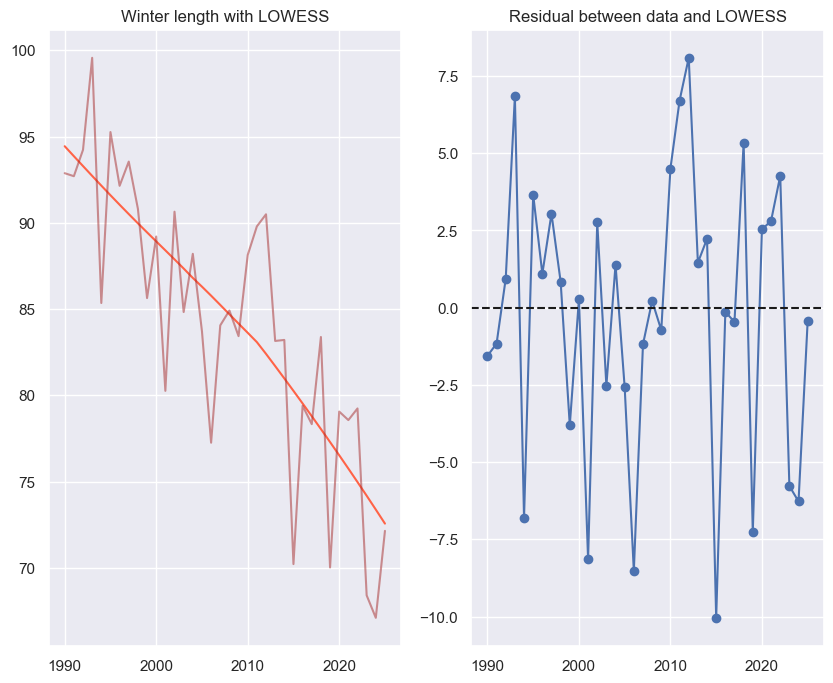

In [102]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_an.time.dt.year.values
y = nh_land_an.WinterLength.values

# LOWESS SMOOTHING

# parameters
iterations = 10
fraction = 30. / len(x)

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='brown', alpha=0.5)
plt.title("Winter length with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

#### Analysis Ocean

Text(0.5, 1.0, 'Residual between data and LOWESS')

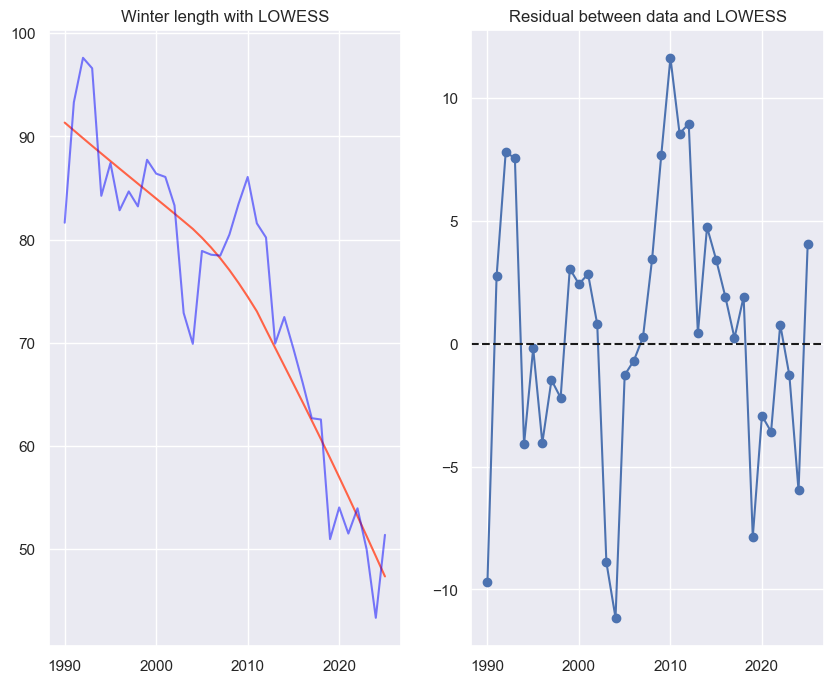

In [103]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_an.time.dt.year.values
y = nh_ocean_an.WinterLength.values

# LOWESS SMOOTHING

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='blue', alpha=0.5)
plt.title("Winter length with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

#### Full Land

Text(0.5, 1.0, 'Residual between data and LOWESS')

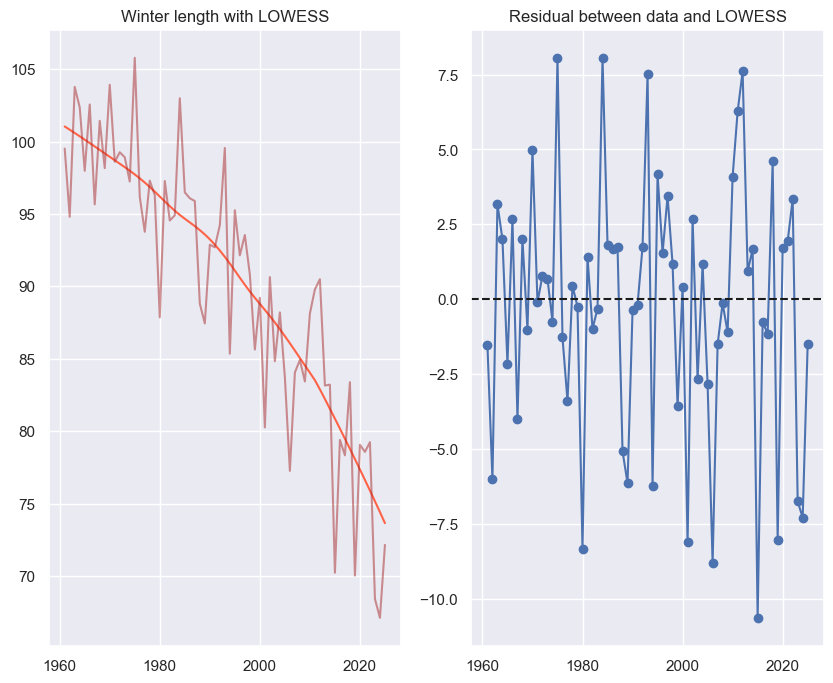

In [104]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_full.time.dt.year.values
y = nh_land_full.WinterLength.values

# LOWESS SMOOTHING

# parameters
iterations = 10
fraction = 30. / len(x)

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='brown', alpha=0.5)
plt.title("Winter length with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

#### Full Ocean

Text(0.5, 1.0, 'Residual between data and LOWESS')

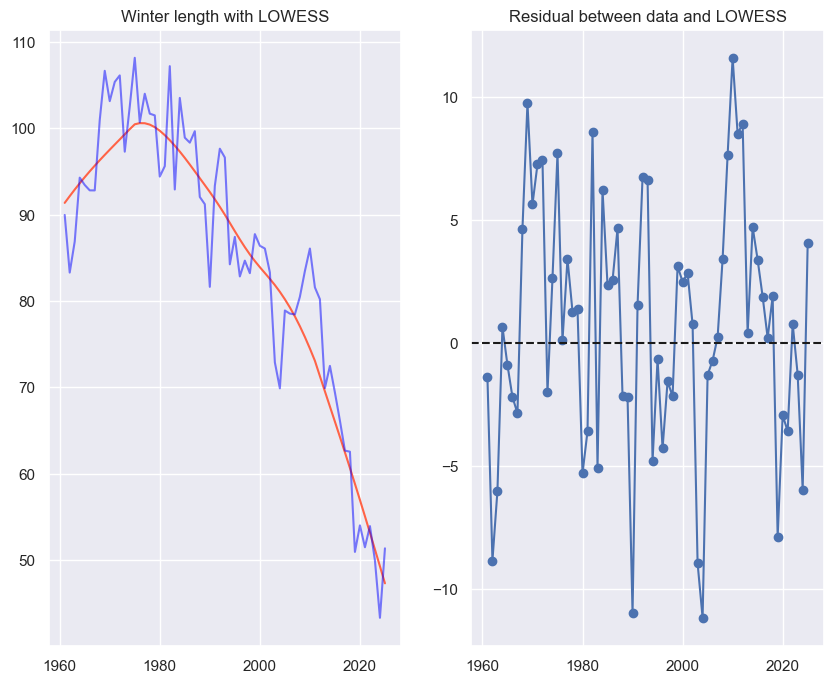

In [105]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_full.time.dt.year.values
y = nh_ocean_full.WinterLength.values

# LOWESS SMOOTHING

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='blue', alpha=0.5)
plt.title("Winter length with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

### LOWESS Smoothing of Accumulated Cold to check for acceleration following Rahmsdorf & Foster (2025) https://doi.org/10.21203/rs.3.rs-6079807/v1

#### Analysis Land

Text(0.5, 1.0, 'Residual between data and LOWESS')

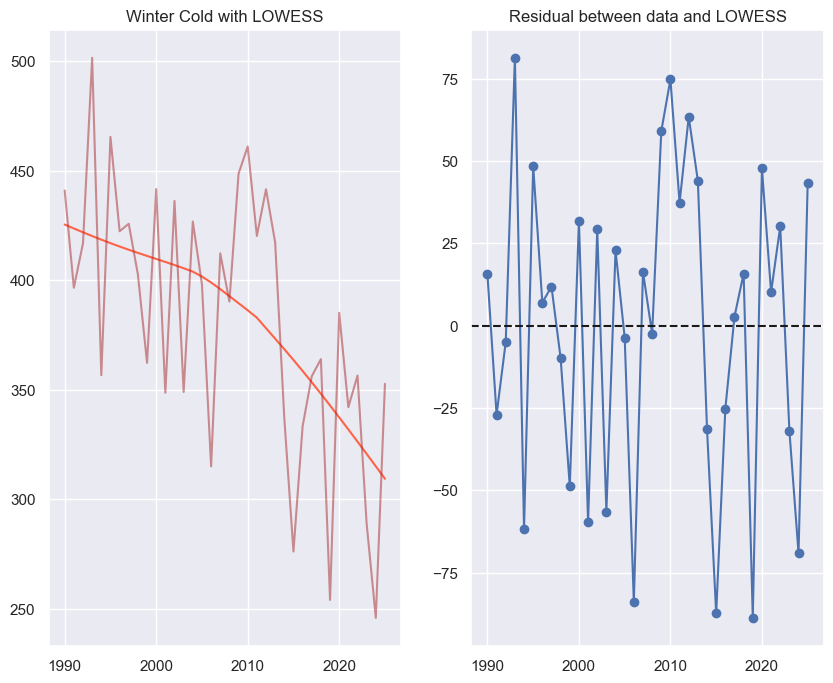

In [106]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_an.time.dt.year.values
y = nh_land_an.WinterCold.values

# LOWESS SMOOTHING

# parameters
iterations = 10
fraction = 30. / len(x)

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='brown', alpha=0.5)
plt.title("Winter Cold with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

#### Analysis Ocean

Text(0.5, 1.0, 'Residual between data and LOWESS')

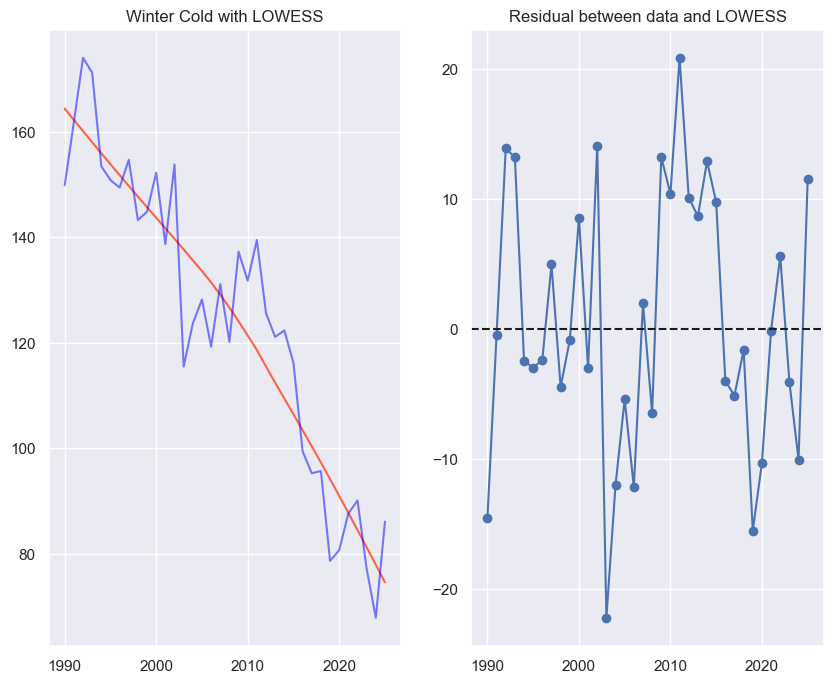

In [107]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_an.time.dt.year.values
y = nh_ocean_an.WinterCold.values

# LOWESS SMOOTHING

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='blue', alpha=0.5)
plt.title("Winter Cold with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

#### Full Land

Text(0.5, 1.0, 'Residual between data and LOWESS')

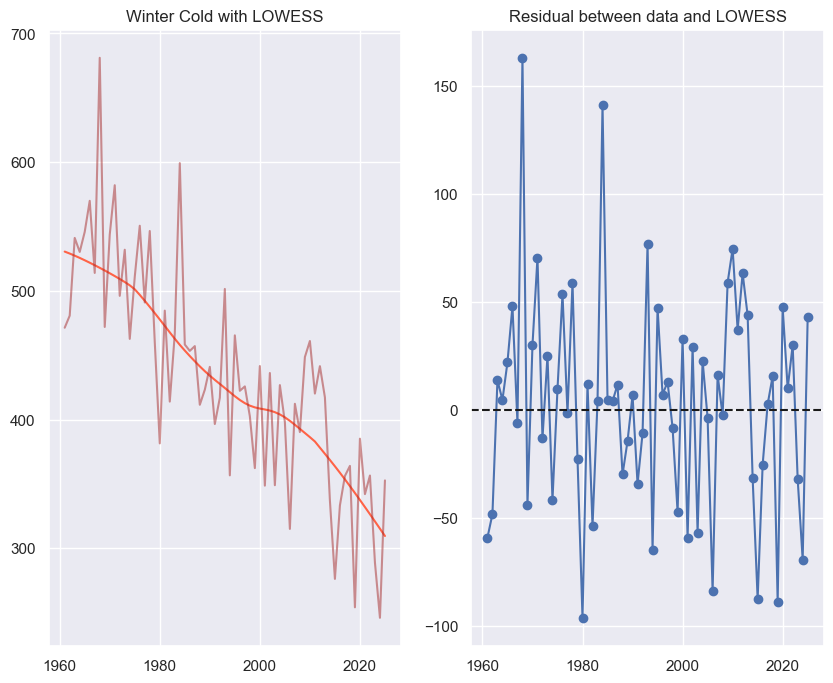

In [108]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_full.time.dt.year.values
y = nh_land_full.WinterCold.values

# LOWESS SMOOTHING

# parameters
iterations = 10
fraction = 30. / len(x)

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='brown', alpha=0.5)
plt.title("Winter Cold with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

#### Full Ocean

Text(0.5, 1.0, 'Residual between data and LOWESS')

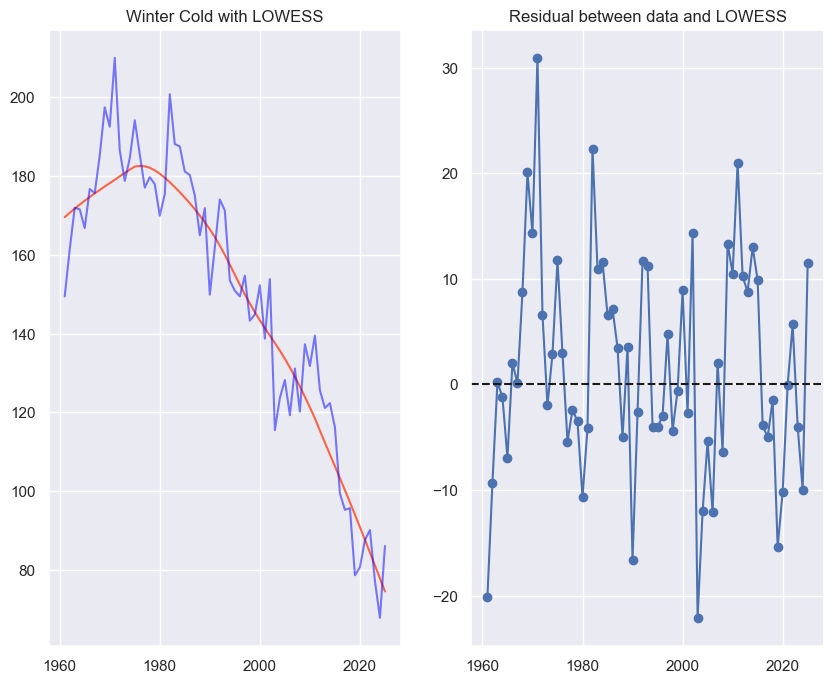

In [109]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_full.time.dt.year.values
y = nh_ocean_full.WinterCold.values

# LOWESS SMOOTHING

sm_x, sm_y = sm_lowess(y, x,  frac=fraction, 
                           it=iterations, return_sorted = True).T
plt.figure(figsize=(10,8))
plt.subplot(1,2,1)
plt.plot(sm_x, sm_y, color='tomato')
plt.plot(x, y, c='blue', alpha=0.5)
plt.title("Winter Cold with LOWESS")

plt.subplot(1,2,2)
plt.plot(sm_x, y - sm_y, 'b')
plt.scatter(sm_x, y-sm_y)
plt.axhline(color='k', linestyle="--")
plt.title("Residual between data and LOWESS")

## Instead try Piecewise Linear Fits - helpful example paper: https://journals.ametsoc.org/view/journals/wcas/17/2/WCAS-D-24-0057.1.xml

#### Package info and helpful pages: 
- https://pypi.org/project/pwlf/
- https://jekel.me/piecewise_linear_fit_py/how_it_works.html
- https://jekel.me/2017/Fit-a-piecewise-linear-function-to-data/


## ** NORTHERN ** Winter Length

### Full Land 

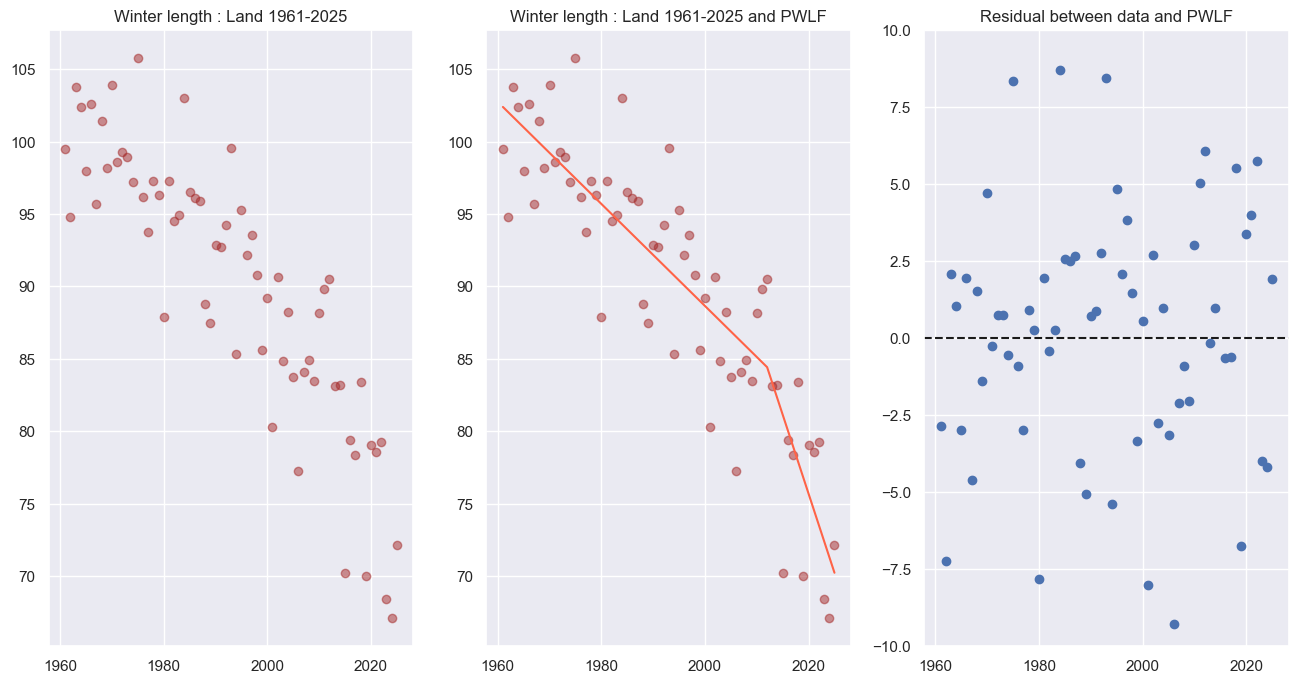

In [114]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = nh_land_full.time.dt.year.values
y = nh_land_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Land 1961-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [111]:
my_pwlf.calc_slopes()

array([-0.35239734, -1.09207005])

In [115]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.35239734, -1.09207006]),
 array([1961.        , 2011.99999999, 2025.        ]),
 np.float64(0.8011257543509822))

#### Two segments fits Land well, CP at 2011, and residuals are mostly centered around zero 

### Analysis Land

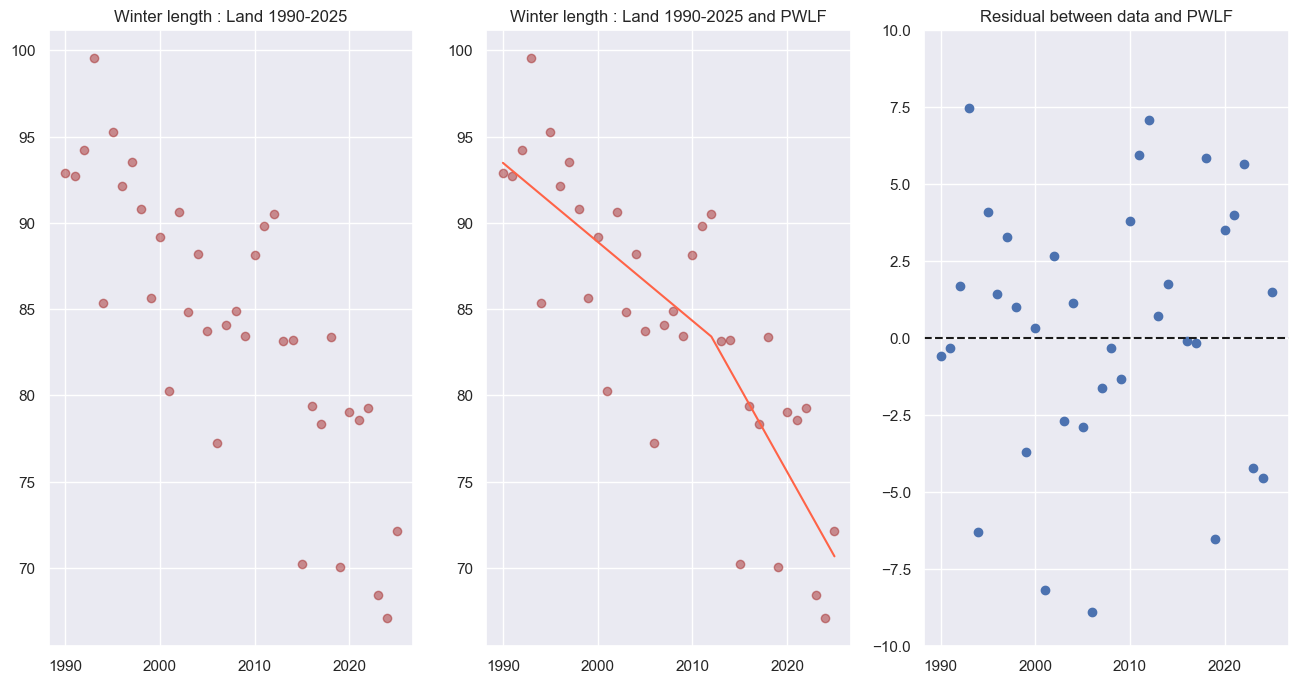

In [116]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = nh_land_an.time.dt.year.values
y = nh_land_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : Land 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Land 1990-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [117]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.45750872, -0.97976947]),
 array([1990., 2012., 2025.]),
 np.float64(0.6894967082868761))

#### **** try just one line instead

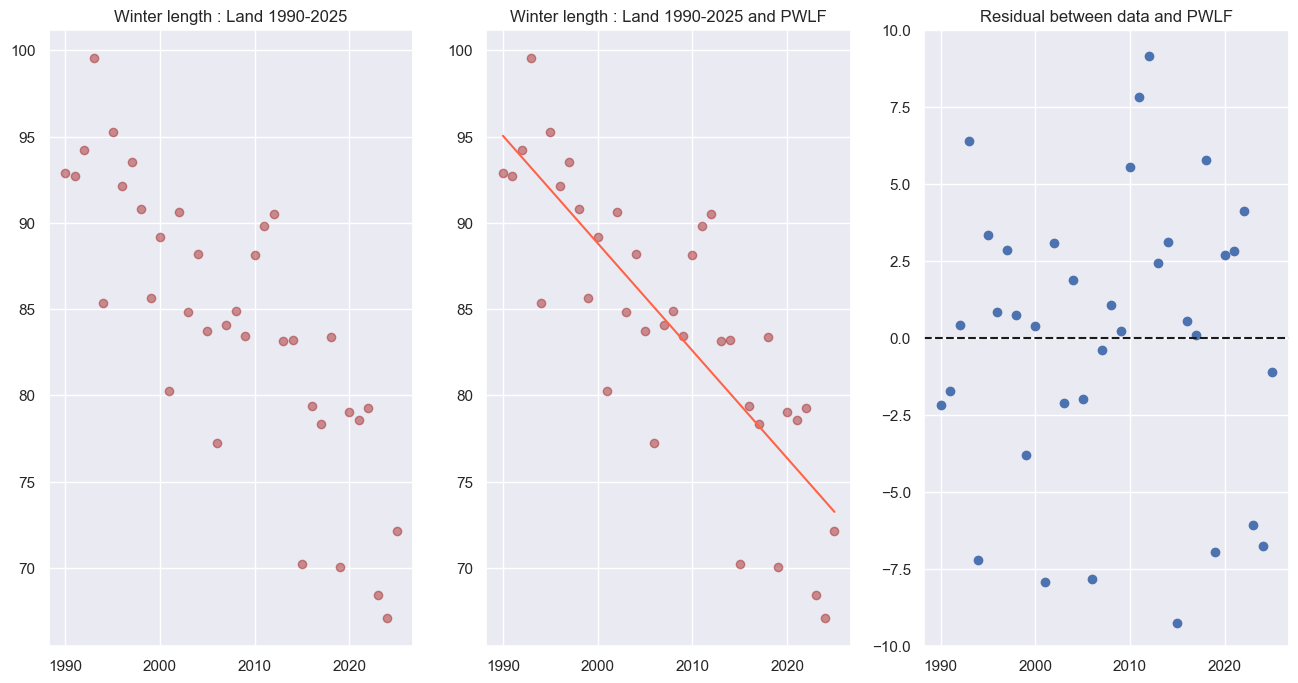

In [118]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = nh_land_an.time.dt.year.values
y = nh_land_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(1)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : Land 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Land 1990-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [119]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.62265604]), array([1990, 2025]), np.float64(0.6653395212051558))

#### Two segments for Analysis period Land yields a slightly better fit 

### Full Ocean 

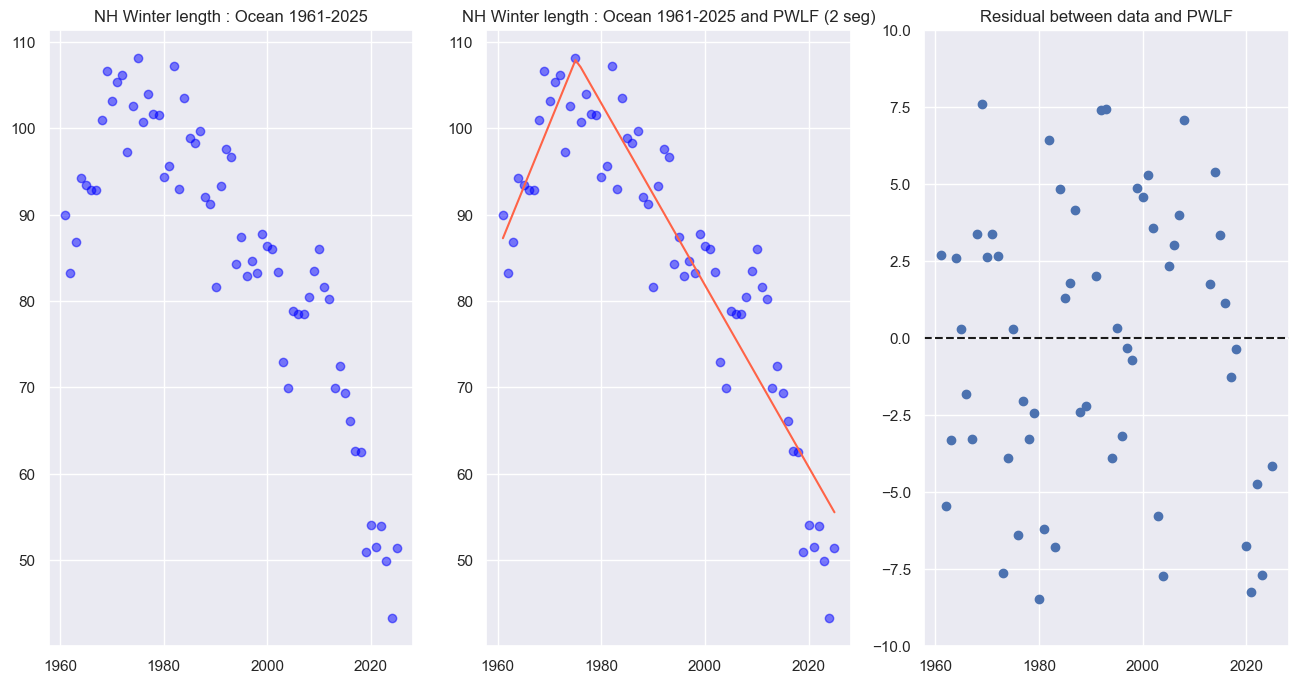

In [120]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_full.time.dt.year.values
y = nh_ocean_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("NH Winter length : Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("NH Winter length : Ocean 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [121]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([ 1.47295903, -1.05208738]),
 array([1961.       , 1975.0987746, 2025.       ]),
 np.float64(0.8729340538224363))

#### MSR and $R^{2}$

In [122]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(34.00914692953221), np.float64(0.8729340538224363))

#### Two segments for Ocean

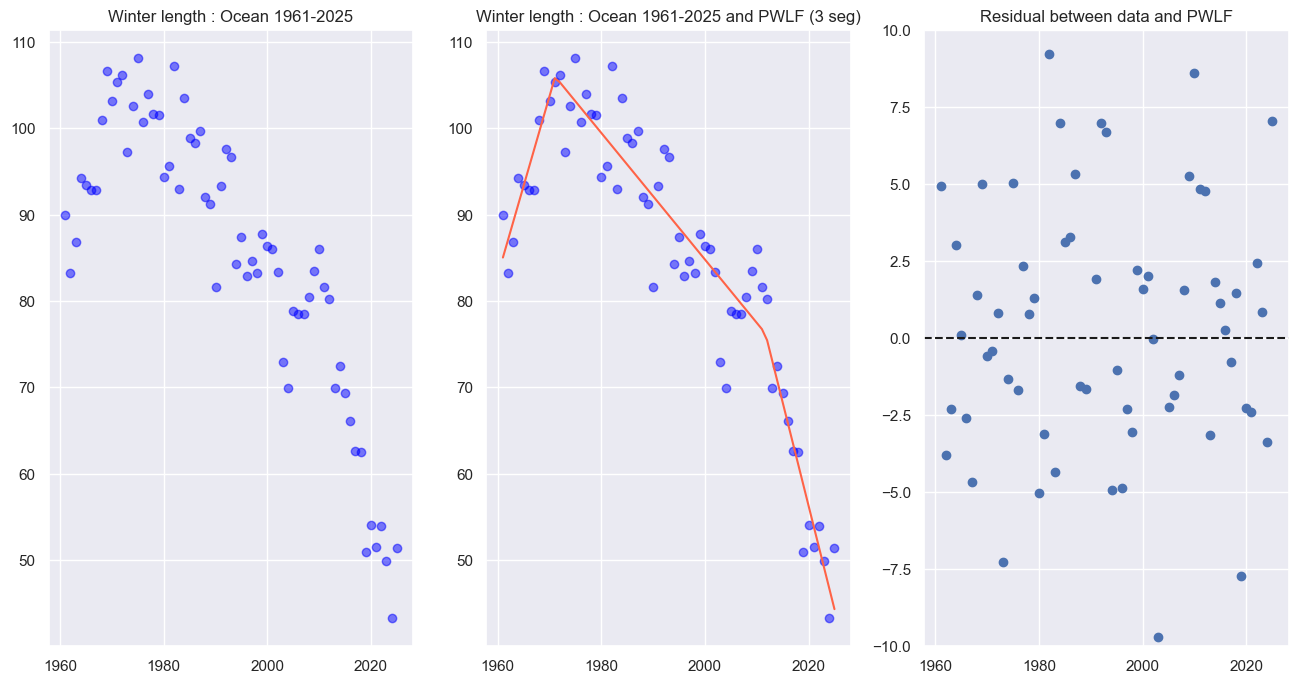

In [123]:



# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_full.time.dt.year.values
y = nh_ocean_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for three line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(3)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Ocean 1961-2025 and PWLF (3 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [124]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([ 2.07629712, -0.7327523 , -2.39452459]),
 array([1961.        , 1971.09024722, 2011.66434538, 2025.        ]),
 np.float64(0.9264611986135841))

#### MSR and $R^{2}$

In [125]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(19.682629190651802), np.float64(0.9264611986135841))

#### Three segments for Ocean yields better residual plot and $R^2$ 

### Try fixed changepoints ala Rahmstorf?

In [142]:


# # define x & y using NH Ocean from 1990-2025 as example
# x = nh_ocean_full.time.dt.year.values
# y = nh_ocean_full.SummerLength.values

# # number of segments - can also determine this algorithmically via link above
# my_pwlf = pwlf.PiecewiseLinFit(x, y)

# # your desired line segment end locations
# x0 = np.array([min(x), 1982, 2015, max(x)])

# # fit the data for three line segments - it looks like either 2 or 3 to me
# res = my_pwlf.fit_with_breaks(x0)

# # predict for the determined points
# xHat = np.linspace(min(x), max(x), num=len(y))
# yHat = my_pwlf.predict(xHat)

# # plot the results
# plt.figure(figsize=(16,8))
# plt.subplot(1,3,1)
# plt.plot(x, y, 'o',c='blue', alpha=0.5)
# plt.title("NH Summer length : Ocean 1961-2025")

# plt.subplot(1,3,2)
# plt.plot(x, y, 'o', c='blue', alpha=0.5)
# plt.plot(xHat, yHat, '-', c='tomato')
# plt.title("NH Summer length : Ocean 1961-2025 and PWLF (3 seg)")

# plt.subplot(1,3,3)
# #plt.plot(x, y - yHat, 'b')
# plt.scatter(x, y - yHat)
# plt.axhline(color='k', linestyle="--")
# plt.ylim(-10,10)
# plt.title("Residual between data and PWLF")


# plt.show()

In [191]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.20551406,  0.69984574,  1.26455451]),
 array([1961, 1982, 2015, 2023]),
 np.float64(0.8654574788389835))

#### MSR and $R^{2}$

In [192]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(14.408336042598243), np.float64(0.8654574788389835))

### Analysis Ocean 

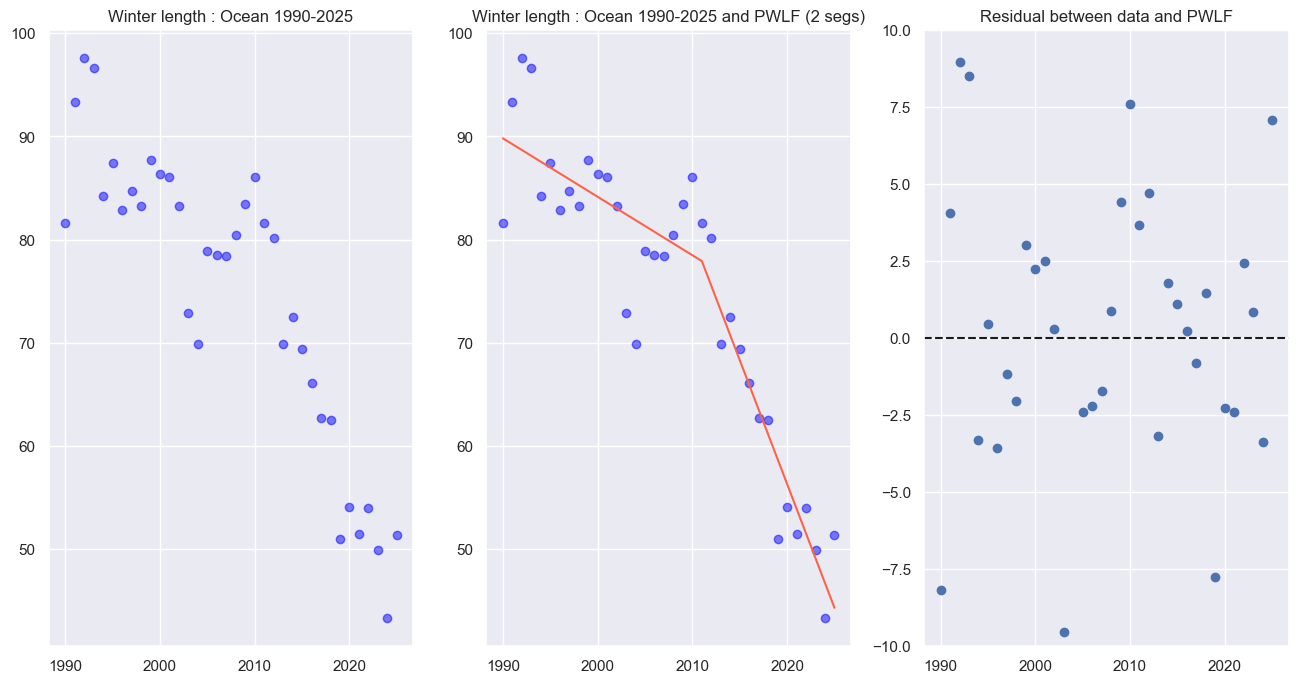

In [126]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = nh_ocean_an.time.dt.year.values
y = nh_ocean_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : Ocean 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Ocean 1990-2025 and PWLF (2 segs)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [127]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.5669077 , -2.40220936]),
 array([1990.        , 2011.00000002, 2025.        ]),
 np.float64(0.8900290857830365))

#### **** Compare with one line instead

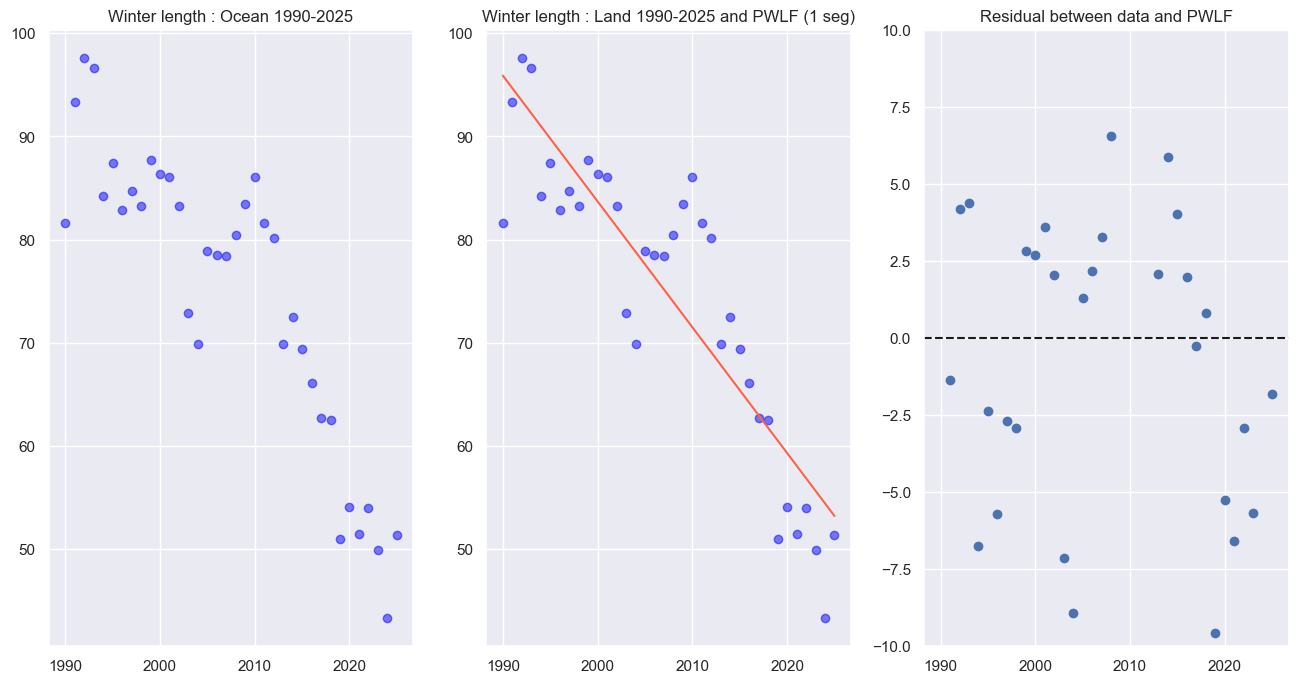

In [128]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = nh_ocean_an.time.dt.year.values
y = nh_ocean_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(1)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : Ocean 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Land 1990-2025 and PWLF (1 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [129]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-1.22001055]), array([1990, 2025]), np.float64(0.7902419473865764))

#### one segment is a poor fit - residuals shows structure so two segments is best

#### Two segments for Analysis period Ocean yields a better fit (residuals and $R^2$ and a much steeper slope (-2.4 $\frac{days}{year}$) since ~2010 years - *indicates acceleration*

## ** NORTHERN ** Winter Cold PWLF

### Full Land (no accel)

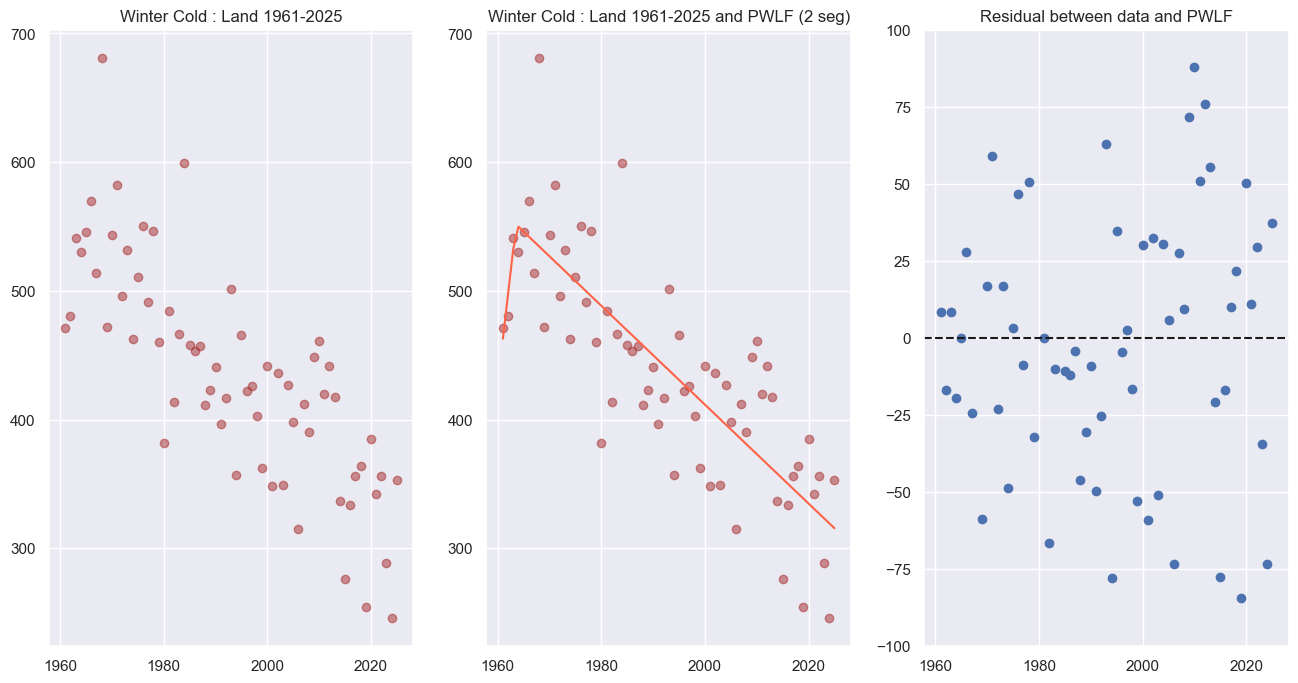

In [131]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_full.time.dt.year.values
y = nh_land_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter Cold : Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : Land 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'o', 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()

In [132]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([34.88958847, -3.84059209]),
 array([1961.        , 1963.54332443, 2025.        ]),
 np.float64(0.660112307127261))

#### Two segments fits Land well and residuals are mostly cenetered around zero with only the 1992 (?) outlier

#### CP at 2010 results

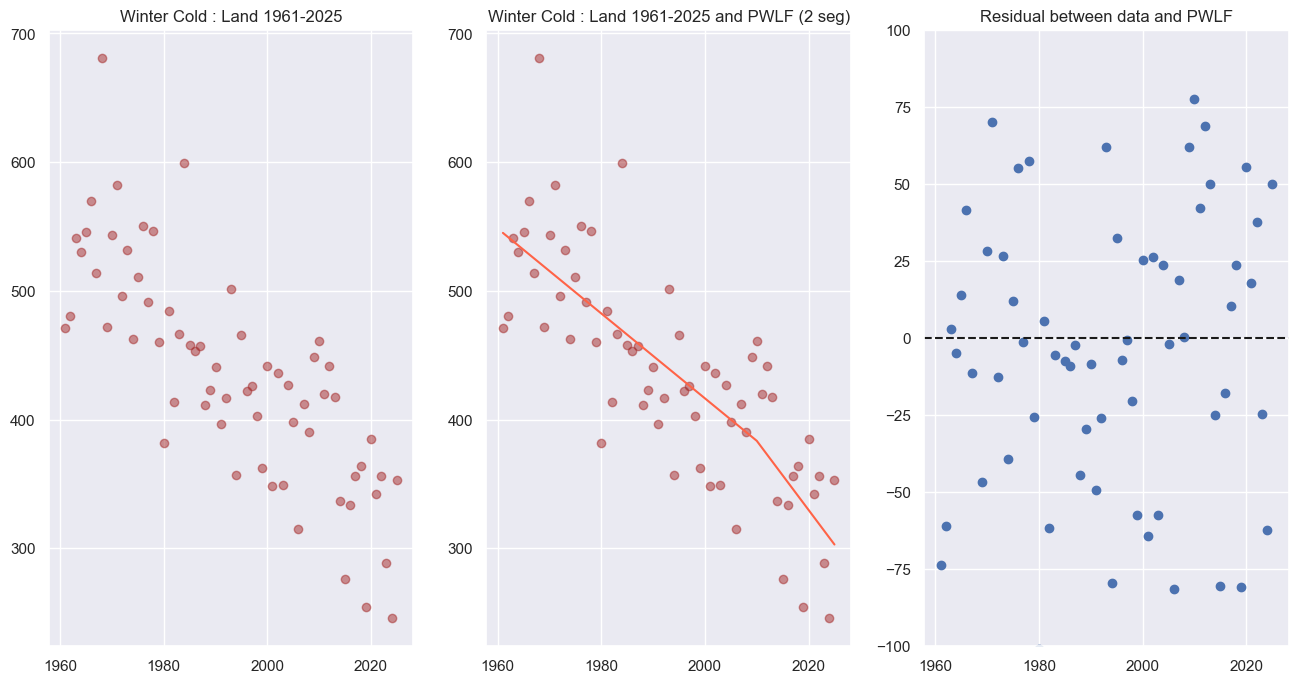

In [133]:
# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_full.time.dt.year.values
y = nh_land_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# your desired line segment end locations
x0 = np.array([min(x), 2010, max(x)])

# fit the data for three line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit_with_breaks(x0)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments


# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter Cold : Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : Land 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'o', 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()



In [134]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-3.29691888, -5.37096517]),
 array([1961, 2010, 2025]),
 np.float64(0.6397622625085045))

#### MSR and $R^{2}$

In [135]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(2580.9559553277554), np.float64(0.6397622625085045))

#### Only one segment for residual comparison

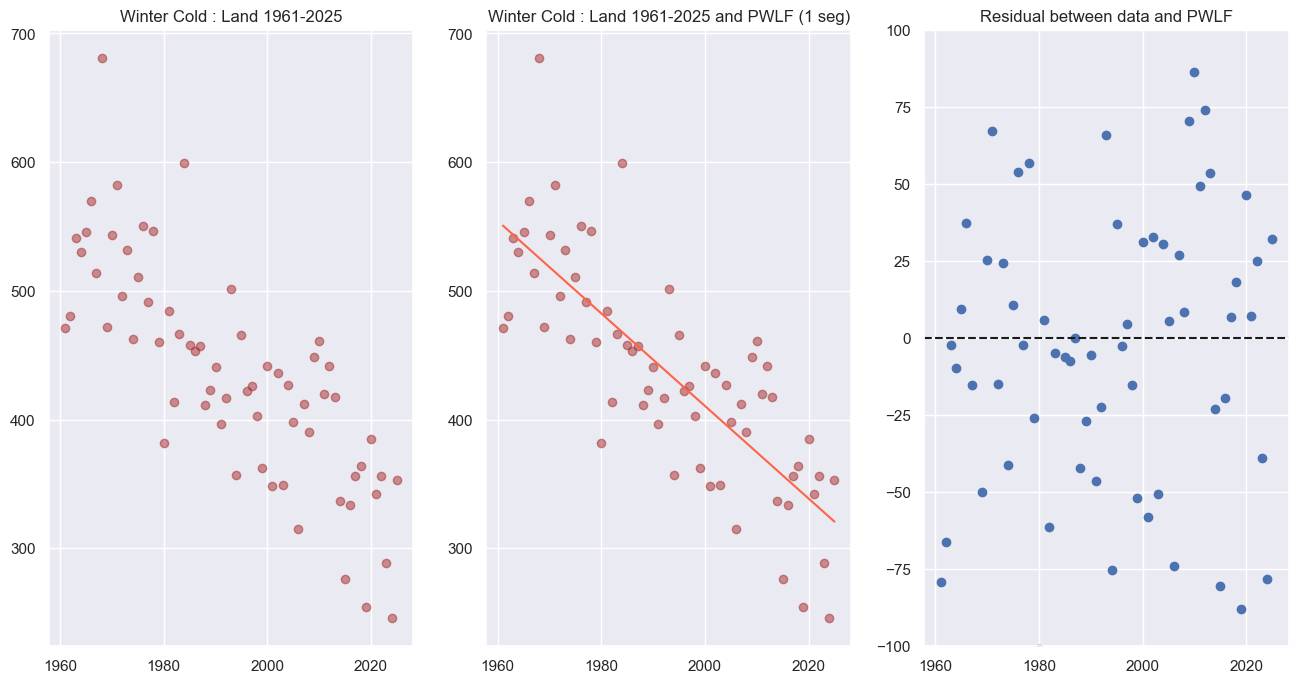

In [136]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y using NH Ocean from 1990-2025 as example
x = nh_land_full.time.dt.year.values
y = nh_land_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(1)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter Cold : Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : Land 1961-2025 and PWLF (1 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'o', 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()

In [137]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-3.5942472]), array([1961, 2025]), np.float64(0.6346980470923114))

#### MSR and $R^{2}$

In [138]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(2617.2389861631764), np.float64(0.6346980470923114))

### Not clear that two segments are needed for Winter Cold in NH

### Full Ocean 

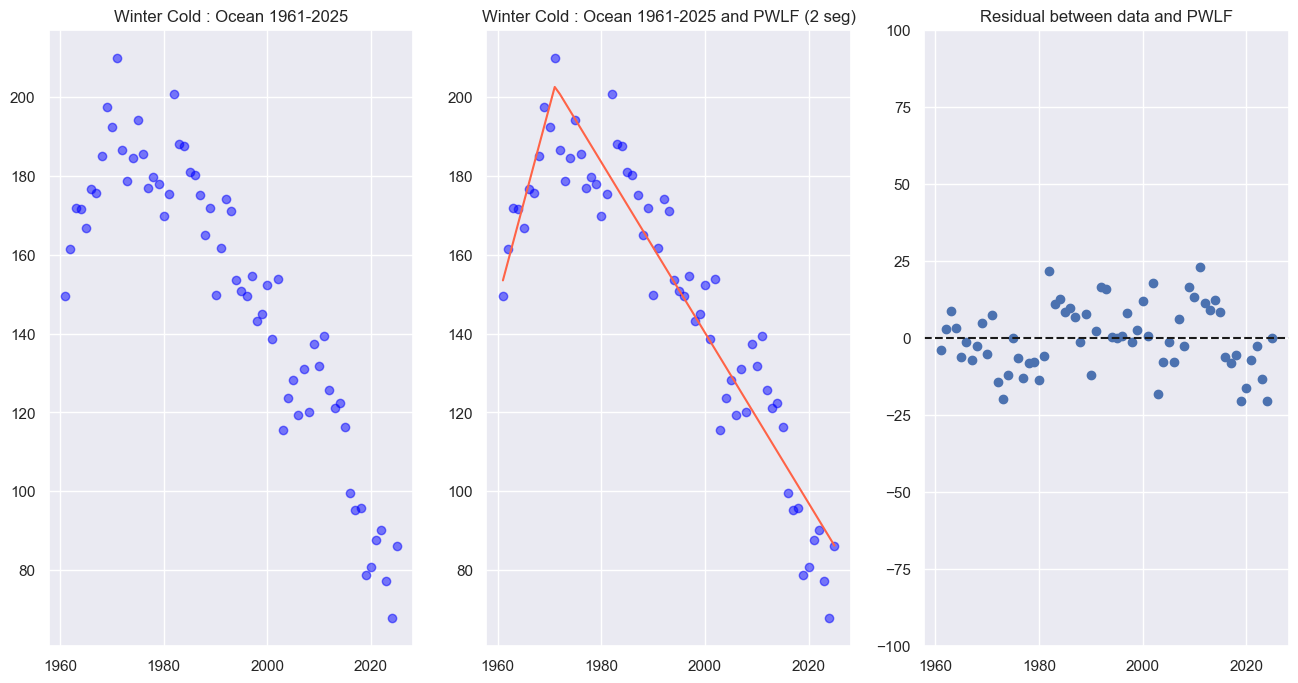

In [139]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using NH Ocean from 1990-2025 as example
x = nh_ocean_full.time.dt.year.values
y = nh_ocean_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter Cold : Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : Ocean 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()

In [140]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([ 4.90927073, -2.16202016]),
 array([1961.        , 1971.04874307, 2025.        ]),
 np.float64(0.9118478044565264))

#### MSR and $R^{2}$

In [141]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(111.37530105765265), np.float64(0.9118478044565264))

## **** General Conclusions for NH:
- Evidence of acceleration in Winter Length Land and Ocean with CP ~2010 for 1961-2025 and 1990-2025
- Insufficent evidence of acceleration in Winter Cold for either time period


## ** SOUTHERN ** Winter Length

### Full Land 

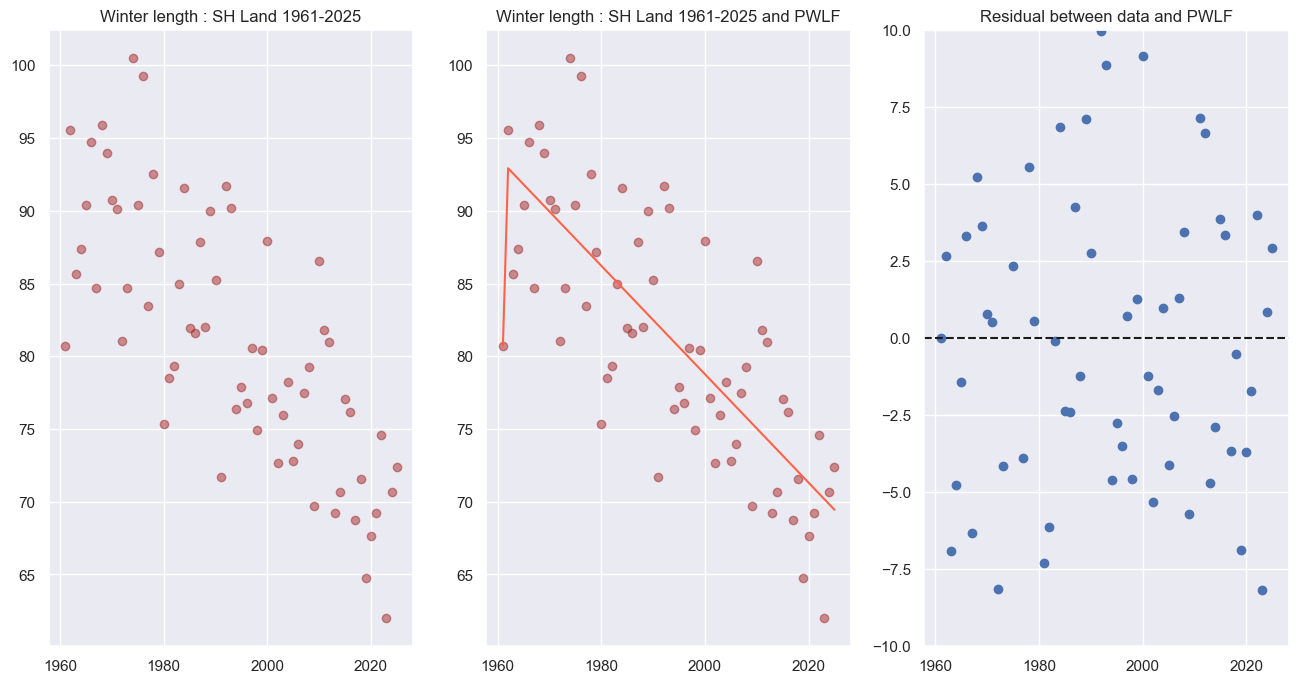

In [144]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = sh_land_full.time.dt.year.values
y = sh_land_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : SH Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Land 1961-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [145]:
my_pwlf.calc_slopes()

array([ 1.76163792e+04, -3.72595177e-01])

In [146]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([ 1.76163792e+04, -3.72595177e-01]),
 array([1961.        , 1961.00071389, 2025.        ]),
 np.float64(0.6114899847785619))

#### One segment only?

#### Try with CP at 2010

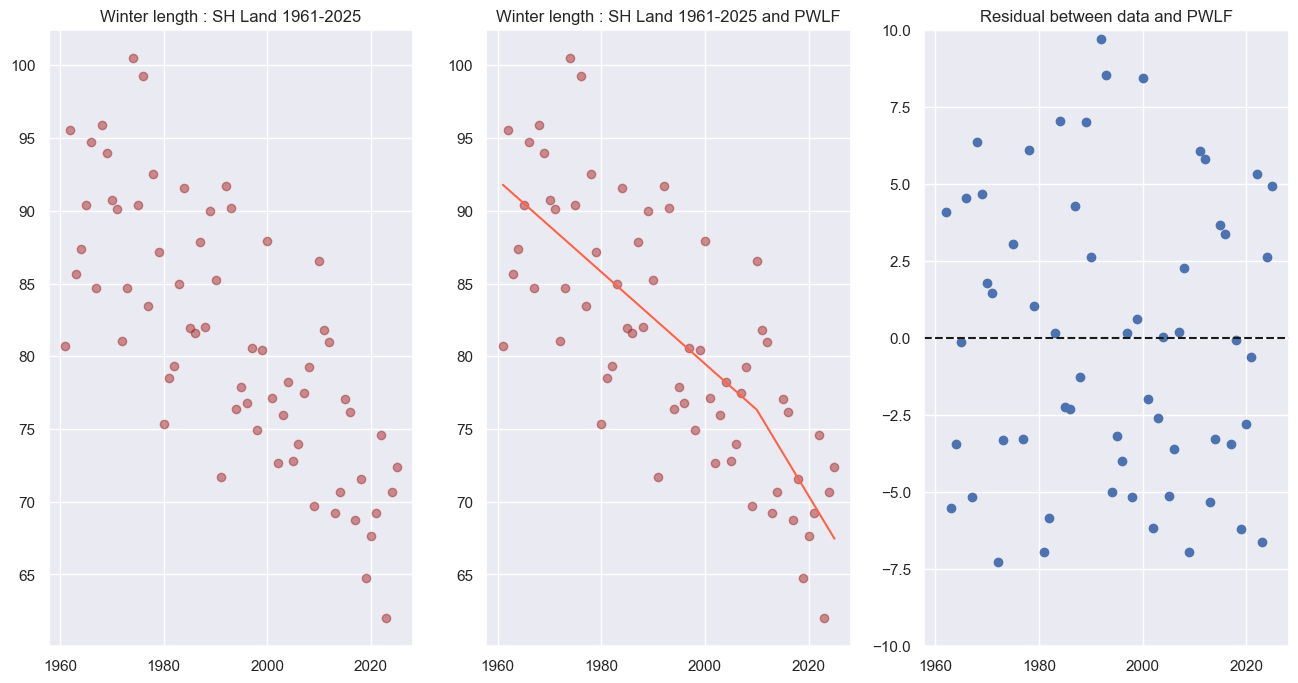

In [151]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = sh_land_full.time.dt.year.values
y = sh_land_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# your desired line segment end locations
x0 = np.array([min(x), 2010, max(x)])

# fit the data for three line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit_with_breaks(x0)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : SH Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Land 1961-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()






In [152]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.31550615, -0.59104005]),
 array([1961, 2010, 2025]),
 np.float64(0.5899053837402518))

#### Improved with CP at 2010

### Analysis Land

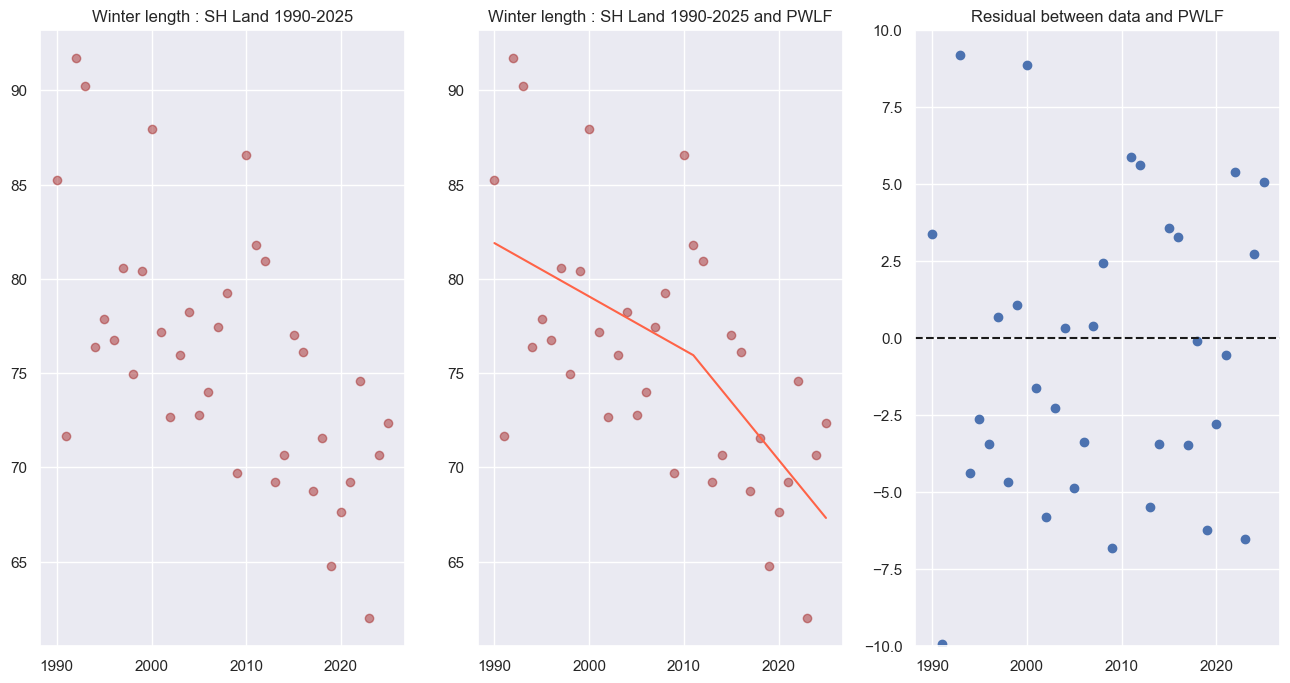

In [147]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = sh_land_an.time.dt.year.values
y = sh_land_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : SH Land 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Land 1990-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [148]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.28318265, -0.61643238]),
 array([1990.        , 2011.00000001, 2025.        ]),
 np.float64(0.40084507503928235))

#### **** try just one line instead

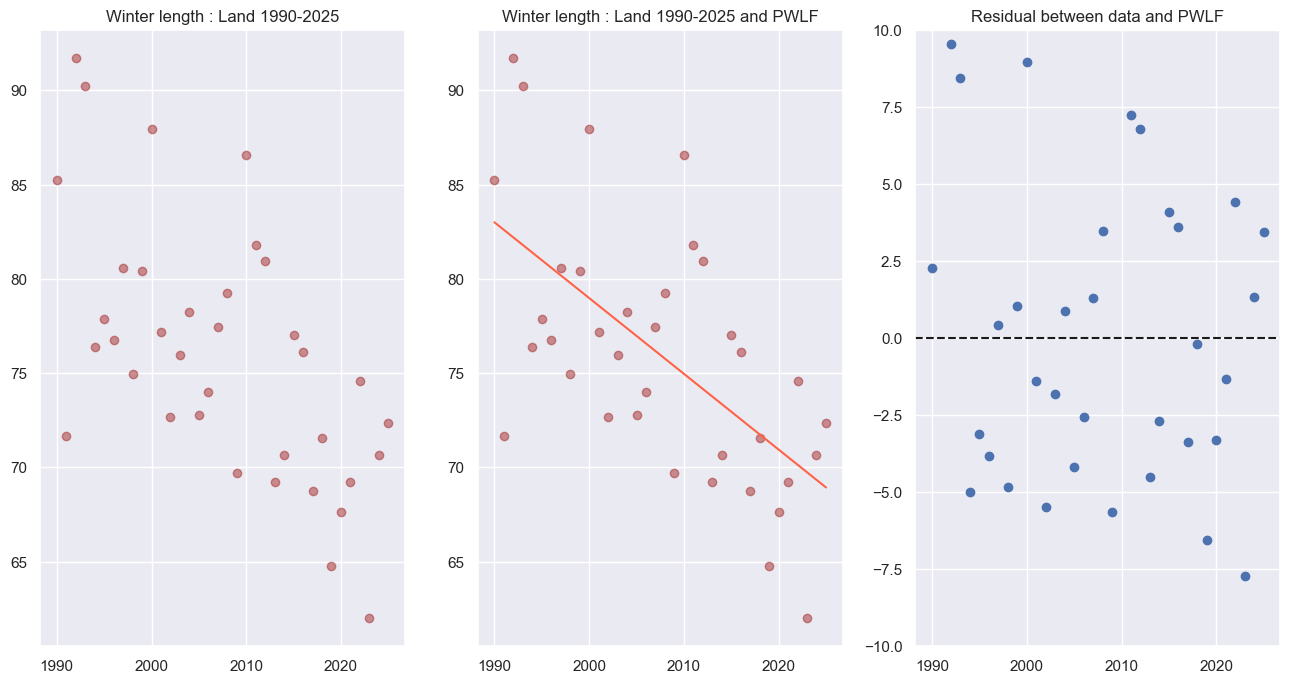

In [149]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = sh_land_an.time.dt.year.values
y = sh_land_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(1)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter length : Land 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : Land 1990-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [150]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.40177152]), array([1990, 2025]), np.float64(0.3860258839623242))

#### Two segments for Analysis period Land w/CP at 2010 yields a slightly better fit 

### Full Ocean 

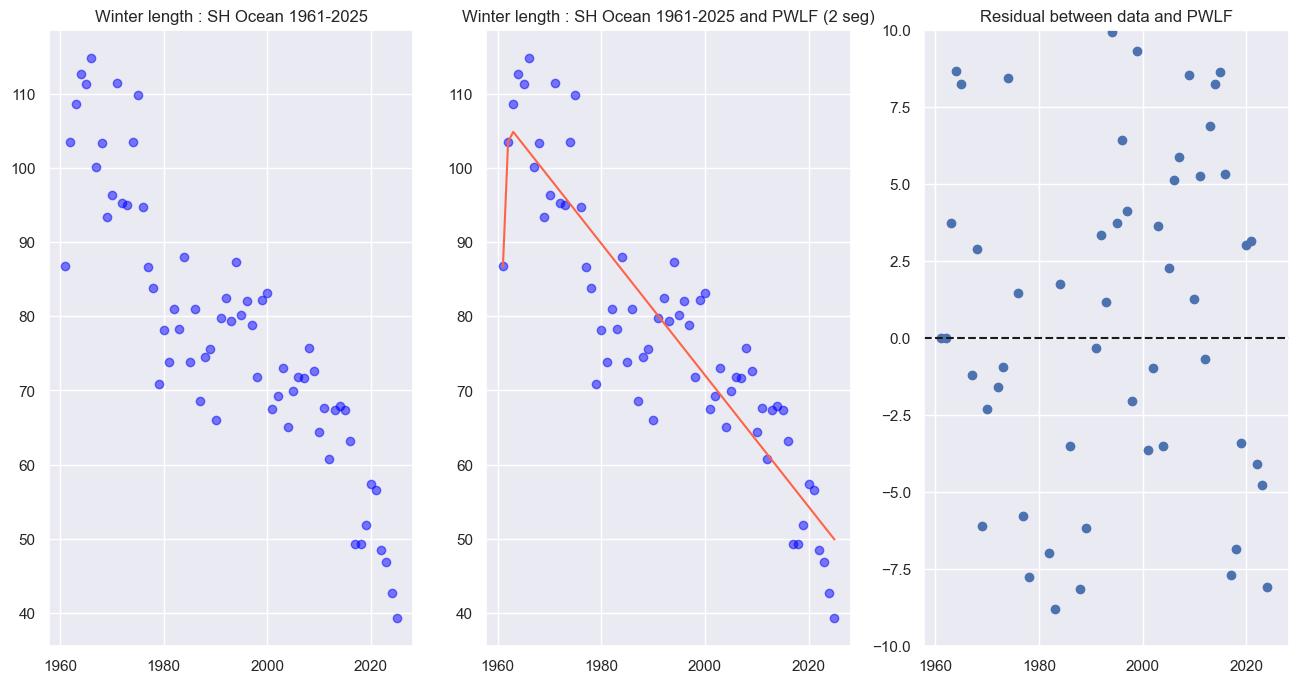

In [153]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using sh Ocean from 1990-2025 as example
x = sh_ocean_full.time.dt.year.values
y = sh_ocean_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : SH Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Ocean 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [154]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([16.83384818, -0.88714002]),
 array([1961.        , 1962.12446572, 2025.        ]),
 np.float64(0.816637238741226))

#### MSR and $R^{2}$

In [155]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(59.23780772083594), np.float64(0.816637238741226))

#### Three segments for Ocean

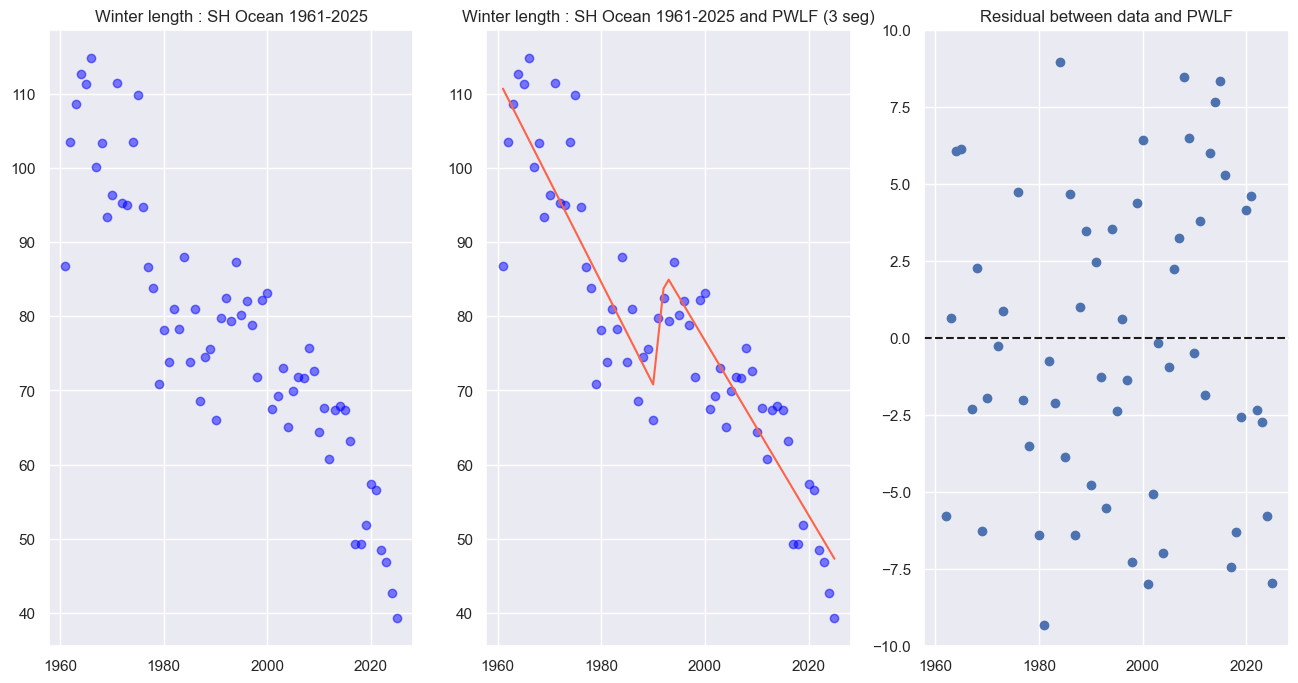

In [156]:

# define x & y using sh Ocean from 1990-2025 as example
x = sh_ocean_full.time.dt.year.values
y = sh_ocean_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for three line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(3)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : SH Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Ocean 1961-2025 and PWLF (3 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [157]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-1.37669463,  6.47683282, -1.1767967 ]),
 array([1961.        , 1990.        , 1992.31000052, 2025.        ]),
 np.float64(0.8562004447758303))

#### MSR and $R^{2}$

In [158]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(46.45638156969856), np.float64(0.8562004447758303))

### Try fixed SP at 2010 ala Rahmstorf?

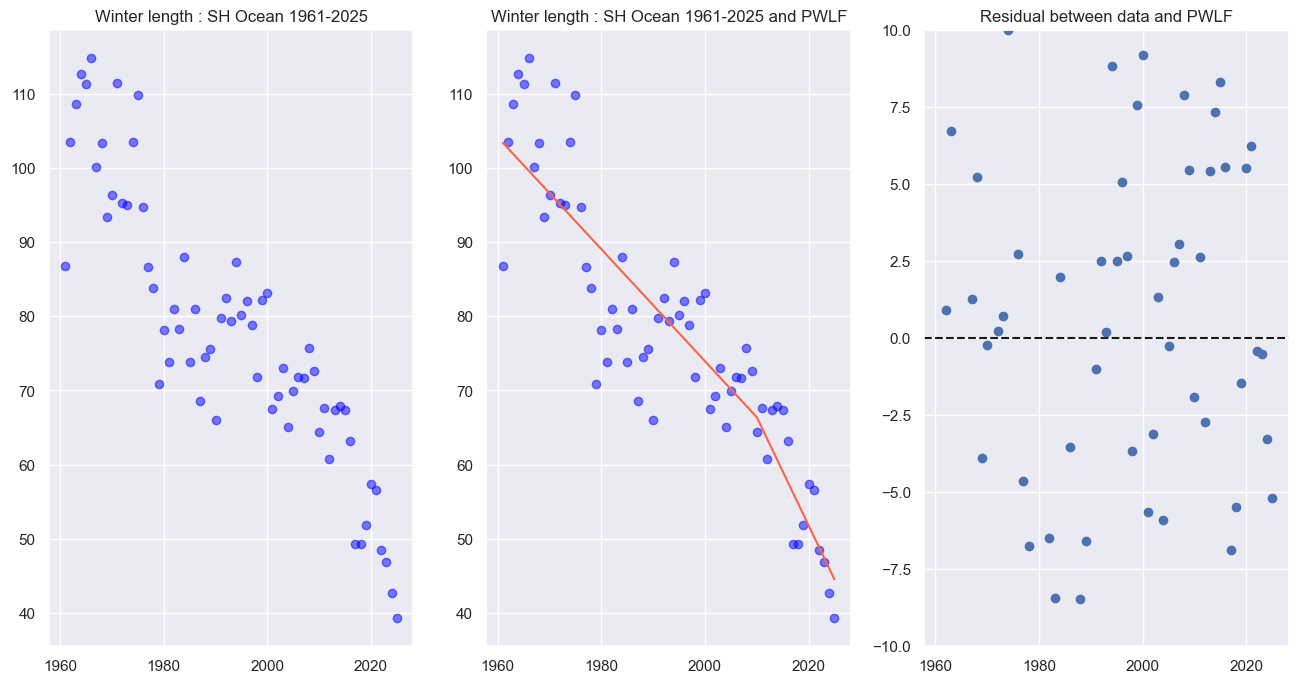

In [177]:
# define x & y using sh Ocean from 1990-2025 as example
x = sh_ocean_full.time.dt.year.values
y = sh_ocean_full.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# your desired line segment end locations
x0 = np.array([min(x), 2010, max(x)])

# fit the data for three line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit_with_breaks(x0)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : SH Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Ocean 1961-2025 and PWLF")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [160]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.75547783, -1.45864949]),
 array([1961, 2010, 2025]),
 np.float64(0.8118022627487713))

#### MSR and $R^{2}$

In [161]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(60.799811784309306), np.float64(0.8118022627487713))

### Analysis Ocean 

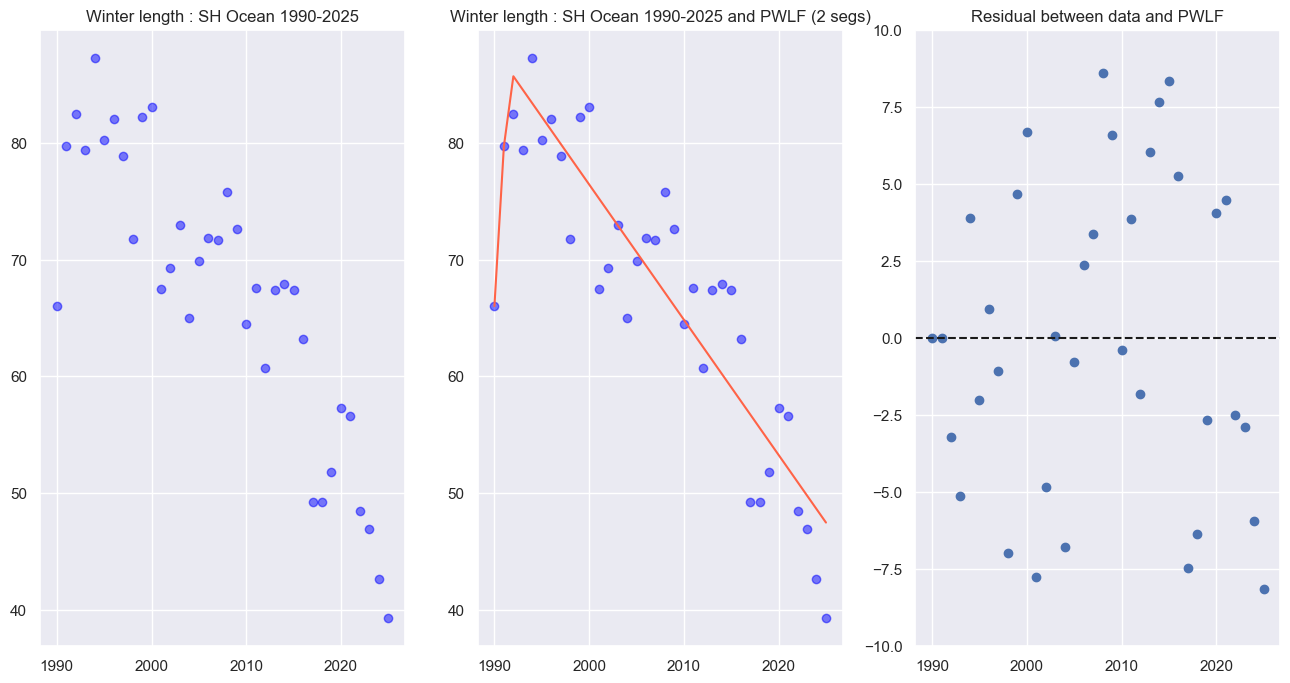

In [162]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = sh_ocean_an.time.dt.year.values
y = sh_ocean_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : SH Ocean 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Ocean 1990-2025 and PWLF (2 segs)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [163]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([13.71037661, -1.15862448]),
 array([1990.      , 1991.480861, 2025.      ]),
 np.float64(0.834491224571392))

#### **** Compare with one line instead

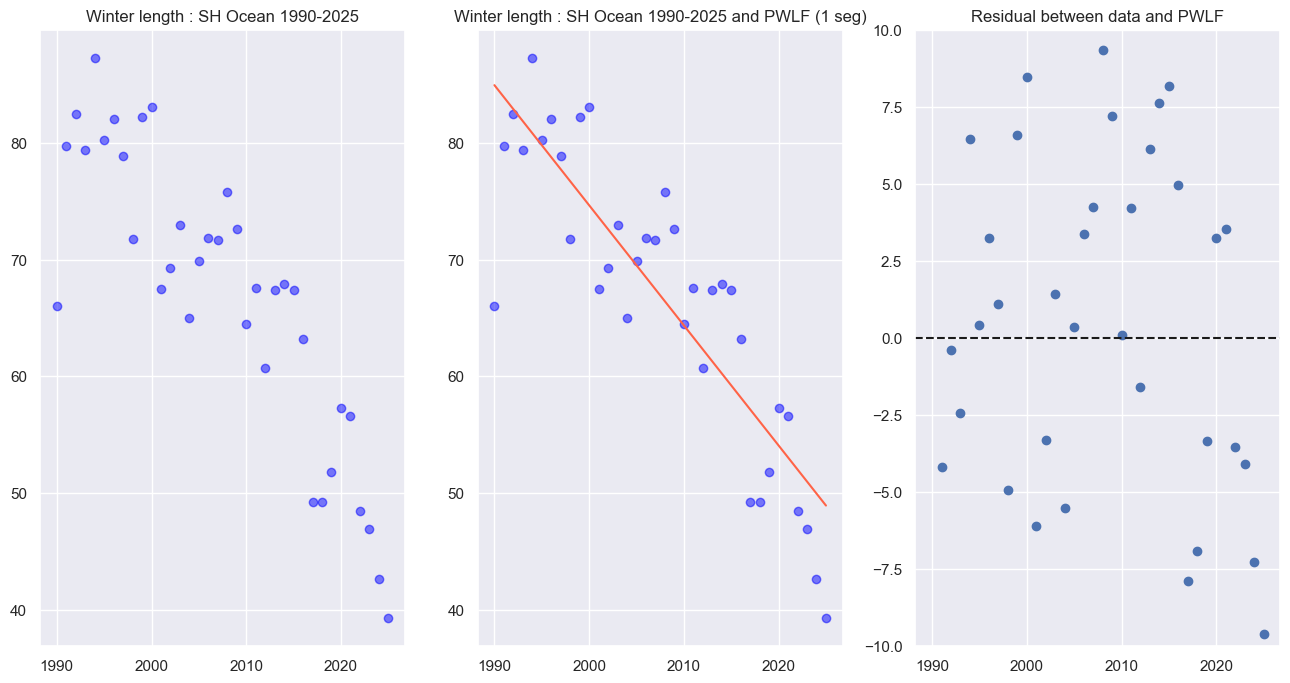

In [164]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y 
x = sh_ocean_an.time.dt.year.values
y = sh_ocean_an.WinterLength.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments
res = my_pwlf.fit(1)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter length : SH Ocean 1990-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter length : SH Ocean 1990-2025 and PWLF (1 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-10,10)
plt.title("Residual between data and PWLF")


plt.show()

In [165]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-1.02907367]), array([1990, 2025]), np.float64(0.7526911081450584))

## ** SOUTHERN ** Winter Cold

### Full Land (no accel)

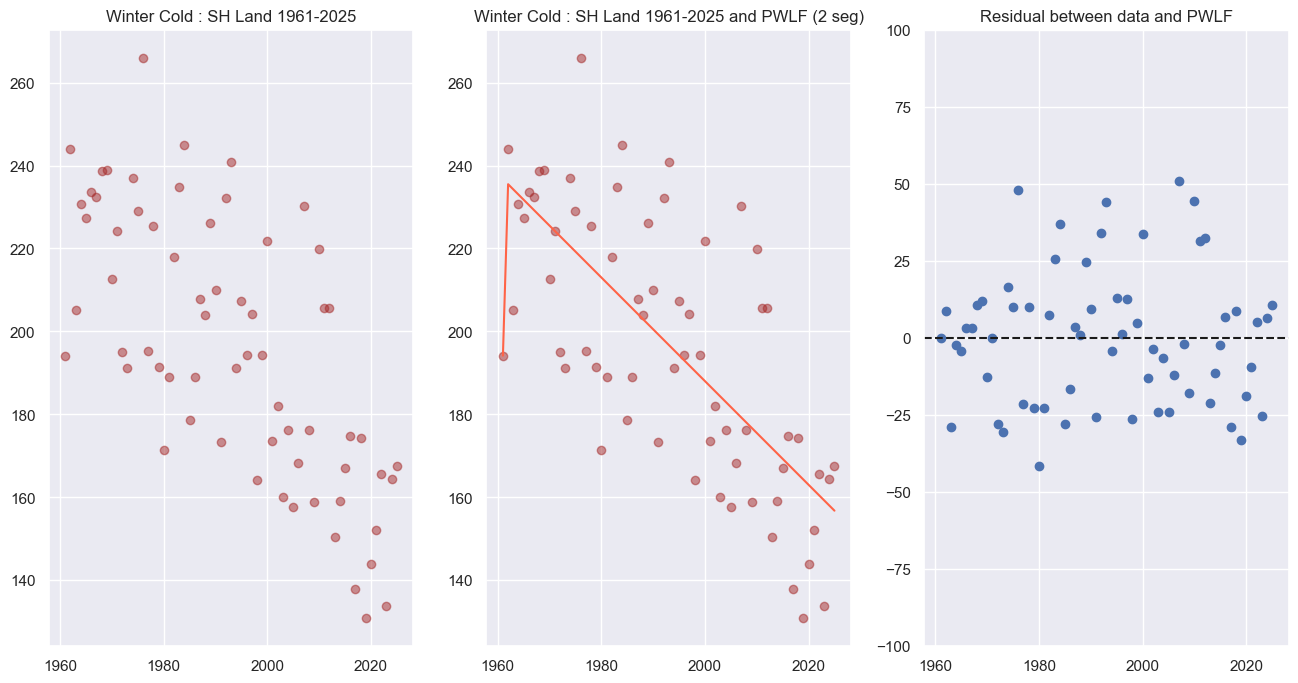

In [166]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y using sh Ocean from 1990-2025 as example
x = sh_land_full.time.dt.year.values
y = sh_land_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter Cold : SH Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : SH Land 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'o', 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()

In [167]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([ 4.58989836e+04, -1.24913288e+00]),
 array([1961.        , 1961.00092753, 2025.        ]),
 np.float64(0.5211280636881506))

#### CP at 2010 results

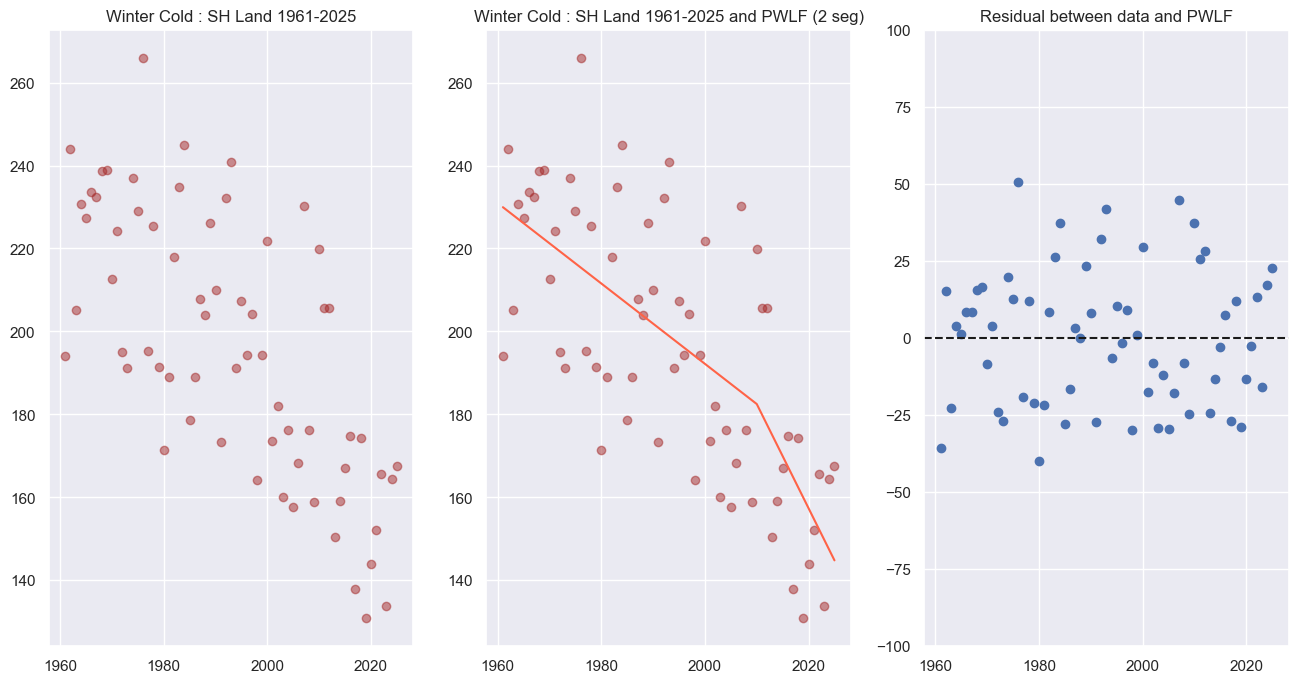

In [168]:
# define x & y using sh Ocean from 1990-2025 as example
x = sh_land_full.time.dt.year.values
y = sh_land_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# your desired line segment end locations
x0 = np.array([min(x), 2010, max(x)])

# fit the data for three line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit_with_breaks(x0)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments


# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter Cold : SH Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : SH Land 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'o', 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()



In [169]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-0.96829099, -2.51197872]),
 array([1961, 2010, 2025]),
 np.float64(0.5150566459751886))

#### MSR and $R^{2}$

In [170]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(487.923974277254), np.float64(0.5150566459751886))

#### Only one segment for residual comparison

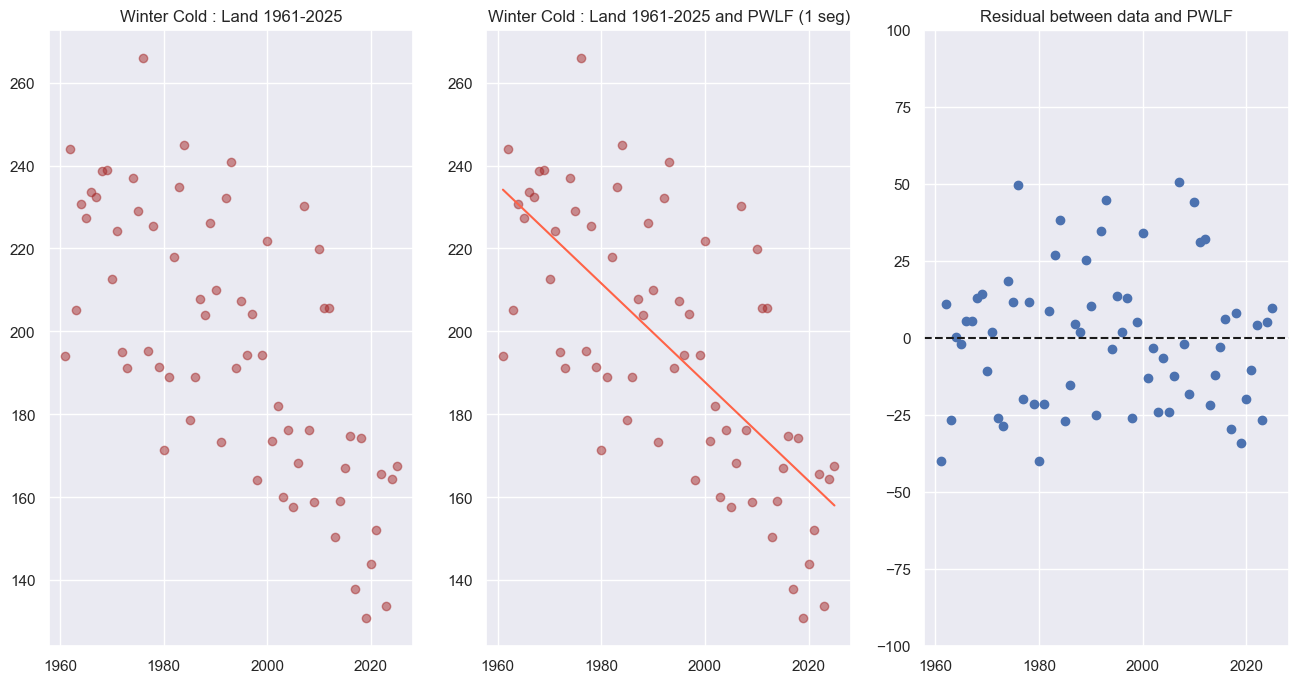

In [171]:
# help from https://jekel.me/piecewise_linear_fit_py/examples.html#find-the-best-number-of-line-segments

# define x & y using sh Ocean from 1990-2025 as example
x = sh_land_full.time.dt.year.values
y = sh_land_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(1)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='brown', alpha=0.5)
plt.title("Winter Cold : Land 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='brown', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : Land 1961-2025 and PWLF (1 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'o', 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()

In [172]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-1.18958888]), array([1961, 2025]), np.float64(0.4950799146292425))

#### MSR and $R^{2}$

In [173]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(508.02348913911635), np.float64(0.4950799146292425))

### Not clear that two segments are needed for Winter Cold in SH

### Full Ocean 

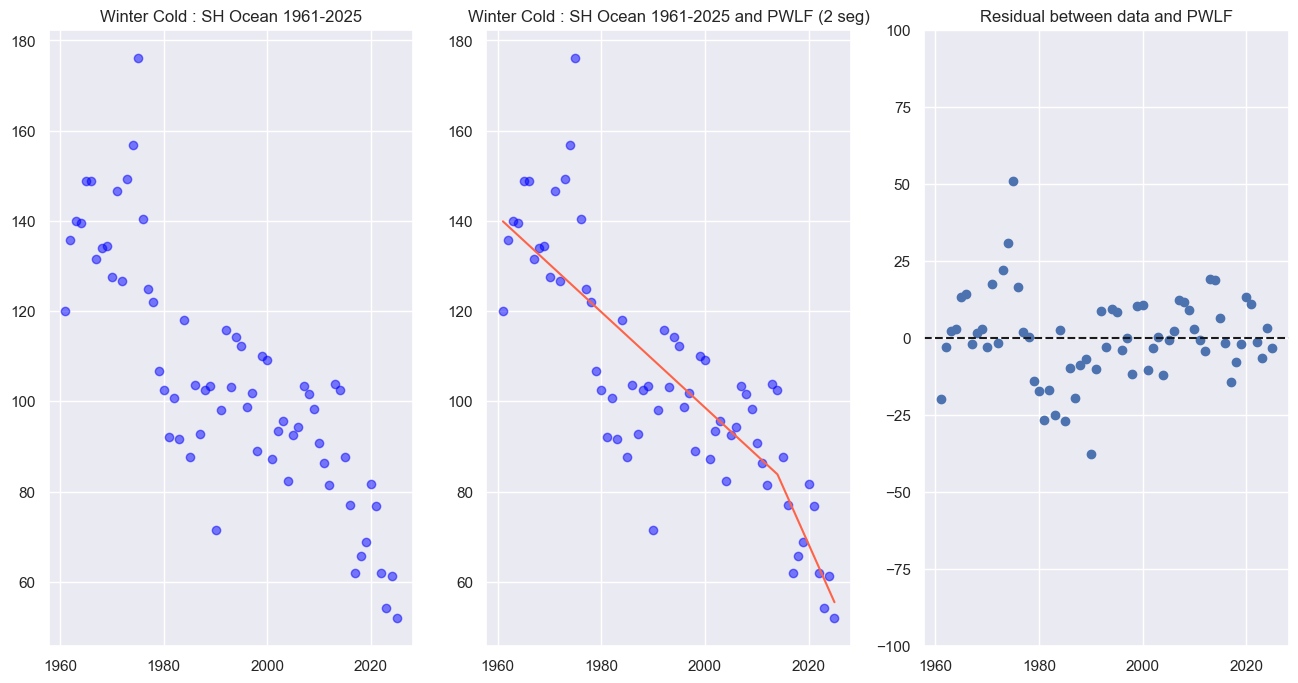

In [174]:
# help from https://james-brennan.github.io/posts/lowess_conf/


# define x & y using sh Ocean from 1990-2025 as example
x = sh_ocean_full.time.dt.year.values
y = sh_ocean_full.WinterCold.values

# number of segments - can also determine this algorithmically via link above
my_pwlf = pwlf.PiecewiseLinFit(x, y)

# fit the data for two line segments - it looks like either 2 or 3 to me
res = my_pwlf.fit(2)

# predict for the determined points
xHat = np.linspace(min(x), max(x), num=len(y))
yHat = my_pwlf.predict(xHat)

# plot the results
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.plot(x, y, 'o',c='blue', alpha=0.5)
plt.title("Winter Cold : SH Ocean 1961-2025")

plt.subplot(1,3,2)
plt.plot(x, y, 'o', c='blue', alpha=0.5)
plt.plot(xHat, yHat, '-', c='tomato')
plt.title("Winter Cold : SH Ocean 1961-2025 and PWLF (2 seg)")

plt.subplot(1,3,3)
#plt.plot(x, y - yHat, 'b')
plt.scatter(x, y - yHat)
plt.axhline(color='k', linestyle="--")
plt.ylim(-100,100)
plt.title("Residual between data and PWLF")


plt.show()

In [175]:
my_pwlf.calc_slopes(), my_pwlf.fit_breaks, my_pwlf.r_squared()

(array([-1.05801001, -2.57577963]),
 array([1961.        , 2014.00000002, 2025.        ]),
 np.float64(0.7142159788777009))

#### MSR and $R^{2}$

In [176]:
# MSR calculation for comparison
MSR = np.sum((y-yHat)**2)/len(x)
MSR, my_pwlf.r_squared()

(np.float64(201.2945781668399), np.float64(0.7142159788777009))

## **** General Conclusions for SH:
- Weak Evidence of acceleration in Winter Length with CP around 2010 for Land and Ocean
- Unclear evidence for Winter Cold